**Notebook to verify flexibility needs and contribution methods**

In [1]:
import os
import sys 
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pypsa
from IPython.display import Image

# Add the scripts/pypsa-de directory to the path
scripts_path = os.path.join(os.path.dirname(os.getcwd()), 'scripts', 'pypsa-de')
sys.path.append(scripts_path)

from flexibility_utils import tech_colors

In [2]:
# load networks

networks = {}
run = "20250214-reworkimportban"  # "20241203-force-onwind-south"
scenario = "KN2045_Bal_v4"  # "KN2045_Elec_v4" # "KN2045_H2_v4" # "CurrentPolicies" # "KN2045_Bal_v4"

for year in np.arange(2020, 2050, 5):
    fn = f"/home/julian-geis/Documents/04_Ariadne/run_results/{run}/{scenario}/postnetworks/base_s_49_lvopt__none_{year}.nc"
    networks[year] = pypsa.Network(fn)

INFO:pypsa.network.io:New version 1.0.2 available! (Current: 0.35.1)
INFO:pypsa.network.io:Imported network '' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.network.io:New version 1.0.2 available! (Current: 0.35.1)
Index(['FR4 0 waste CHP-2025', 'IT3 0 waste CHP-2025',
       'FR4 0 waste CHP CC-2025', 'IT3 0 waste CHP CC-2025',
       'FR4 0 urban central gas CHP-1995', 'IT3 0 urban central oil CHP-1995',
       'IT3 0 urban central gas CHP-2000', 'IT3 0 urban central gas CHP-2005',
       'IT3 0 urban central gas CHP-2010'],
      dtype='object', name='name')
INFO:pypsa.network.io:Imported network '' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.network.io:New version 1.0.2 available! (Current: 0.35.1)
Index(['FR4 0 waste CHP-2030', 'IT3 0 waste CHP-2030',
       'FR4 0 waste CHP CC-2030', 'IT3 0 waste CHP CC-2030',
       'FR4 0 urban central gas CHP-1995', 'IT3 

# System cost

In [3]:
from pypsa.statistics import get_transmission_carriers

def get_system_costs(n, country=None):
    """
    Calculate capex and opex for entire system or specific country.
    
    Parameters
    ----------
    n : pypsa.Network
    country : str, optional
        Country code (e.g., "DE", "EU"). If None, returns total system costs.
    
    Returns
    -------
    pd.DataFrame
        DataFrame with columns ["capex", "opex"] in billion EUR, indexed by carrier
    """
    # Assign country from location or bus name if empty
    empty_country = n.buses.country == ""
    n.buses.loc[empty_country, "country"] = n.buses.loc[empty_country, "location"]
    still_empty = n.buses.country == ""
    n.buses.loc[still_empty, "country"] = n.buses.loc[still_empty].index.str[:2]
    
    if country is None:
        return pd.DataFrame({
            "capex": n.statistics.capex(groupby="carrier", nice_names=False),
            "opex": n.statistics.opex(groupby="carrier", nice_names=False)
        }) / 1e9
    
    # Country-specific costs
    pypsa.options.set_option("params.statistics.drop_zero", False)
    kwargs = {"groupby": ["name", "carrier"], "nice_names": False}
    
    costs = pd.DataFrame({
        "capex": n.statistics.capex(**kwargs),
        "opex": n.statistics.opex(**kwargs)
    }).reset_index()
    
    # Map component names to countries
    def get_component_country(name):
        component_attrs = {
            "generators": "bus",
            "loads": "bus",
            "stores": "bus",
            "storage_units": "bus",
            "links": "bus0",
            "lines": "bus0"
        }
        for attr, bus_col in component_attrs.items():
            df = getattr(n, attr)
            if name in df.index:
                return n.buses.loc[df.loc[name, bus_col], "country"]
        return None
    
    costs["country"] = costs["name"].apply(get_component_country)
    
    # Get transmission carriers
    transmission_carriers = get_transmission_carriers(n).get_level_values("carrier").unique()
    
    # Find inter-country transmission touching this country
    def inter_country_mask(df):
        bus0_country = df.bus0.map(n.buses.country)
        bus1_country = df.bus1.map(n.buses.country)
        return (
            df.carrier.isin(transmission_carriers) & 
            df.active &
            (bus0_country != bus1_country) &
            ((bus0_country == country) | (bus1_country == country))
        )
    
    inter_assets = (
        inter_country_mask(n.lines)[lambda x: x].index.union(
        inter_country_mask(n.links)[lambda x: x].index)
    )
    
    # Split shared transmission costs
    mask = costs["name"].isin(inter_assets)
    costs.loc[mask, ["capex", "opex"]] /= 2
    
    # Filter to country and convert to billion EUR
    return (
        costs[costs["country"] == country]
        .groupby("carrier")[["capex", "opex"]]
        .sum()
        / 1e9
    )

In [4]:
from pypsa.statistics import get_transmission_carriers

def get_system_costs(n, country=None):
    """
    Calculate capex and opex for entire system or specific country.
    
    Parameters
    ----------
    n : pypsa.Network
    country : str, optional
        Country code (e.g., "DE"). If None, returns total system costs.
        Note: "EU" buses are commodity buses and costs are assigned to real countries.
    
    Returns
    -------
    pd.DataFrame
        DataFrame with columns ["capex", "opex"] in billion EUR, indexed by carrier
    """
    # Assign country from location or bus name if empty
    empty_country = n.buses.country == ""
    n.buses.loc[empty_country, "country"] = n.buses.loc[empty_country, "location"]
    still_empty = n.buses.country == ""
    n.buses.loc[still_empty, "country"] = n.buses.loc[still_empty].index.str[:2]
    
    if country is None:
        return pd.DataFrame({
            "capex": n.statistics.capex(groupby="carrier", nice_names=False),
            "opex": n.statistics.opex(groupby="carrier", nice_names=False)
        }) / 1e9
    
    # Country-specific costs
    pypsa.options.set_option("params.statistics.drop_zero", False)
    kwargs = {"groupby": ["name", "carrier"], "nice_names": False}
    
    costs = pd.DataFrame({
        "capex": n.statistics.capex(**kwargs),
        "opex": n.statistics.opex(**kwargs)
    }).reset_index()
    
    # Map components to country based on buses
    def get_component_country(name):
        # Single-bus components
        for attr in ["generators", "loads", "stores", "storage_units"]:
            df = getattr(n, attr)
            if name in df.index:
                return n.buses.loc[df.loc[name, "bus"], "country"]
        
        # Two-bus components: assign based on real country (not EU)
        for attr in ["links", "lines"]:
            df = getattr(n, attr)
            if name in df.index:
                bus0_country = n.buses.loc[df.loc[name, "bus0"], "country"]
                bus1_country = n.buses.loc[df.loc[name, "bus1"], "country"]
                
                # If one side is EU, assign to the other side
                if bus0_country == "EU":
                    return bus1_country
                elif bus1_country == "EU":
                    return bus0_country
                else:
                    # Both are real countries - return tuple for inter-country check
                    return (bus0_country, bus1_country)
        return None
    
    costs["country_info"] = costs["name"].apply(get_component_country)
    
    # Get transmission carriers
    transmission_carriers = get_transmission_carriers(n).get_level_values("carrier").unique()
    
    # Find inter-country transmission touching this country (excluding EU buses)
    def inter_country_mask(df):
        bus0_country = df.bus0.map(n.buses.country)
        bus1_country = df.bus1.map(n.buses.country)
        return (
            df.carrier.isin(transmission_carriers) & 
            df.active &
            (bus0_country != bus1_country) &
            (bus0_country != "EU") & (bus1_country != "EU") &  # Exclude EU buses
            ((bus0_country == country) | (bus1_country == country))
        )
    
    inter_assets = (
        inter_country_mask(n.lines)[lambda x: x].index.union(
        inter_country_mask(n.links)[lambda x: x].index)
    )
    
    # Split shared transmission costs
    mask = costs["name"].isin(inter_assets)
    costs.loc[mask, ["capex", "opex"]] /= 2
    
    # Filter to country
    def belongs_to_country(country_info):
        if country_info is None:
            return False
        if isinstance(country_info, tuple):
            # Inter-country transmission: belongs if either bus is in country
            return country in country_info
        else:
            # Direct assignment or single-bus component
            return country_info == country
    
    country_mask = costs["country_info"].apply(belongs_to_country)
    
    return (
        costs[country_mask]
        .groupby("carrier")[["capex", "opex"]]
        .sum()
        / 1e9
    )

In [5]:
# All individual countries + EU
n = networks[2045].copy()

sum = 0
countries = n.buses.country[n.buses.country != ""].unique().tolist() + ["EU"]
res_cl = {}

for c in countries:
    res_cl[c] = get_system_costs(n, country=c)
    print(f"{c}: {res_cl[c].sum().sum():.2f} bn EUR")
    sum += res_cl[c].sum().sum()
print(f"Sum of countries: {sum:.2f} bn EUR")
print()

# Total
total = get_system_costs(n)
print(f"Total: {total.sum().sum():.2f} bn EUR")

AT: 14.49 bn EUR
BE: 16.76 bn EUR
CH: 15.93 bn EUR
CZ: 12.82 bn EUR
DE: 152.55 bn EUR
DK: 14.92 bn EUR
ES: 80.14 bn EUR
FR: 128.49 bn EUR
GB: 94.27 bn EUR
IT: 95.76 bn EUR
LU: 1.74 bn EUR
NL: 40.56 bn EUR
NO: 15.03 bn EUR
PL: 68.85 bn EUR
SE: 22.24 bn EUR
EU: 45.91 bn EUR
Sum of countries: 820.47 bn EUR

Total: 820.47 bn EUR


In [6]:
# system cost DE (according to exporter)
region = "DE"

def get_tsc(n, country):
        pypsa.options.set_option("params.statistics.drop_zero", False)
        capex = n.statistics.capex(
            groupby=pypsa.statistics.groupers["name", "carrier"], nice_names=False
        )

        opex = n.statistics.opex(
            groupby=pypsa.statistics.groupers["name", "carrier"], nice_names=False
        )

        # filter inter country transmission lines and links
        inter_country_lines = n.lines.bus0.map(n.buses.country) != n.lines.bus1.map(
            n.buses.country
        )
        inter_country_links = n.links.bus0.map(n.buses.country) != n.links.bus1.map(
            n.buses.country
        )
        #
        transmission_carriers = get_transmission_carriers(n).get_level_values("carrier")
        transmission_lines = (
            n.lines.carrier.isin(transmission_carriers) & n.lines.active
        )
        transmission_links = (
            n.links.carrier.isin(transmission_carriers) & n.links.active
        )
        #
        country_transmission_lines = (
            (n.lines.bus0.str.contains(country)) & ~(n.lines.bus1.str.contains(country))
        ) | (
            ~(n.lines.bus0.str.contains(country)) & (n.lines.bus1.str.contains(country))
        )
        country_tranmission_links = (
            (n.links.bus0.str.contains(country)) & ~(n.links.bus1.str.contains(country))
        ) | (
            ~(n.links.bus0.str.contains(country)) & (n.links.bus1.str.contains(country))
        )
        #
        inter_country_transmission_lines = (
            inter_country_lines & transmission_lines & country_transmission_lines
        )
        inter_country_transmission_links = (
            inter_country_links & transmission_links & country_tranmission_links
        )
        inter_country_transmission_lines_i = inter_country_transmission_lines[
            inter_country_transmission_lines
        ].index
        inter_country_transmission_links_i = inter_country_transmission_links[
            inter_country_transmission_links
        ].index
        inter_country_transmission_i = inter_country_transmission_lines_i.union(
            inter_country_transmission_links_i
        )

        #
        tsc = pd.concat([capex, opex], axis=1, keys=["capex", "opex"])
        tsc = tsc.reset_index().set_index("name")
        tsc.loc[inter_country_transmission_i, ["capex", "opex"]] = (
            tsc.loc[inter_country_transmission_i, ["capex", "opex"]] / 2
        )
        tsc.rename(
            index={
                index: index + " " + country for index in inter_country_transmission_i
            },
            inplace=True,
        )
        # rename inter region links and lines
        to_rename_links = n.links[
            (n.links.bus0.str.contains(region))
            & (n.links.bus1.str.contains(region))
            & ~(n.links.index.str.contains(region))
        ].index
        to_rename_lines = n.lines[
            (n.lines.bus0.str.contains(region))
            & (n.lines.bus1.str.contains(region))
            & ~(n.lines.index.str.contains(region))
        ].index
        tsc.rename(
            index={index: index + " " + region for index in to_rename_links},
            inplace=True,
        )
        tsc.rename(
            index={index: index + " " + region for index in to_rename_lines},
            inplace=True,
        )

        tsc = (
            tsc.filter(like=country, axis=0)
            .drop("component", axis=1)
            .groupby("carrier")
            .sum()
        )

        return tsc

In [7]:
n = networks[2045].copy()
tsc_de = get_tsc(n, "DE")

In [8]:
# All individual countries + EU
n = networks[2045].copy()

sum = 0
countries = n.buses.country[n.buses.country != ""].unique().tolist() + ["EU"]
res = {}

for c in countries:
    res[c] = get_tsc(n, country=c)
    print(f"{c}: {res[c].sum().sum()/1e9:.2f} bn EUR")
    sum += res[c].sum().sum()
print(f"Sum of countries: {sum/1e9:.2f} bn EUR")
print()


AT: 14.49 bn EUR
BE: 16.76 bn EUR
CH: 28.53 bn EUR
CZ: 12.82 bn EUR
DE: 152.55 bn EUR
DK: 14.83 bn EUR
ES: 79.30 bn EUR
FR: 128.49 bn EUR
GB: 93.58 bn EUR
IT: 95.57 bn EUR
LU: 1.74 bn EUR
NL: 40.56 bn EUR
NO: 15.03 bn EUR
PL: 68.85 bn EUR
SE: 22.24 bn EUR
EU: 45.92 bn EUR
Sum of countries: 831.27 bn EUR



In [9]:
# AT: 13.47 bn EUR
# BE: 14.06 bn EUR
# CH: 13.31 bn EUR
# CZ: 11.80 bn EUR
# DE: 151.37 bn EUR
# DK: 14.44 bn EUR
# ES: 75.47 bn EUR
# FR: 122.23 bn EUR
# GB: 90.56 bn EUR
# IT: 92.06 bn EUR
# LU: 1.45 bn EUR
# NL: 37.11 bn EUR
# NO: 13.91 bn EUR
# PL: 65.98 bn EUR
# SE: 14.56 bn EUR
# EU: 77.11 bn EUR
# Sum of countries: 808.89 bn EUR

# Total: 820.47 bn EUR

In [10]:
res["CH"].sum()/1e9

capex    25.655763
opex      2.877673
dtype: float64

In [11]:
res_cl["CH"].sum()

capex    15.607527
opex      0.324646
dtype: float64

In [12]:
df = res_cl["CH"]["capex"]
df.sort_values(ascending=False)[:30] * 1e3

carrier
nuclear                             2238.739119
electricity distribution grid       2072.993272
solar-hsat                          1981.058527
hydro                               1910.456917
ror                                 1297.668702
PHS                                  933.142922
solar                                908.870745
urban decentral air heat pump        885.145448
AC                                   787.098929
solar rooftop                        712.032439
rural ground heat pump               559.818029
Fischer-Tropsch                      163.854701
biomass to liquid CC                 158.796605
DC                                   109.445754
urban central air heat pump          108.836024
H2 pipeline                           84.692368
urban central solid biomass CHP       82.756777
H2 Electrolysis                       73.694832
battery                               65.362844
urban decentral resistive heater      61.240995
waste CHP                       

In [13]:
df = res["CH"]["capex"]
(df[df > 1e6]/1e6).sort_values(ascending=False)

carrier
urban central gas CHP               4353.332469
waste CHP CC                        2253.165483
nuclear                             2238.739119
electricity distribution grid       2072.993272
solar-hsat                          1981.058527
hydro                               1910.456917
waste CHP                           1390.093899
urban central H2 CHP                1298.185175
ror                                 1297.668702
PHS                                  933.142922
solar                                908.870745
urban decentral air heat pump        885.145448
AC                                   787.098929
solar rooftop                        712.032439
urban central H2 retrofit CHP        628.086374
rural ground heat pump               559.818029
urban central solid biomass CHP      267.745182
Fischer-Tropsch                      163.854701
biomass to liquid CC                 158.796605
DC                                   109.445754
urban central air heat pump     

In [14]:
n.links[(n.links.carrier == "urban central gas CHP") & (n.links.bus1.str.contains("CH"))][["p_nom_opt"]]

,p_nom_opt
Link,
CH0 0 urban central gas CHP-2045,678.031436
CH0 0 urban central gas CHP-2010,137.500000


In [15]:
n.statistics.capex(groupby=["name", "carrier"], nice_names=False)["Link"][["CH0 0 urban central gas CHP-2045", "CH0 0 urban central gas CHP-2010"]].sum() / 1e6

21.36820786951

In [16]:
n.statistics.capex(groupby=["bus","carrier"], nice_names=False)

component  bus                                carrier                    
Generator  AT0 0                              onwind                         3.696239e+08
                                              ror                            1.376314e+09
                                              solar                          1.916180e+09
                                              solar-hsat                     3.448468e+08
           AT0 0 low voltage                  solar rooftop                  8.465670e+08
                                                                                 ...     
Store      SE1 0 rural water tanks            rural water tanks              2.284793e+06
           SE1 0 solid biomass                solid biomass                  0.000000e+00
           SE1 0 urban central water tanks    urban central water tanks      3.967325e+07
           SE1 0 urban decentral water tanks  urban decentral water tanks    1.158622e+07
           co2 atmosphere 

In [17]:
def add_industry_dsm(n, dsm_config):
    """
    Add demand-side management (DSM) for industrial loads in Germany.

    Creates distributed DSM capacity across industrial load buses, weighted by
    their load. DSM is implemented as a debt-tracking system where load can be
    reduced (creating debt) and must be compensated later.

    Parameters
    ----------
    n : pypsa.Network
        The energy system network.
    dsm_config : dict
        Configuration dictionary with keys under 'industry_dsm_de':
        - shift_capacity: float, total DSM capacity in GW
        - holding_hours: float, maximum hours debt can be held
        - ramp_down_cost: float, marginal cost of reducing load (€/MWh)
    """

    # logger.info("Adding demand-side management (DSM) for industrial loads in Germany.")

    # Filter industrial loads in Germany
    industrial_loads = n.loads[
        (n.loads.carrier == "industry electricity")
        & (n.loads.bus.str.contains("DE", na=False))
    ]

    # if industrial_loads.empty:
    #     logger.warning("No industrial loads found in Germany. Skipping DSM addition.")
    #     return

    # Calculate weights based on average load at each bus
    load_by_bus = {}

    for load_name in industrial_loads.index:
        bus = n.loads.at[load_name, "bus"]

        # Get average load for weighting
        if load_name in n.loads_t.p_set.columns:
            avg_load = n.loads_t.p_set[load_name].mean()
        elif hasattr(n.loads.at[load_name, "p_set"], "__iter__"):
            avg_load = n.loads.at[load_name, "p_set"].mean()
        else:
            avg_load = n.loads.at[load_name, "p_set"]

        if bus in load_by_bus:
            load_by_bus[bus] += avg_load
        else:
            load_by_bus[bus] = avg_load

    total_load = sum(load_by_bus.values())

    # if total_load == 0:
    #     logger.warning("Total industrial load in Germany is zero. Skipping DSM addition.")
    #     return

    # Extract config parameters
    total_shift_capacity = dsm_config["shift_capacity"] * 1e3  # Convert GW to MW
    holding_hours = dsm_config["holding_hours"]
    ramp_down_cost = dsm_config.get("ramp_down_cost", 0)
    compensate_cost = dsm_config.get("compensate_cost", 0)

    # logger.info(f"Total DSM capacity: {dsm_config['shift_capacity']} GW, "
    #             f"Holding time: {holding_hours} hours, "
    #             f"distributed across {len(load_by_bus)} buses")

    # Define carriers
    n.add("Carrier", "industry DSM")
    n.add("Carrier", "industry DSM ramp down")
    n.add("Carrier", "industry DSM compensate")

    # Add DSM components for each bus
    for bus, load in load_by_bus.items():
        # Calculate this bus's share of DSM capacity based on load weight
        weight = load / total_load
        bus_shift_capacity = total_shift_capacity * weight  # MW
        bus_debt_capacity = bus_shift_capacity * holding_hours  # MWh

        # logger.debug(f"Bus {bus}: {bus_shift_capacity:.1f} MW DSM ({weight*100:.1f}%)")

        # Create bus for debt tracking
        dsm_bus_name = f"{bus} DSM debt bus"
        n.add("Bus", dsm_bus_name, carrier="DSM")

        # Store to track production debt
        n.add(
            "Store",
            f"{bus}_DSM_debt",
            bus=dsm_bus_name,
            e_nom=bus_debt_capacity,
            e_initial=0,
            standing_loss=0,
            capital_cost=0,
            carrier="industry DSM",
        )

        # Link: Ramp DOWN = reduce load, charges the debt store
        n.add(
            "Link",
            f"{bus} DSM ramp down",
            bus0=bus,  # Takes from grid
            bus1=dsm_bus_name,  # Charges debt
            p_nom=bus_shift_capacity,
            efficiency=1.0,
            marginal_cost=ramp_down_cost,
            capital_cost=0,
            carrier="industry DSM ramp down",
        )

        # Link: Compensate = increase load later to catch up, discharges debt
        n.add(
            "Link",
            f"{bus} DSM compensate",
            bus0=dsm_bus_name,  # Discharges debt
            bus1=bus,  # Adds load to grid
            p_nom=bus_shift_capacity,
            efficiency=1.0,
            marginal_cost=compensate_cost,
            capital_cost=0,
            carrier="industry DSM compensate",
        )

    print(
        f"Added DSM components to {len(load_by_bus)} buses. "
        f"Total capacity: {total_shift_capacity / 1e3:.2f} GW, "
        f"Total storage: {total_shift_capacity * holding_hours / 1e3:.2f} GWh"
    )

In [18]:
n.stores.index[n.stores.carrier == "industry_DSM"]

Index([], dtype='object', name='Store')

In [19]:
# industry dsm
config = {
    "shift_capacity": 10,  # GW
    "holding_hours": 4,
    "compensate_hours": 24,
    "ramp_down_cost": 0,
    "compensate_cost": 0,
}

In [20]:
add_industry_dsm(n, config)

TypeError: 'numpy.float64' object is not callable

In [ ]:
# Find all DSM debt stores
dsm_stores = n.stores.index[n.stores.carrier == "industry DSM"]


compensate_hours = 24
# Convert snapshots to hours from start
start_time = n.snapshots[0]
snapshot_hours = [(snap - start_time).total_seconds() / 3600 for snap in n.snapshots]

# Find snapshots that are at multiples of compensate_hours
# Allow some tolerance for floating point comparison
tolerance = 0.1  # hours
cycle_snapshots = []

for i, hours in enumerate(snapshot_hours):
    # Check if this snapshot is at a multiple of compensate_hours
    remainder = hours % compensate_hours
    # Check both remainder near 0 or near compensate_hours (wrapping)
    if remainder < tolerance or (compensate_hours - remainder) < tolerance:
        cycle_snapshots.append(n.snapshots[i])

# Always include the last snapshot to ensure debt is cleared at end
if n.snapshots[-1] not in cycle_snapshots:
    cycle_snapshots.append(n.snapshots[-1])

if not cycle_snapshots:
    print(
        f"No snapshots found at {compensate_hours}h intervals. "
        f"Temporal resolution may be too coarse. Adding constraint only at last snapshot."
    )
    cycle_snapshots = [n.snapshots[-1]]

# Calculate average snapshot duration for info
if len(n.snapshots) > 1:
    avg_duration = sum(
        (n.snapshots[i + 1] - n.snapshots[i]).total_seconds() / 3600
        for i in range(len(n.snapshots) - 1)
    ) / (len(n.snapshots) - 1)
    print(f"Average snapshot duration: {avg_duration:.2f} hours")

print(
    f"DSM debt must be zero at {len(cycle_snapshots)} snapshots "
    f"(approximately every {compensate_hours} hours)"
)

# Add constraints for each store at each cycle point
constraint_count = 0
for store in dsm_stores:
    for snapshot in cycle_snapshots:
        cname = f"DSM_cycling-{store}-{snapshot}"

        # Store state of charge must be zero at this snapshot
        lhs = n.model["Store-e"].loc[snapshot, store]

        n.model.add_constraints(lhs == 0, name=cname)
        constraint_count += 1

# not adding to network as the shadow prices are not needed

print(
    f"Added {constraint_count} DSM cycling constraints across {len(dsm_stores)} stores"
)

In [ ]:
n.stores.index[n.stores.carrier == "DSM"]

In [ ]:
n.stores.carrier.unique()

In [ ]:
n.carriers

In [ ]:
kwargs = {
    "groupby": ["bus", "carrier"],
    "at_port": True,
    "nice_names": False,
}

results = []  # store results for all years

for year in np.arange(2020, 2050, 5):
    capacities_electricity = (
        networks[year]
        .statistics.optimal_capacity(
            bus_carrier=["AC", "low voltage"],
            **kwargs,
        )
        .filter(like="DE")
        .groupby("carrier")
        .sum()
        .drop(
            ["AC", "DC", "electricity distribution grid"],  # drop transmission
            errors="ignore",
        )
        .multiply(1e-3)  # convert to GW
    )

    # get the capacity value for "home battery charger" in this year
    value = capacities_electricity.loc["home battery charger"].sum()
    results.append(f"{year} ({value:.2f} GW)")

# join all results in one line
output = "; ".join(results)
print(output)

In [ ]:
capacities_electricity["home battery charger"]

In [ ]:
PLOT_DIR = f"/home/julian-geis/repos/pypsa-de-flex/results/plots/{run}/{scenario}/"
os.makedirs(PLOT_DIR, exist_ok=True)

# Functions

In [21]:
def calc_supply_demand(
    n,
    bus_carrier=["low voltage", "AC"],
    region="DE",
    energy=True,
    interconnectors=True,
    merge_dist_grid=True,
    drop_dist_grid=True,
    buses=None,
    add_diff_as_import=False,
):
    """
    Aggregates supply and demand statistics from a PyPSA network for a given region or list of buses.

    Parameters
    ----------
    n : pypsa.Network
        The PyPSA network object containing snapshots, buses, and generators.
    bus_carrier : list[str], default ["low voltage", "AC"]
        Carrier for which supply and demand is calculated.
    region : str, default "DE"
        Two-letter country code prefix for buses to include.
    interconnectors : bool, default True
        Whether to include interconnectors (AC/DC) in the supply/demand.
    merge_dist_grid : bool, default True
        If True, merges low-voltage and AC buses so that the distribution grid only represents losses.
    drop_dist_grid : bool, default True
        If True, removes the electricity distribution grid from supply and demand.
    buses : list[str] or None
        Specific bus names to consider; defaults to all buses in the given region with low-voltage or AC carrier.
    add_diff_as_import : bool, default False
        If True, any difference between total supply and demand is added as "import" (negative difference) or "export" (positive difference).

    Returns
    -------
    supply : pd.DataFrame
        Supply per carrier aggregated over the selected buses.
    demand : pd.DataFrame
        Demand per carrier aggregated over the selected buses.
    """

    if buses is None:
        buses = n.buses[
            (n.buses.index.str[:2] == region) & (n.buses.carrier.isin(bus_carrier))
        ].index

    kwargs = {
        "groupby": n.statistics.groupers.get_name_bus_and_carrier,
        "nice_names": False,
    }

    supply = n.statistics.supply(
        bus_carrier=bus_carrier, aggregate_time=False, **kwargs
    )
    demand = n.statistics.withdrawal(
        bus_carrier=bus_carrier, aggregate_time=False, **kwargs
    )

    if energy:
        supply = supply.multiply(n.snapshot_weightings.generators)
        demand = demand.multiply(n.snapshot_weightings.generators)

    supply = (
        supply[supply.index.get_level_values("bus").isin(buses)]
        .groupby("carrier")
        .sum()
    )
    demand = (
        demand[demand.index.get_level_values("bus").isin(buses)]
        .groupby("carrier")
        .sum()
    )

    if not interconnectors:
        supply = supply.drop(["AC", "DC"], errors="ignore")
        demand = demand.drop(["AC", "DC"], errors="ignore")

    if merge_dist_grid:
        # merge AC & low voltage such that electricity distribution grid does only function as a demand representing the grid losses
        demand.loc["electricity distribution grid losses", :] = abs(
            supply.loc["electricity distribution grid"]
            - demand.loc["electricity distribution grid"]
        )
        demand = demand.drop("electricity distribution grid", axis=0)
        supply = supply.drop("electricity distribution grid", axis=0)

    if drop_dist_grid:
        supply = supply.drop("electricity distribution grid", errors="ignore")
        demand = demand.drop("electricity distribution grid", errors="ignore")

    if add_diff_as_import:
        diff = supply.sum() - demand.sum()
        supply.loc["import", :] = diff.clip(upper=0).abs()
        demand.loc["export", :] = diff.clip(lower=0)

    # drop empty rows
    supply = supply[supply.any(axis=1)]
    demand = demand[demand.any(axis=1)]

    if not np.isclose(supply.sum().sum(), demand.sum().sum()):
        raise ValueError(
            f"Supply and demand do not match: {supply.sum().sum()} vs {demand.sum().sum()}"
        )

    return supply, demand


def calc_residual_load(
    supply,
    demand,
    non_dispatchable_supply_carriers=[
        "onwind",
        "offwind-ac",
        "offwind-dc",
        "solar",
        "solar-hsat",
        "solar rooftop",
        "ror",
    ],
    non_dispatchable_demand_carriers=[
        "electricity",
        "agriculture electricity",
        "industry electricity",
    ],
):
    """
    Calculate residual load from supply and demand data.

    Parameters
    ----------
    supply : pd.DataFrame
        Supply data with carriers as index and time as columns
    demand : pd.DataFrame
        Demand data with carriers as index and time as columns
    non_dispatchable_supply_carriers : list, default renewable carriers
        List of non-dispatchable supply carrier names (renewables)
    non_dispatchable_demand_carriers : list, default electricity carriers
        List of demand carrier names to include

    Returns
    -------
    pd.Series
        Residual load time series (demand - renewable generation)
    """

    # Get available non-dispatchable supply carriers
    nds_available = [
        carrier
        for carrier in non_dispatchable_supply_carriers
        if carrier in supply.index
    ]

    # Get available demand carriers
    ndd_available = [
        carrier
        for carrier in non_dispatchable_demand_carriers
        if carrier in demand.index
    ]

    # Calculate totals
    if nds_available:
        non_dispatchable_gen = supply.loc[nds_available].sum(axis=0)
    else:
        non_dispatchable_gen = pd.Series(0, index=supply.columns)

    if ndd_available:
        non_dispatchable_con = demand.loc[ndd_available].sum(axis=0)
    else:
        non_dispatchable_con = pd.Series(0, index=demand.columns)

    # Calculate residual load
    residual_load = non_dispatchable_con - non_dispatchable_gen

    return residual_load


def calc_flexibility_needs(
    residual_load: pd.Series, granularity: str = "all"
) -> pd.DataFrame:
    """
    Calculate flexibility needs at different granularities (daily, weekly, monthly, annual)
    based on Artelys methodology.

    Parameters
    ----------
    residual_load : pd.Series
        Time series of residual load (indexed by datetime, in MWh per hour or step).
    granularity : str, optional
        Which granularity to compute: "daily", "weekly", "monthly", "annual", or "all" (default).

    Returns
    -------
    pd.DataFrame
        DataFrame with total annual flexibility needs (TWh/year) for selected granularities.
    """

    results = {}

    # --- Precompute averages ---
    daily_avg = residual_load.resample("D").transform("mean")
    weekly_avg = residual_load.resample("W").transform("mean")
    monthly_avg = residual_load.resample("MS").transform("mean")
    annual_avg = residual_load.resample("YS").transform("mean")

    # --- Daily ---
    if granularity in ["daily", "all"]:
        dev = (residual_load - daily_avg).abs()
        flex = 0.5 * dev.sum()
        results["daily"] = flex.sum() / 1e6  # TWh/year

    # --- Weekly ---
    if granularity in ["weekly", "all"]:
        dev = (daily_avg - weekly_avg).abs()
        flex = 0.5 * dev.sum()
        results["weekly"] = flex.sum() / 1e6

    # --- Monthly ---
    if granularity in ["monthly", "all"]:
        dev = (weekly_avg - monthly_avg).abs()
        flex = 0.5 * dev.sum()
        results["monthly"] = flex.sum() / 1e6

    # --- Annual ---
    if granularity in ["annual", "all"]:
        dev = (monthly_avg - annual_avg).abs()
        flex = 0.5 * dev.sum()
        results["annual"] = flex.sum() / 1e6

    return pd.DataFrame.from_dict(
        results, orient="index", columns=["Flexibility (TWh/year)"]
    )


def calc_flexibility_contributions(
    electricity_supply: pd.DataFrame,
    electricity_demand: pd.DataFrame,
    non_dispatchable_supply_carriers=[
        "onwind",
        "offwind-ac",
        "offwind-dc",
        "solar",
        "solar-hsat",
        "solar rooftop",
        "ror",
    ],
    non_dispatchable_demand_carriers=[
        "electricity",
        "agriculture electricity",
        "industry electricity",
    ],
    granularity: str = "all",
    analyze: str = "both",
    print_info: bool = False,
) -> tuple or pd.DataFrame:
    """
    Calculate technology contributions to flexibility needs using correlation-based method
    following Artelys methodology. Returns both causes and solutions of flexibility needs.

    Parameters
    ----------
    electricity_supply : pd.DataFrame
        DataFrame with carriers as index and timestamps as columns (supply is positive).
    electricity_demand : pd.DataFrame
        DataFrame with carriers as index and timestamps as columns (demand is positive).
    non_dispatchable_supply_carriers : list, default renewable carriers
        List of non-dispatchable supply carrier names that cause flexibility needs.
    non_dispatchable_demand_carriers : list, default electricity carriers
        List of demand carrier names that cause flexibility needs.
    granularity : str, optional
        Which granularity to compute: "daily", "weekly", "monthly", "annual", or "all" (default).
    analyze : str, optional
        What to analyze: "flexible", "inflexible", or "both" (default).
        - "flexible": Only analyze dispatchable technologies (solutions)
        - "inflexible": Only analyze non-dispatchable technologies (causes)
        - "both": Analyze both types (returns tuple of DataFrames)

    Returns
    -------
    pd.DataFrame or tuple of (pd.DataFrame, pd.DataFrame)
        If analyze="flexible": flexible_contributions DataFrame
        If analyze="inflexible": inflexible_contributions DataFrame
        If analyze="both": (flexible_contributions, inflexible_contributions)
        - flexible_contributions: Technologies that can respond to flexibility needs (positive = helps)
        - inflexible_contributions: Technologies that cause flexibility needs (negative = causes needs)
    """

    # Validate analyze parameter
    if analyze not in ["flexible", "inflexible", "both"]:
        raise ValueError("analyze must be 'flexible', 'inflexible', or 'both'")

    # Calculate residual load
    residual_load = calc_residual_load(
        electricity_supply,
        electricity_demand,
        non_dispatchable_supply_carriers,
        non_dispatchable_demand_carriers,
    )

    results_flexible = {}
    results_inflexible = {}

    # Separate flexible and inflexible technologies
    all_flexible = {}
    all_inflexible = {}

    # Process all technologies in one loop
    for df, prefix, non_dispatch_list in [
        (electricity_supply, "Supply_", non_dispatchable_supply_carriers),
        (electricity_demand, "Demand_", non_dispatchable_demand_carriers),
    ]:
        for carrier in df.index:
            # Create tech series (negative for demand to represent consumption)
            multiplier = -1 if prefix == "Demand_" else 1
            tech_series = multiplier * pd.Series(
                df.loc[carrier].values,
                index=residual_load.index,
                name=f"{prefix}{carrier}",
            )

            # Classify as flexible or inflexible
            if carrier in non_dispatch_list:
                all_inflexible[f"{prefix}{carrier}"] = tech_series
            else:
                all_flexible[f"{prefix}{carrier}"] = tech_series

    if print_info:
        print(f"Flexible technologies (can respond): {len(all_flexible)}")
        print(f"Inflexible technologies (cause needs): {len(all_inflexible)}")
        print("")

    # Check what to analyze
    analyze_flexible = analyze in ["flexible", "both"]
    analyze_inflexible = analyze in ["inflexible", "both"]

    if analyze_flexible and not all_flexible:
        print("Warning: No flexible technologies found!")
    if analyze_inflexible and not all_inflexible:
        print("Warning: No inflexible technologies found!")

    # Calculate contributions for each granularity
    granularities_to_calc = (
        ["daily", "weekly", "monthly", "annual"]
        if granularity == "all"
        else [granularity]
    )

    for gran in granularities_to_calc:
        if print_info:
            print(f"=== {gran.upper()} FLEXIBILITY ANALYSIS ===")

        # Calculate flexibility curve and sign for this granularity
        if gran == "daily":
            avg_residual = residual_load.resample("D").transform("mean")
            flexibility_curve_residual = residual_load - avg_residual

        elif gran == "weekly":
            daily_avg_residual = residual_load.resample("D").transform("mean")
            weekly_avg_residual = residual_load.resample("W").transform("mean")
            flexibility_curve_residual = daily_avg_residual - weekly_avg_residual

        elif gran == "monthly":
            weekly_avg_residual = residual_load.resample("W").transform("mean")
            monthly_avg_residual = residual_load.resample("MS").transform("mean")
            flexibility_curve_residual = weekly_avg_residual - monthly_avg_residual

        elif gran == "annual":
            monthly_avg_residual = residual_load.resample("MS").transform("mean")
            annual_avg_residual = residual_load.mean()
            flexibility_curve_residual = monthly_avg_residual - annual_avg_residual

        flex_sign = np.sign(flexibility_curve_residual)
        total_flex_needs = 0.5 * flexibility_curve_residual.abs().sum() / 1e6

        if print_info:
            print(f"Total {gran} flexibility needs: {total_flex_needs:.3f} TWh/year")

        # Helper function to calculate contributions for a set of technologies
        def calc_contributions(tech_dict, gran, flex_sign):
            contributions = {}
            for tech_name, tech_profile in tech_dict.items():
                if gran == "daily":
                    avg_tech = tech_profile.resample("D").transform("mean")
                    flexibility_curve_tech = tech_profile - avg_tech

                elif gran == "weekly":
                    daily_avg_tech = tech_profile.resample("D").transform("mean")
                    weekly_avg_tech = tech_profile.resample("W").transform("mean")
                    flexibility_curve_tech = daily_avg_tech - weekly_avg_tech

                elif gran == "monthly":
                    weekly_avg_tech = tech_profile.resample("W").transform("mean")
                    monthly_avg_tech = tech_profile.resample("MS").transform("mean")
                    flexibility_curve_tech = weekly_avg_tech - monthly_avg_tech

                elif gran == "annual":
                    monthly_avg_tech = tech_profile.resample("MS").transform("mean")
                    annual_avg_tech = tech_profile.mean()
                    flexibility_curve_tech = monthly_avg_tech - annual_avg_tech

                contribution = 0.5 * (flexibility_curve_tech * flex_sign).sum() / 1e6
                contributions[tech_name] = contribution
            return contributions

        # Calculate contributions based on analyze parameter
        if analyze_flexible:
            results_flexible[gran] = calc_contributions(all_flexible, gran, flex_sign)
        if analyze_inflexible:
            results_inflexible[gran] = calc_contributions(
                all_inflexible, gran, flex_sign
            )

        # Verification
        if analyze == "both":
            sum_flexible = sum(results_flexible[gran].values())
            sum_inflexible = sum(results_inflexible[gran].values())
            total_sum = sum_flexible + sum_inflexible

            if print_info:
                print(
                    f"Flexible technology contributions sum: {sum_flexible:.3f} TWh/year"
                )
                print(
                    f"Inflexible technology contributions sum: {sum_inflexible:.3f} TWh/year"
                )
                print(f"Combined sum: {total_sum:.3f} TWh/year")
                print(
                    f"Difference from total needs: {abs(total_flex_needs - total_sum):.6f} TWh/year"
                )

            # Check if inflexible contributions are negative (causing flexibility needs)
            if sum_inflexible < 0:
                if print_info:
                    print(
                        f"✓ Inflexible technologies cause flexibility needs (negative sum: {sum_inflexible:.3f})"
                    )
            else:
                if print_info:
                    print(
                        f"⚠ Warning: Inflexible technologies have positive sum: {sum_inflexible:.3f}"
                    )

        elif analyze == "flexible" and print_info:
            sum_flexible = sum(results_flexible[gran].values())
            print(f"Flexible technology contributions sum: {sum_flexible:.3f} TWh/year")

        elif analyze == "inflexible" and print_info:
            sum_inflexible = sum(results_inflexible[gran].values())
            print(
                f"Inflexible technology contributions sum: {sum_inflexible:.3f} TWh/year"
            )
            if sum_inflexible < 0:
                print(
                    f"✓ Inflexible technologies cause flexibility needs (negative sum: {sum_inflexible:.3f})"
                )

        if print_info:
            print("")

    # Convert to DataFrames for output
    def create_dataframe(results_dict, granularity):
        if granularity == "all":
            data = []
            for gran, tech_dict in results_dict.items():
                for tech, contrib in tech_dict.items():
                    data.append(
                        {
                            "Granularity": gran,
                            "Technology": tech,
                            "Contribution (TWh/year)": contrib,
                        }
                    )
            return pd.DataFrame(data).set_index(["Granularity", "Technology"])
        else:
            return pd.DataFrame.from_dict(
                results_dict[granularity],
                orient="index",
                columns=["Contribution (TWh/year)"],
            )

    # Return appropriate DataFrames based on analyze parameter
    if analyze == "flexible":
        return create_dataframe(results_flexible, granularity)
    elif analyze == "inflexible":
        return create_dataframe(results_inflexible, granularity)
    else:  # analyze == "both"
        flexible_df = create_dataframe(results_flexible, granularity)
        inflexible_df = create_dataframe(results_inflexible, granularity)
        return flexible_df, inflexible_df

# Supply and demand

In [22]:
####### Calc of electricity supply #######

# year = 2045

# kwargs = {
#     "groupby": ["name", "bus", "carrier"],
#     "nice_names": False,
# }

# electricity_supply = (
#     networks[year].statistics.supply(bus_carrier=["low voltage", "AC"], **kwargs)
#     .filter(like="DE")
#     .groupby(["carrier"])
#     .sum()
#     .drop(
#         ["AC", "DC", "electricity distribution grid"],
#         errors="ignore",
#     )
# )

# print(year, electricity_supply.sum() / 1e6)  # in TWh

# # real supply without Storage
# print(year, electricity_supply[
#             ~electricity_supply.index.str.contains(
#                 "PHS" "|battery discharger" "|home battery discharger" "|V2G"
#             )
#         ].sum() / 1e6)

In [23]:
# check if supply and demand make sense
# Ariadne Report "Secondary Energy|Electricity" (TWh): 557 / 565 / 748 / 983 / 1160 / 1172 for 2020/2025/2030/2035/2040/2045
# Ariadne Report "Demand|Electricity" (TWh): 516 / 538 / 710 / 976 / 1190 / 1222 for 2020/2025/2030/2035/2040/2045

for year in np.arange(2020, 2050, 5):
    n = networks[year]
    electricity_supply, electricity_demand = calc_supply_demand(
        n,
        interconnectors=False,
        merge_dist_grid=True,
        drop_dist_grid=True,
        add_diff_as_import=True,
    )
    print(
        f"Year {year}: Supply: {round(electricity_supply.sum().sum() / 1e6)} ; Demand: {round(electricity_demand.sum().sum() / 1e6)}"
    )

Year 2020: Supply: 567 ; Demand: 567
Year 2025: Supply: 601 ; Demand: 601
Year 2030: Supply: 816 ; Demand: 816
Year 2035: Supply: 1145 ; Demand: 1145
Year 2040: Supply: 1374 ; Demand: 1374
Year 2045: Supply: 1398 ; Demand: 1398


In [24]:
s, d = calc_supply_demand(
    networks[2020], merge_dist_grid=True, drop_dist_grid=True, add_diff_as_import=True
)
d.index.intersection(s.index)

Index(['AC', 'DC', 'PHS'], dtype='object', name='carrier')

In [25]:
electricity_supply, electricity_demand = calc_supply_demand(
    networks[2025],
    interconnectors=False,
    merge_dist_grid=True,
    drop_dist_grid=True,
    add_diff_as_import=True,
)

Text(0.5, 1.0, 'Electricity Supply (first 30 days in 2025)')

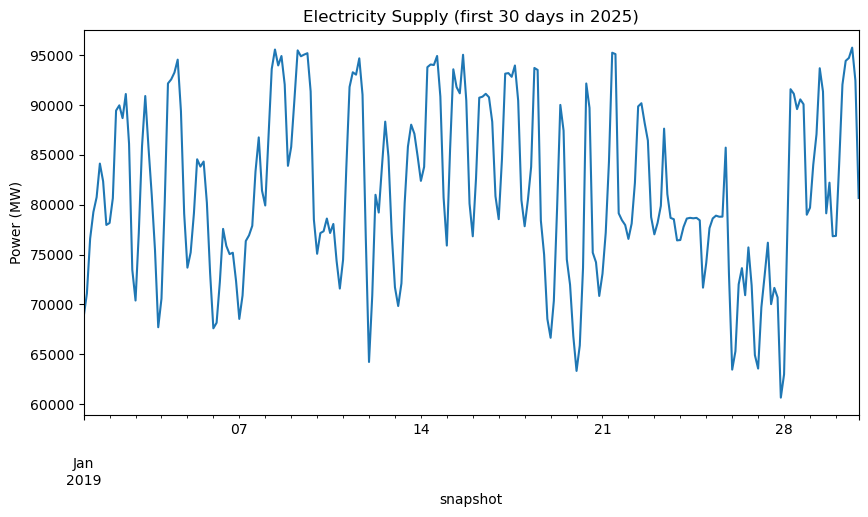

In [26]:
# check if suppl in MW is in realistic range
fig, ax = plt.subplots(figsize=(10, 5))

(electricity_supply.sum()[: 30 * 8] / 3).plot(ax=ax)
ax.set_ylabel("Power (MW)")
ax.set_title("Electricity Supply (first 30 days in 2025)")

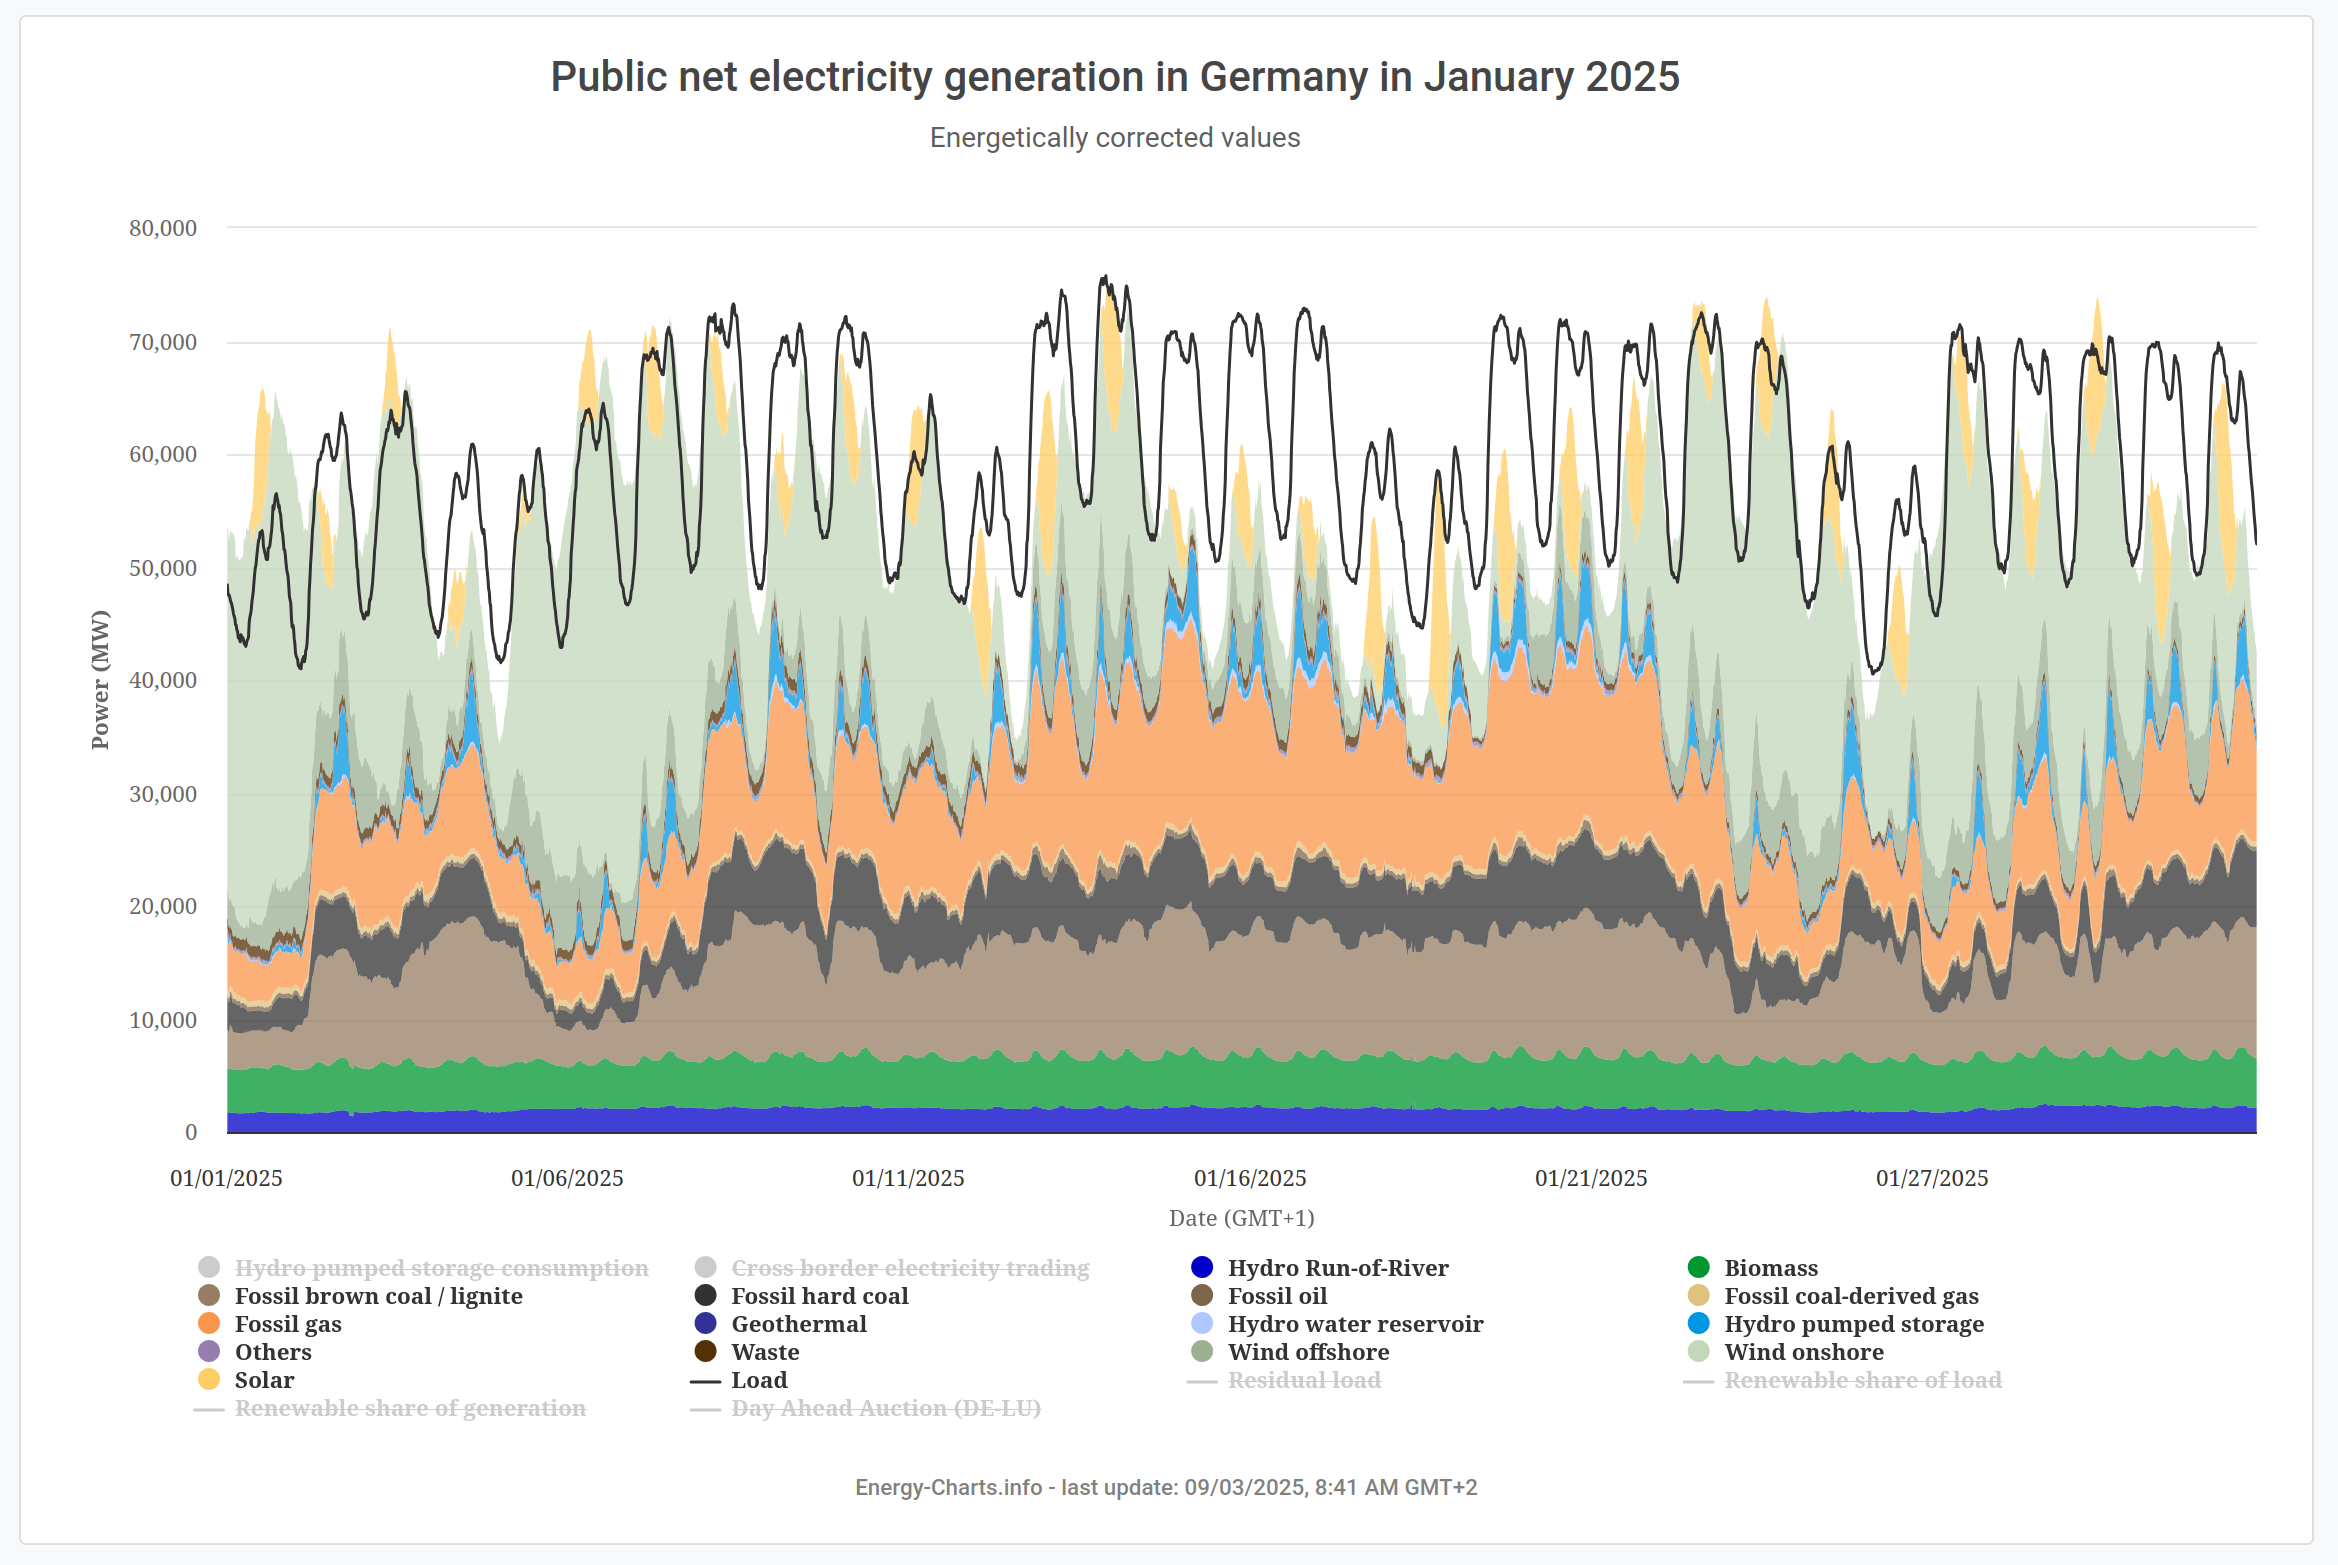

In [27]:
Image("images/elec_balance_de_real_jan25.png", width=800)
# https://www.energy-charts.info/charts/power/chart.htm?c=DE&interval=month&month=01&source=public

## Power (MW) vs Energy (MWh)
- calc_supply_demand function returns a df with 3H resolution (2920 values) either in energy (MWh) if energy=True or in Power (MW) if energy=False
- as the goal is to use 1H resolution in the modelling and for cosistency, the data is scaled to 1H resolution

In [28]:
def expand_to_1h(df: pd.DataFrame, unit: str, tol: float = 1e-9) -> pd.DataFrame:
    """
    Convert a DataFrame with any time resolution to 1-hourly resolution.

    Parameters
    ----------
    df : pd.DataFrame
        Original DataFrame with carriers as index and snapshots as columns
    unit : str
        Unit of the input data (required):
        - 'energy' or 'MWh': input is energy, will be converted to average power
        - 'power' or 'MW': input is already power, will be repeated
    tol : float, default 1e-9
        Tolerance for checking total energy/power consistency

    Returns
    -------
    pd.DataFrame
        1-hourly DataFrame with carriers as index and hourly snapshots as columns
        Units will be MW (power)
    """

    # --- Transpose so snapshots are rows ---
    df_work = df.T.copy()
    df_work.index = pd.to_datetime(df_work.index)
    df_work.index.name = "snapshot"

    # --- Determine time resolution ---
    if len(df_work.index) < 2:
        raise ValueError(
            "DataFrame must have at least 2 time points to determine resolution"
        )

    time_diff = df_work.index[1] - df_work.index[0]
    resolution_hours = time_diff.total_seconds() / 3600

    if resolution_hours <= 0:
        raise ValueError("Time resolution must be positive")

    # print(f"Detected time resolution: {resolution_hours}H")

    # --- Determine unit and conversion factor ---
    if unit.lower() in ["energy", "mwh"]:
        detected_unit = "energy"
        conversion_factor = resolution_hours
        # print(f"Using unit: energy (MWh per {resolution_hours}H block)")
    elif unit.lower() in ["power", "mw"]:
        detected_unit = "power"
        conversion_factor = 1.0
        # print(f"Using unit: power (MW)")
    else:
        raise ValueError("Unit must be 'energy'/'MWh' or 'power'/'MW'")

    # --- Convert to MW if needed ---
    if detected_unit == "energy":
        df_mw = df_work / conversion_factor
    else:
        df_mw = df_work.copy()

    # --- Create 1-hourly index ---
    start = df_mw.index[0]
    # Extend to cover the last block fully
    end = df_mw.index[-1] + pd.Timedelta(hours=resolution_hours - 1)
    hourly_index = pd.date_range(start=start, end=end, freq="1h")

    # --- Reindex and forward-fill ---
    df_mw_reindexed = df_mw.reindex(hourly_index)
    df_mw_1h = df_mw_reindexed.ffill()

    # --- Transpose back so carriers are rows ---
    df_1h = df_mw_1h.T

    # --- Sanity checks ---
    if detected_unit == "energy":
        # For energy: check total energy conservation
        total_original = df.values.sum()
        total_1h = df_1h.values.sum()  # MW values, when multiplied by 1h give MWh

        if not np.isclose(total_original, total_1h, rtol=tol):
            print(
                f"WARNING: total energy mismatch! "
                f"Original sum={total_original:.1f} MWh, "
                f"1H sum={total_1h:.1f} MWh"
            )
    else:
        # For power: check that total energy scales correctly by resolution
        total_original_energy = df.values.sum() * resolution_hours  # MW * hours = MWh
        total_1h_energy = df_1h.values.sum() * 1  # MW * 1h = MWh

        if not np.isclose(total_original_energy, total_1h_energy, rtol=tol):
            print(
                f"WARNING: power scaling mismatch! "
                f"Original total energy={total_original_energy:.1f} MWh, "
                f"1H total energy={total_1h_energy:.1f} MWh"
            )

    return df_1h

Verify that function works

In [29]:
s, d = calc_supply_demand(
    networks[2020],
    energy=False,
    interconnectors=False,
    merge_dist_grid=True,
    drop_dist_grid=True,
    add_diff_as_import=True,
)

In [30]:
s_1H = expand_to_1h(s, unit="power")
d_1H = expand_to_1h(d, unit="power")

In [31]:
s.sum().sum() * 3 == s_1H.sum().sum()
d.sum().sum() * 3 == d_1H.sum().sum()

True

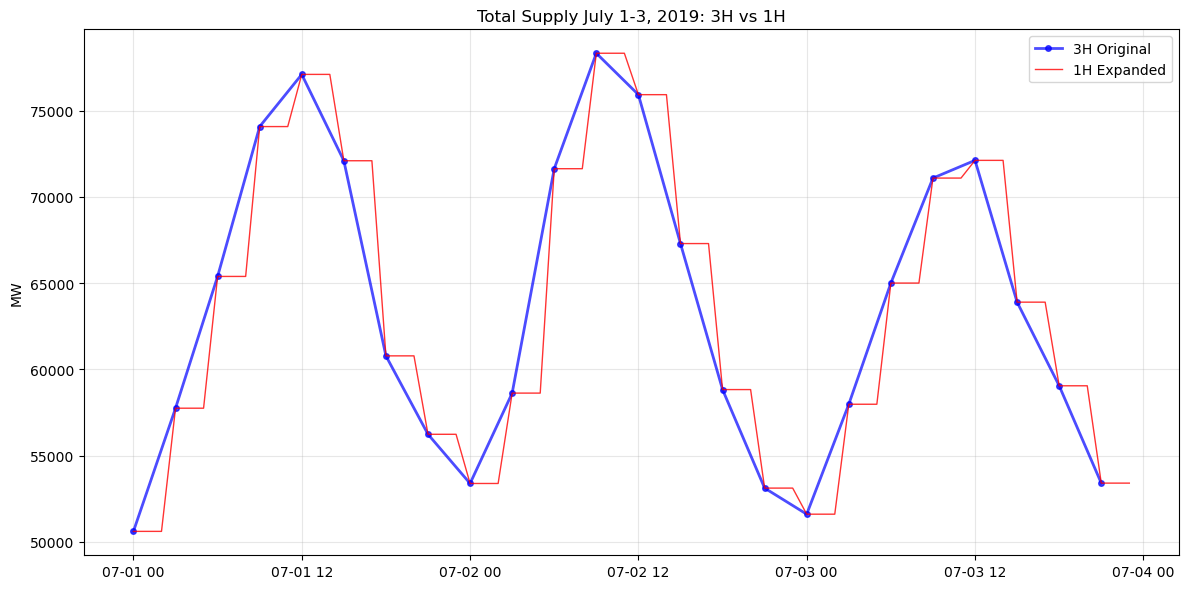

Supply - 3H points: 2920 | 1H points: 8760
Supply energy - 3H: 566.5 TWh | 1H: 566.5 TWh
Demand energy - 3H: 566.5 TWh | 1H: 566.5 TWh
Demand expansion identical: True


In [32]:
# Get totals across all carriers
s_total_3H = s.sum(axis=0)
s_total_1H = s_1H.sum(axis=0)
d_total_3H = d.sum(axis=0)
d_total_1H = d_1H.sum(axis=0)

# Filter for three days (e.g., July 1-3)
days_3H = s_total_3H["2019-07-01":"2019-07-03"]
days_1H = s_total_1H["2019-07-01":"2019-07-03"]

# Single supply plot
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.plot(
    days_3H.index,
    days_3H.values,
    "bo-",
    linewidth=2,
    markersize=4,
    label="3H Original",
    alpha=0.7,
)
ax.plot(
    days_1H.index, days_1H.values, "r-", linewidth=1, label="1H Expanded", alpha=0.8
)
ax.set_title("Total Supply July 1-3, 2019: 3H vs 1H")
ax.set_ylabel("MW")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print stats
print(f"Supply - 3H points: {len(s_total_3H)} | 1H points: {len(s_total_1H)}")
print(
    f"Supply energy - 3H: {(s_total_3H.sum() * 3 / 1e6):.1f} TWh | 1H: {(s_total_1H.sum() / 1e6):.1f} TWh"
)
print(
    f"Demand energy - 3H: {(d_total_3H.sum() * 3 / 1e6):.1f} TWh | 1H: {(d_total_1H.sum() / 1e6):.1f} TWh"
)
print(
    f"Demand expansion identical: {abs((d_total_3H.sum() * 3) - d_total_1H.sum()) < 1e-6}"
)

In [33]:
s, d = calc_supply_demand(
    networks[2020],
    energy=True,
    interconnectors=False,
    merge_dist_grid=True,
    drop_dist_grid=True,
    add_diff_as_import=True,
)

In [34]:
s_1H = expand_to_1h(s, unit="energy")
d_1H = expand_to_1h(d, unit="energy")

In [35]:
s.sum().sum() - s_1H.sum().sum() < 1e-5
d.sum().sum() - d_1H.sum().sum() < 1e-5

True

# Residual load
- Definition: non dispatchable demand - non dispatchable supply
- **Mainstreaming RES (Artelys):**
*The residual load is defined as the load that must be served by dispatchable technologies (such as thermal generation, hydro, storage, demand response, and interconnectors). It is computed by subtracting wind, solar, and other must-run generation from the total demand.*

In [36]:
# carriers
non_dispatchable_supply_carriers = [
    "onwind",
    "offwind-ac",
    "offwind-dc",
    "solar",
    "solar-hsat",
    "solar rooftop",
    "ror",
]
non_dispatchable_demand_carriers = [
    "electricity",
    "agriculture electricity",
    "industry electricity",
]

In [37]:
s, d = calc_supply_demand(
    networks[2020],
    energy=False,
    interconnectors=False,
    merge_dist_grid=True,
    drop_dist_grid=True,
    add_diff_as_import=True,
)
electricity_supply = expand_to_1h(s, unit="power")
electricity_demand = expand_to_1h(d, unit="power")

In [38]:
nds_avail = [
    tech
    for tech in non_dispatchable_supply_carriers
    if tech in electricity_supply.index
]
non_dispatchable_gen = electricity_supply.loc[nds_avail].sum()

ndd_avail = [
    carrier
    for carrier in non_dispatchable_demand_carriers
    if carrier in electricity_demand.index
]
non_dispatchable_con = electricity_demand.loc[ndd_avail].sum()

residual_load = non_dispatchable_con - non_dispatchable_gen

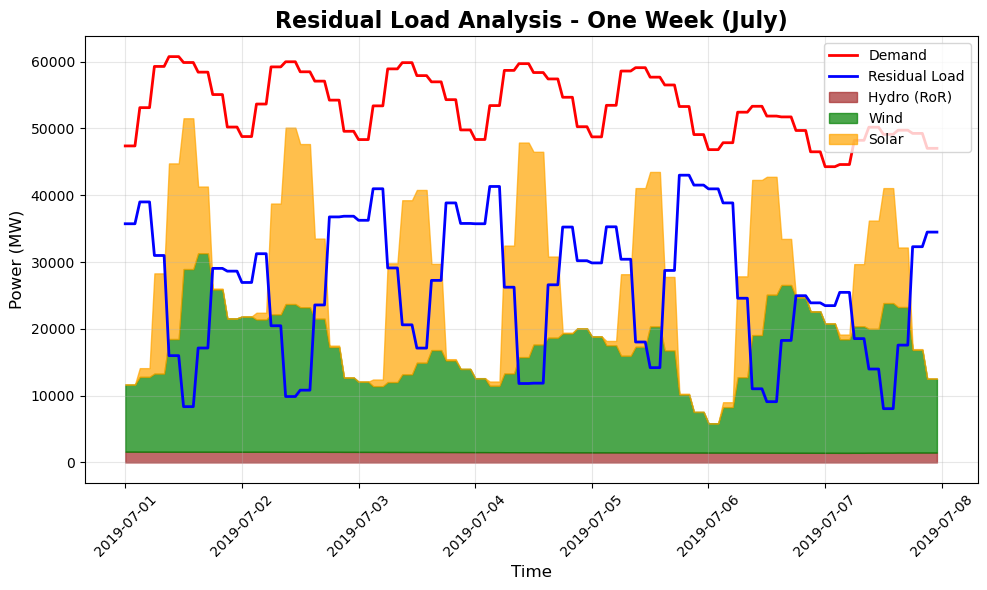

In [39]:
# Get individual renewable sources for plotting
wind_gen = electricity_supply.loc[
    [
        tech
        for tech in ["onwind", "offwind-ac", "offwind-dc"]
        if tech in electricity_supply.index
    ]
].sum()
solar_gen = electricity_supply.loc[
    [
        tech
        for tech in ["solar", "solar-hsat", "solar rooftop"]
        if tech in electricity_supply.index
    ]
].sum()
hydro_ror = (
    electricity_supply.loc[["ror"]].sum()
    if "ror" in electricity_supply.index
    else pd.Series(0, index=non_dispatchable_gen.index)
)

# Filter for one week for better visualization
week_start = "2019-07-01"
week_end = "2019-07-07"

demand_week = non_dispatchable_con[week_start:week_end]
residual_week = residual_load[week_start:week_end]
wind_week = wind_gen[week_start:week_end]
solar_week = solar_gen[week_start:week_end]
hydro_week = hydro_ror[week_start:week_end]

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot demand line (red)
ax.plot(
    demand_week.index, demand_week.values, "r-", linewidth=2, label="Demand", zorder=5
)

# Plot residual load line (blue)
ax.plot(
    residual_week.index,
    residual_week.values,
    "b-",
    linewidth=2,
    label="Residual Load",
    zorder=4,
)

# Create stacked areas for renewables
# Start from zero and build up
zero_line = pd.Series(0, index=demand_week.index)

# Plot areas (from bottom up)
ax.fill_between(
    demand_week.index,
    zero_line,
    hydro_week,
    color="brown",
    alpha=0.7,
    label="Hydro (RoR)",
)

ax.fill_between(
    demand_week.index,
    hydro_week,
    hydro_week + wind_week,
    color="green",
    alpha=0.7,
    label="Wind",
)

ax.fill_between(
    demand_week.index,
    hydro_week + wind_week,
    hydro_week + wind_week + solar_week,
    color="orange",
    alpha=0.7,
    label="Solar",
)

# Formatting
ax.set_title("Residual Load Analysis - One Week (July)", fontsize=16, fontweight="bold")
ax.set_ylabel("Power (MW)", fontsize=12)
ax.set_xlabel("Time", fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")

# Format x-axis
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Processing year 2020...
Processing year 2025...
Processing year 2030...
Processing year 2035...
Processing year 2040...
Processing year 2045...


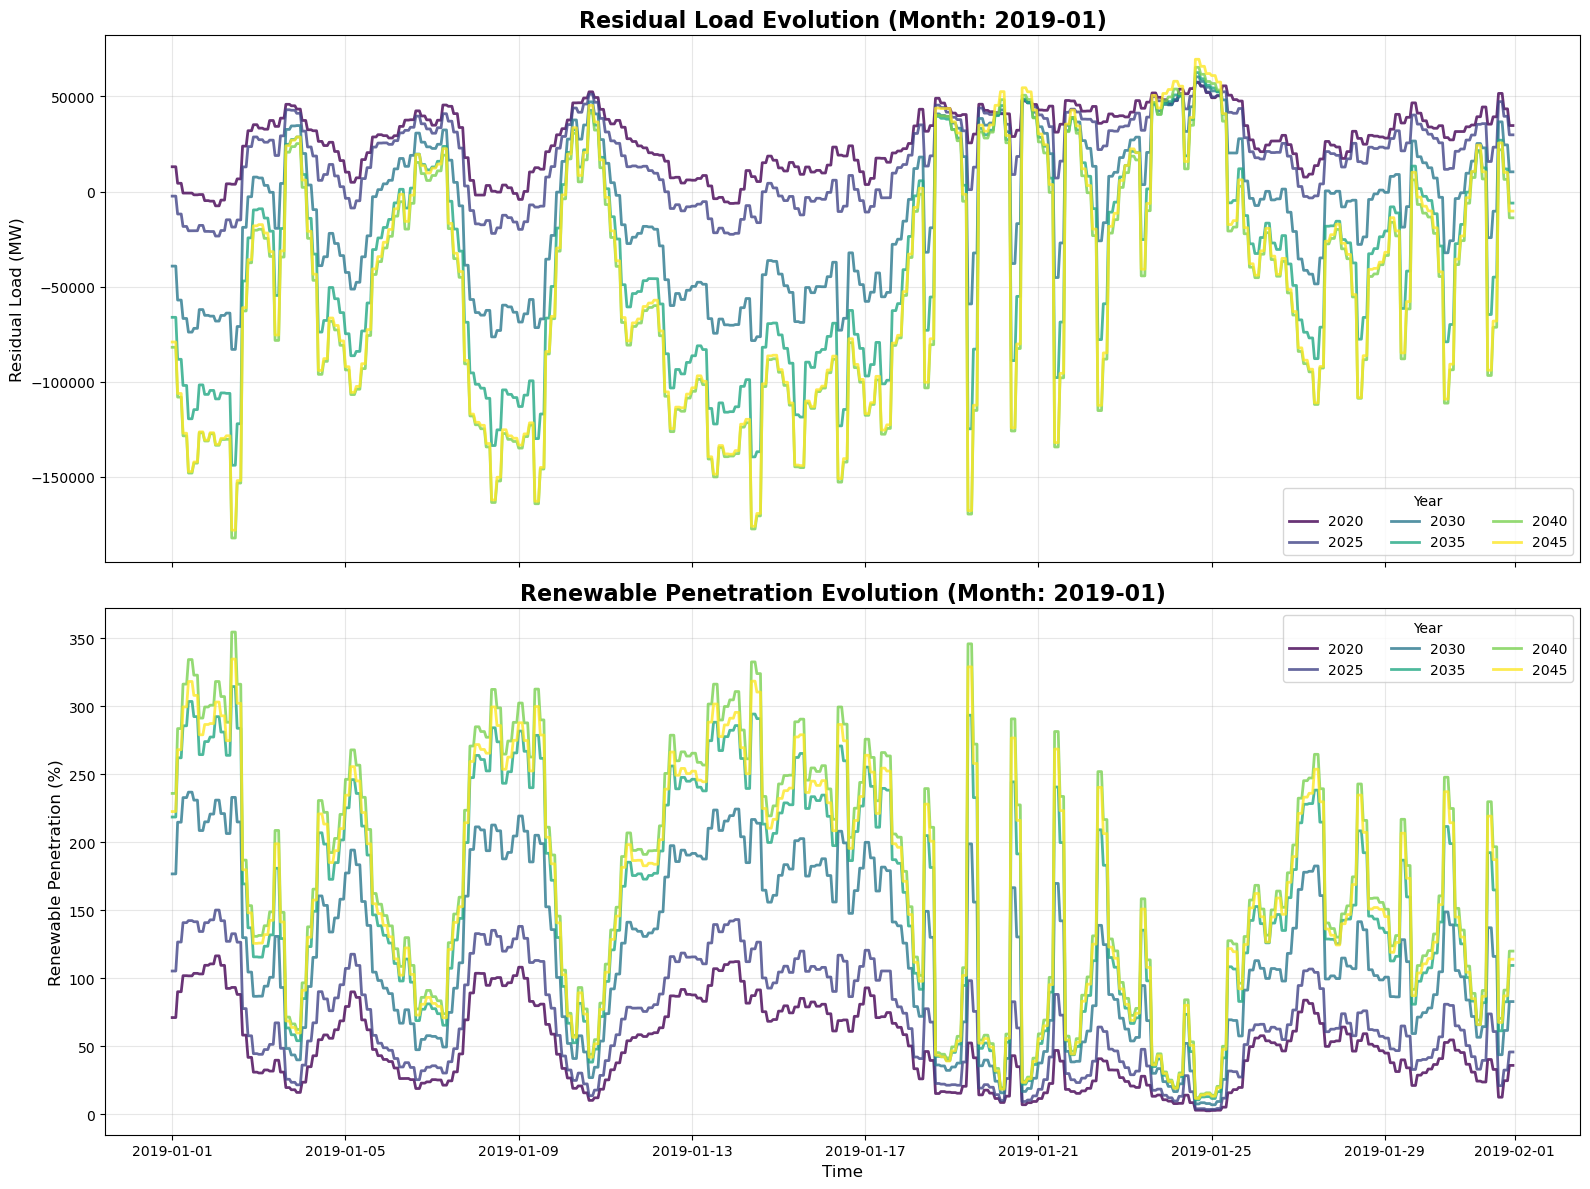

In [40]:
# Define years and time period
years = [2020, 2025, 2030, 2035, 2040, 2045]
month = "2019-01"  # Set to None for whole year, or '2019-07' for July, etc.

# Storage for results
residual_loads = {}
demands = {}
renewable_gens = {}

# Calculate residual load for each year
for year in years:
    print(f"Processing year {year}...")

    # Get supply and demand data
    s, d = calc_supply_demand(
        networks[year],
        energy=False,
        interconnectors=False,
        merge_dist_grid=True,
        drop_dist_grid=True,
        add_diff_as_import=True,
    )

    # Expand to 1H
    electricity_supply = expand_to_1h(s, unit="power")
    electricity_demand = expand_to_1h(d, unit="power")

    # Calculate residual load using the new function
    residual_load = calc_residual_load(electricity_supply, electricity_demand)

    # Store results for plotting
    residual_loads[year] = residual_load
    demands[year] = electricity_demand.loc[
        ["electricity", "agriculture electricity", "industry electricity"]
    ].sum()
    renewable_gens[year] = electricity_supply.loc[
        [
            "onwind",
            "offwind-ac",
            "offwind-dc",
            "solar",
            "solar-hsat",
            "solar rooftop",
            "ror",
        ]
    ].sum()

# Filter data based on month parameter
if month:
    # Plot specific month
    plot_data = {
        year: residual_loads[year][month]
        for year in years
        if month in residual_loads[year].index
    }
    title_period = f"Month: {month}"
else:
    # Plot whole year
    plot_data = residual_loads
    title_period = "Full Year"

# Create the plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# Color palette for years
colors = plt.cm.viridis(np.linspace(0, 1, len(years)))

# Plot 1: Residual loads for all years
for i, year in enumerate(years):
    if year in plot_data and len(plot_data[year]) > 0:
        ax1.plot(
            plot_data[year].index,
            plot_data[year].values,
            color=colors[i],
            linewidth=2,
            label=f"{year}",
            alpha=0.8,
        )

ax1.set_title(
    f"Residual Load Evolution ({title_period})", fontsize=16, fontweight="bold"
)
ax1.set_ylabel("Residual Load (MW)", fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend(title="Year", ncol=3)

# Plot 2: Renewable penetration over years
for i, year in enumerate(years):
    if month:
        demand_data = demands[year][month] if month in demands[year].index else None
        renewable_data = (
            renewable_gens[year][month] if month in renewable_gens[year].index else None
        )
    else:
        demand_data = demands[year]
        renewable_data = renewable_gens[year]

    if demand_data is not None and renewable_data is not None and len(demand_data) > 0:
        penetration = renewable_data / demand_data * 100
        ax2.plot(
            penetration.index,
            penetration.values,
            color=colors[i],
            linewidth=2,
            label=f"{year}",
            alpha=0.8,
        )

ax2.set_title(
    f"Renewable Penetration Evolution ({title_period})", fontsize=16, fontweight="bold"
)
ax2.set_ylabel("Renewable Penetration (%)", fontsize=12)
ax2.set_xlabel("Time", fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(title="Year", ncol=3)

plt.tight_layout()
plt.show()

In [41]:
# Resiual load vs prices
year = 2020
s, d = calc_supply_demand(
    networks[year],
    energy=False,
    interconnectors=False,
    merge_dist_grid=True,
    drop_dist_grid=True,
    add_diff_as_import=True,
)

# Calculate residual load using the new function
residual_load = calc_residual_load(s, d)

ac_de = (
    networks[year]
    .buses.query('carrier in ["low voltage", "AC"] and index.str.startswith("DE")')
    .index
)
lmps_de = networks[year].buses_t.marginal_price[ac_de].mean(axis=1)

(0.0, 100.0)

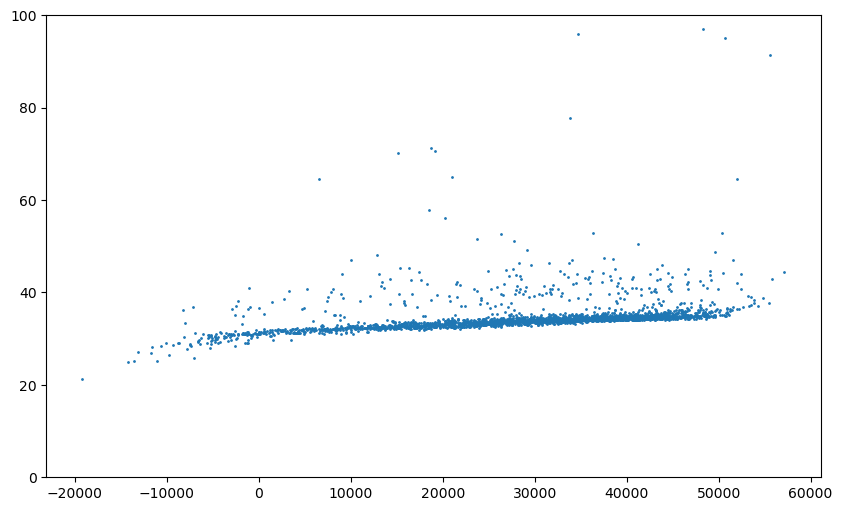

In [42]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(residual_load, lmps_de, s=1)
ax.set_ylim(0, 100)

# Flexibility needs

- to calc the flexibility needs, the residual load has to be aggregated over different time horizons: daily, weekly, monthly, annual; as this is prone to errors we start with simple resampling
- we use:

```
residual_load.resample('D').transform('mean')
residual_load.resample('W').transform('mean')
residual_load.resample('MS').transform('mean')
residual_load.resample('YS').transform('mean')
```

**Pandas Resampling:** `resample()` vs `resample().transform()`

`resample('D').mean()`
- **Groups** data by day and calculates one mean per day
- **Reduces** data size (8760 hours → 365 days)
- **Returns** new shorter time series

`resample('D').transform('mean')`
- **Groups** data by day, calculates mean, then **broadcasts back** to original resolution
- **Keeps** original data size (8760 hours → 8760 hours)
- **Returns** same length series where each hour = its daily average

**Notes:**
- "W-SUN" means weeks ending on Sunday, which is equivalent to "W"
- "ME" or "MS" is effectively the same if you use transform; only difference would be that ME if you only take mean uses the last day of the month to label the mean e.g. 2019-01-31 for January and MS uses the first day 2019-01-01

**Sources:**
- https://pandas.pydata.org/docs/user_guide/timeseries.html


In [43]:
year = 2020
s, d = calc_supply_demand(
    networks[year],
    energy=False,
    interconnectors=False,
    merge_dist_grid=True,
    drop_dist_grid=True,
    add_diff_as_import=True,
)

electricity_supply = expand_to_1h(s, unit="power")
electricity_demand = expand_to_1h(d, unit="power")

residual_load = calc_residual_load(electricity_supply, electricity_demand)

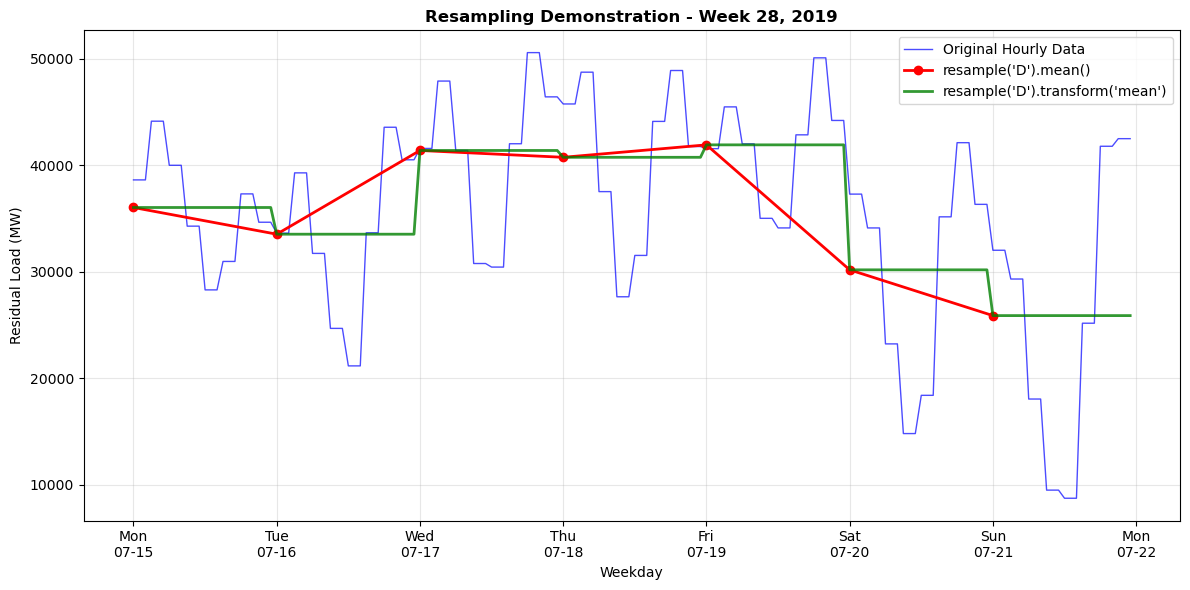

In [44]:
# Daily resampling

# RESAMPLING FUNCTIONS DEMONSTRATED:
# residual_load.resample('D').mean()           - Daily averages (one value per day)
# residual_load.resample('D').transform('mean') - Daily averages broadcast to hourly (24 values per day)

# Parameters
year = 2019
week_number = 28  # ISO week number (1-53)

# Get the specific week (Monday to Sunday)
week_start = pd.to_datetime(f"{year}-W{week_number}-1", format="%Y-W%W-%w")
week_end = week_start + pd.Timedelta(days=6, hours=23)

# Filter residual load for the week
week_residual = residual_load[week_start:week_end]

# Apply resampling
daily_mean = week_residual.resample("D").mean()
daily_transform = week_residual.resample("D").transform("mean")

# Single plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot original hourly data
ax.plot(
    week_residual.index,
    week_residual.values,
    "b-",
    linewidth=1,
    label="Original Hourly Data",
    alpha=0.7,
)

# Plot daily means as step function
ax.plot(
    daily_mean.index,
    daily_mean.values,
    "ro-",
    linewidth=2,
    markersize=6,
    label="resample('D').mean()",
)

# Plot transform (broadcasted daily means)
ax.plot(
    daily_transform.index,
    daily_transform.values,
    "g-",
    linewidth=2,
    label="resample('D').transform('mean')",
    alpha=0.8,
)

ax.set_title(
    f"Resampling Demonstration - Week {week_number}, {year}", fontweight="bold"
)
ax.set_ylabel("Residual Load (MW)")
ax.set_xlabel("Weekday")
ax.grid(True, alpha=0.3)
ax.legend()

# Format x-axis to show weekdays and dates
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a\n%m-%d"))

plt.tight_layout()
plt.show()

Plotting January 2019


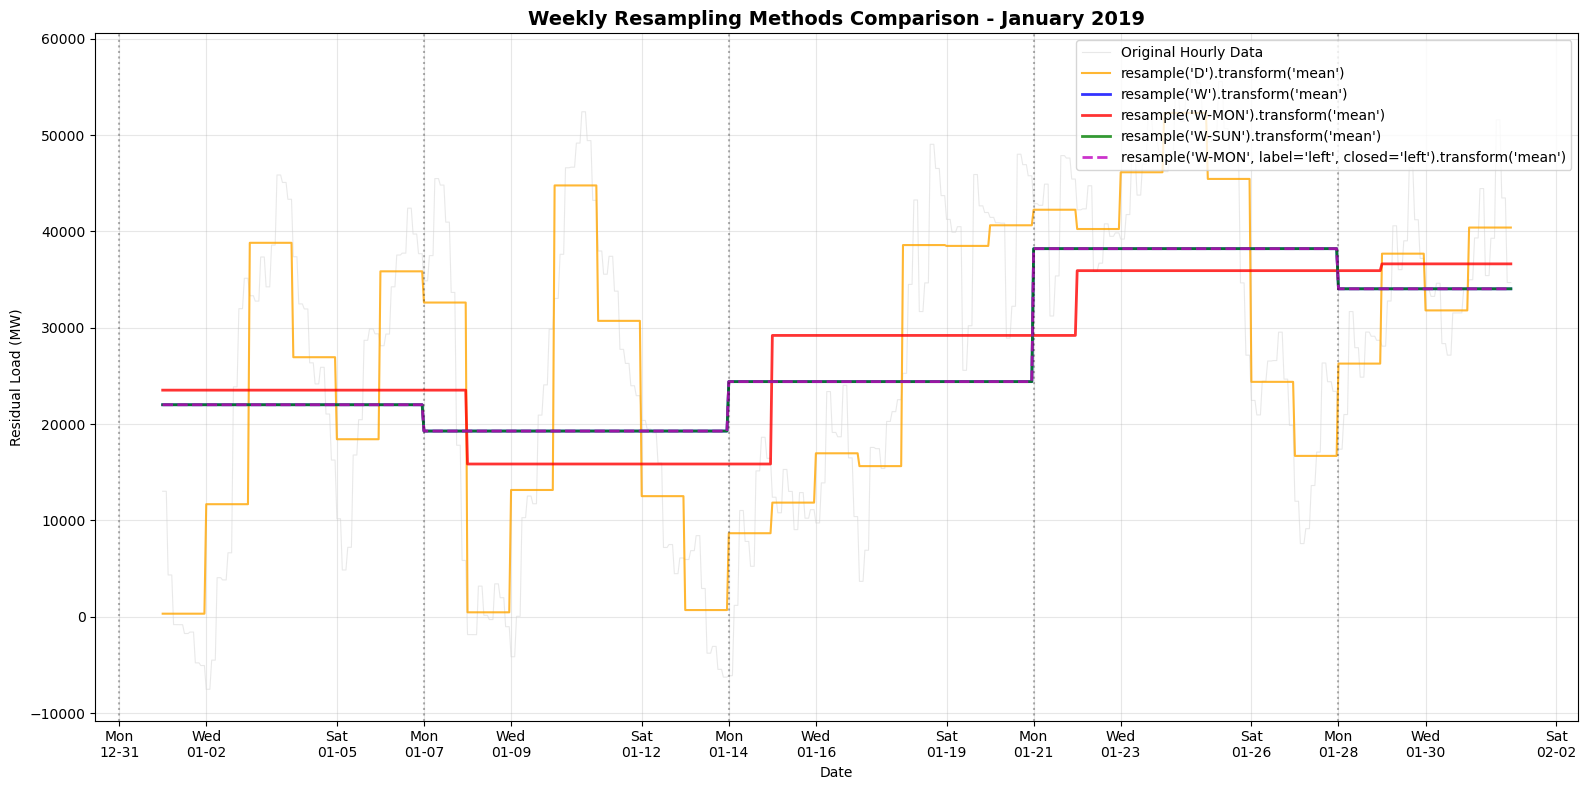

In [45]:
import matplotlib.pyplot as plt
import pandas as pd

# DIFFERENT WEEKLY RESAMPLING FUNCTIONS COMPARED:
# resample('W').transform('mean')                                   - Default weekly (Sunday)
# resample('W-MON').transform('mean')                               - Monday-anchored weekly
# resample('W-SUN').transform('mean')                               - Sunday-anchored weekly
# resample('W-MON', label='left', closed='left').transform('mean') - Monday start, left-labeled

# Parameters
year = 2019
month = 1  # July (1-12)

# Get the specific month
month_start = pd.to_datetime(f"{year}-{month:02d}-01")
if month == 12:
    month_end = pd.to_datetime(f"{year + 1}-01-01") - pd.Timedelta(hours=1)
else:
    month_end = pd.to_datetime(f"{year}-{month + 1:02d}-01") - pd.Timedelta(hours=1)

print(f"Plotting {month_start.strftime('%B %Y')}")

# Filter residual load for the month
month_residual = residual_load[month_start:month_end]

# Apply different resampling methods
daily_transform = month_residual.resample("D").transform("mean")
w_default = month_residual.resample("W").transform("mean")
w_mon = month_residual.resample("W-MON").transform("mean")
w_sun = month_residual.resample("W-SUN").transform("mean")
w_mon_left = month_residual.resample("W-MON", label="left", closed="left").transform(
    "mean"
)

# Create plot
fig, ax = plt.subplots(figsize=(16, 8))

# Plot original hourly data
ax.plot(
    month_residual.index,
    month_residual.values,
    "lightgray",
    linewidth=0.8,
    label="Original Hourly Data",
    alpha=0.5,
)

# Plot daily transform
ax.plot(
    daily_transform.index,
    daily_transform.values,
    "orange",
    linewidth=1.5,
    label="resample('D').transform('mean')",
    alpha=0.8,
)

# Plot different weekly transforms
ax.plot(
    w_default.index,
    w_default.values,
    "b-",
    linewidth=2,
    label="resample('W').transform('mean')",
    alpha=0.8,
)

ax.plot(
    w_mon.index,
    w_mon.values,
    "r-",
    linewidth=2,
    label="resample('W-MON').transform('mean')",
    alpha=0.8,
)

ax.plot(
    w_sun.index,
    w_sun.values,
    "g-",
    linewidth=2,
    label="resample('W-SUN').transform('mean')",
    alpha=0.8,
)

ax.plot(
    w_mon_left.index,
    w_mon_left.values,
    "m--",
    linewidth=2,
    label="resample('W-MON', label='left', closed='left').transform('mean')",
    alpha=0.8,
)

# Add Monday markers for reference
mondays = pd.date_range(
    start=month_start - pd.Timedelta(days=7),
    end=month_end + pd.Timedelta(days=7),
    freq="W-MON",
)
for monday in mondays:
    if monday >= month_start - pd.Timedelta(
        days=3
    ) and monday <= month_end + pd.Timedelta(days=3):
        ax.axvline(x=monday, color="black", linestyle=":", alpha=0.3)

ax.set_title(
    f"Weekly Resampling Methods Comparison - {month_start.strftime('%B %Y')}",
    fontweight="bold",
    fontsize=14,
)
ax.set_ylabel("Residual Load (MW)")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", fontsize=10)

# Format x-axis to show only Monday, Wednesday, Saturday
import matplotlib.dates as mdates

ax.xaxis.set_major_formatter(mdates.DateFormatter("%a\n%m-%d"))
ax.xaxis.set_major_locator(
    mdates.WeekdayLocator(byweekday=[mdates.MO, mdates.WE, mdates.SA])
)

plt.tight_layout()
plt.show()

In [46]:
w_default = residual_load.resample("W").transform("mean")
w_sun = residual_load.resample("W-SUN").transform("mean")
w_mon_left = residual_load.resample("W-MON", label="left", closed="left").transform(
    "mean"
)

(w_default == w_sun).all() and (w_sun == w_mon_left).all()

True

In [47]:
# check if date is right and mean is right

# Get resampled data
weekly_resampled = residual_load.resample("W").transform("mean")

# Compare for multiple weeks
year = 2019
comparison_results = []

for week_num in range(1, 53):  # All weeks
    # ISO week selection
    week_start = pd.to_datetime(f"{year}-W{week_num}-1", format="%Y-W%W-%w")
    week_end = week_start + pd.Timedelta(days=6, hours=23)

    # Manual ISO week mean
    iso_week_data = residual_load[week_start:week_end]
    if len(iso_week_data) > 0:
        iso_mean = iso_week_data.mean()

        # Resampling mean for same period
        resample_week_data = weekly_resampled[week_start:week_end]
        resample_mean = (
            resample_week_data.iloc[0] if len(resample_week_data) > 0 else None
        )

        # Check if all days in week have same mean
        all_same = (
            (resample_week_data == resample_mean).all()
            if len(resample_week_data) > 0
            else False
        )

        # Compare means
        means_equal = (
            abs(iso_mean - resample_mean) < 1e-10
            if resample_mean is not None
            else False
        )

        comparison_results.append(
            {
                "week": week_num,
                "iso_mean": iso_mean,
                "resample_mean": resample_mean,
                "means_equal": means_equal,
                "all_days_same": all_same,
            }
        )

# Results
df_results = pd.DataFrame(comparison_results)
print(f"Means equal for all weeks: {df_results['means_equal'].all()}")
print(f"All days same within each week: {df_results['all_days_same'].all()}")

# Show any mismatches
if not df_results["means_equal"].all():
    print("Mismatched weeks:")
    print(df_results[~df_results["means_equal"]][["week", "iso_mean", "resample_mean"]])

Means equal for all weeks: True
All days same within each week: True


Monthly means equal: True
All days same within months: True


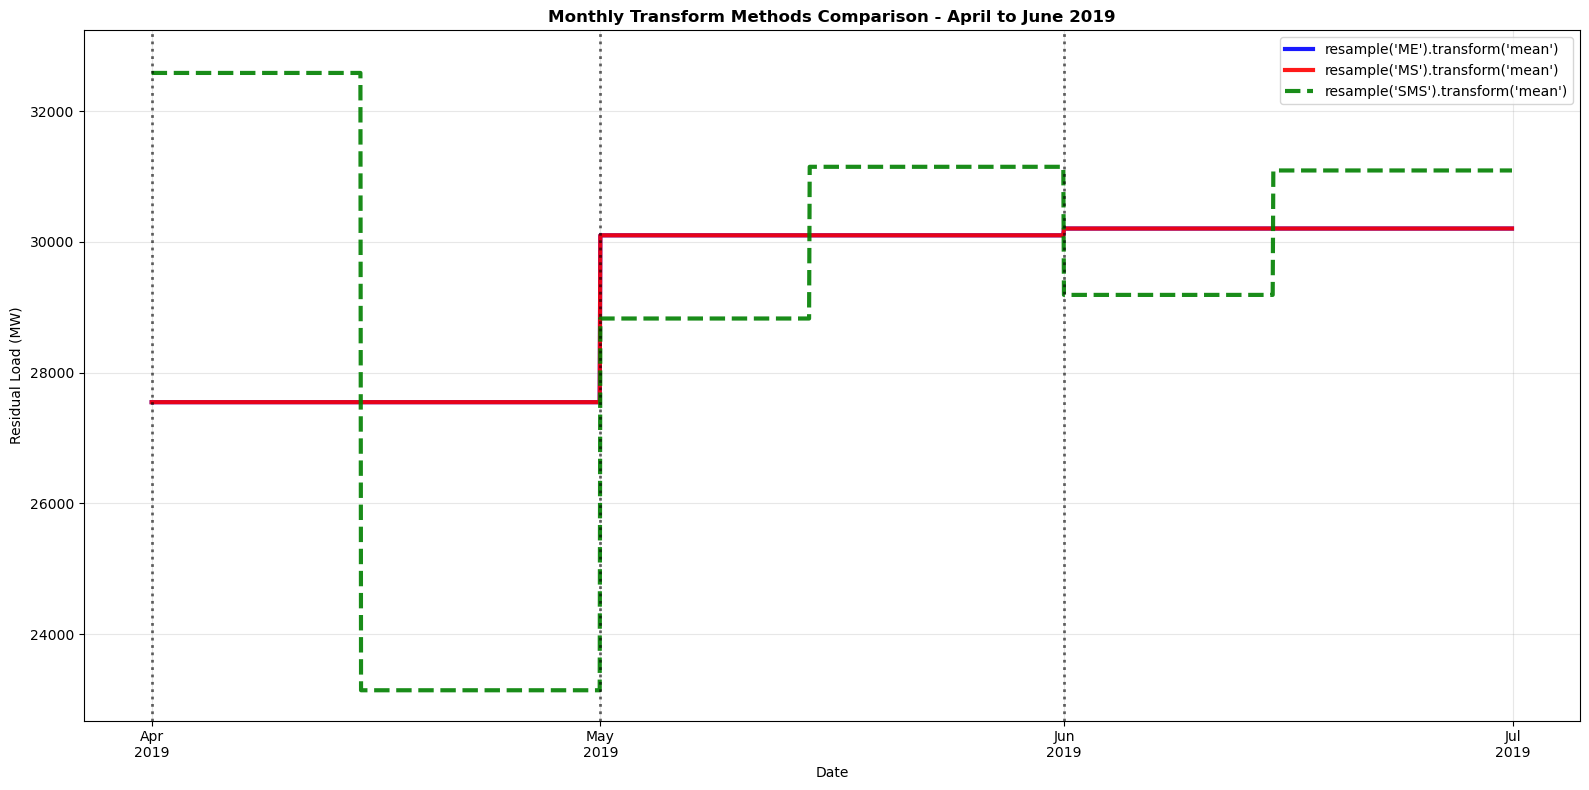

In [48]:
# DIFFERENT MONTHLY RESAMPLING FUNCTIONS COMPARED:
# resample('ME').transform('mean')                     - Month end
# resample('MS').transform('mean')                     - Month start
# resample('SMS').transform('mean')                    - Semi-month start

# Get monthly resampled data
monthly_resampled = residual_load.resample("MS").transform("mean")

# Compare manual vs resampling for all months
year = 2019
comparison_results = []

for month in range(1, 13):
    month_start = pd.to_datetime(f"{year}-{month:02d}-01")
    if month == 12:
        month_end = pd.to_datetime(f"{year + 1}-01-01") - pd.Timedelta(hours=1)
    else:
        month_end = pd.to_datetime(f"{year}-{month + 1:02d}-01") - pd.Timedelta(hours=1)

    # Manual monthly mean
    month_data = residual_load[month_start:month_end]
    if len(month_data) > 0:
        manual_mean = month_data.mean()
        resample_mean = monthly_resampled[month_start:month_end].iloc[0]
        means_equal = abs(manual_mean - resample_mean) < 1e-10
        all_same = (monthly_resampled[month_start:month_end] == resample_mean).all()

        comparison_results.append(
            {
                "month": month,
                "manual_mean": manual_mean,
                "resample_mean": resample_mean,
                "means_equal": means_equal,
                "all_days_same": all_same,
            }
        )

df_results = pd.DataFrame(comparison_results)
print(f"Monthly means equal: {df_results['means_equal'].all()}")
print(f"All days same within months: {df_results['all_days_same'].all()}")

# Plot 3 consecutive months in one plot
months_to_plot = [4, 5, 6]  # April, May, June (consecutive)

# Apply different monthly resampling methods
me_end = residual_load.resample("ME").transform("mean")  # Month end
ms_start = residual_load.resample("MS").transform("mean")  # Month start
sms_semi = residual_load.resample("SMS").transform("mean")  # Semi-month start

# Get data for 3 consecutive months
first_month = months_to_plot[0]
last_month = months_to_plot[-1]
start_date = pd.to_datetime(f"{year}-{first_month:02d}-01")
end_date = pd.to_datetime(f"{year}-{last_month + 1:02d}-01") - pd.Timedelta(hours=1)

# Filter data for the period
period_residual = residual_load[start_date:end_date]

fig, ax = plt.subplots(figsize=(16, 8))

# Plot only the monthly transform methods (remove original hourly for cleaner view)
ax.plot(
    me_end[start_date:end_date].index,
    me_end[start_date:end_date].values,
    "b-",
    linewidth=3,
    label="resample('ME').transform('mean')",
    alpha=0.9,
)

ax.plot(
    ms_start[start_date:end_date].index,
    ms_start[start_date:end_date].values,
    "r-",
    linewidth=3,
    label="resample('MS').transform('mean')",
    alpha=0.9,
)

ax.plot(
    sms_semi[start_date:end_date].index,
    sms_semi[start_date:end_date].values,
    "g--",
    linewidth=3,
    label="resample('SMS').transform('mean')",
    alpha=0.9,
)

# Add month boundary lines
for month in months_to_plot:
    month_start_line = pd.to_datetime(f"{year}-{month:02d}-01")
    ax.axvline(x=month_start_line, color="black", linestyle=":", alpha=0.6, linewidth=2)

# Zoom in on the monthly means by setting y-axis limits
monthly_values = pd.concat(
    [
        me_end[start_date:end_date],
        ms_start[start_date:end_date],
        sms_semi[start_date:end_date],
    ]
)
y_min = monthly_values.min() * 0.98  # Add 2% margin below
y_max = monthly_values.max() * 1.02  # Add 2% margin above
ax.set_ylim(y_min, y_max)

ax.set_title(
    f"Monthly Transform Methods Comparison - April to June {year}", fontweight="bold"
)
ax.set_ylabel("Residual Load (MW)")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

import matplotlib.dates as mdates

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())

plt.tight_layout()
plt.show()

In [49]:
(
    residual_load.resample("ME").transform("mean")
    == residual_load.resample("MS").transform("mean")
).all()

True

Plotting January to March 2019


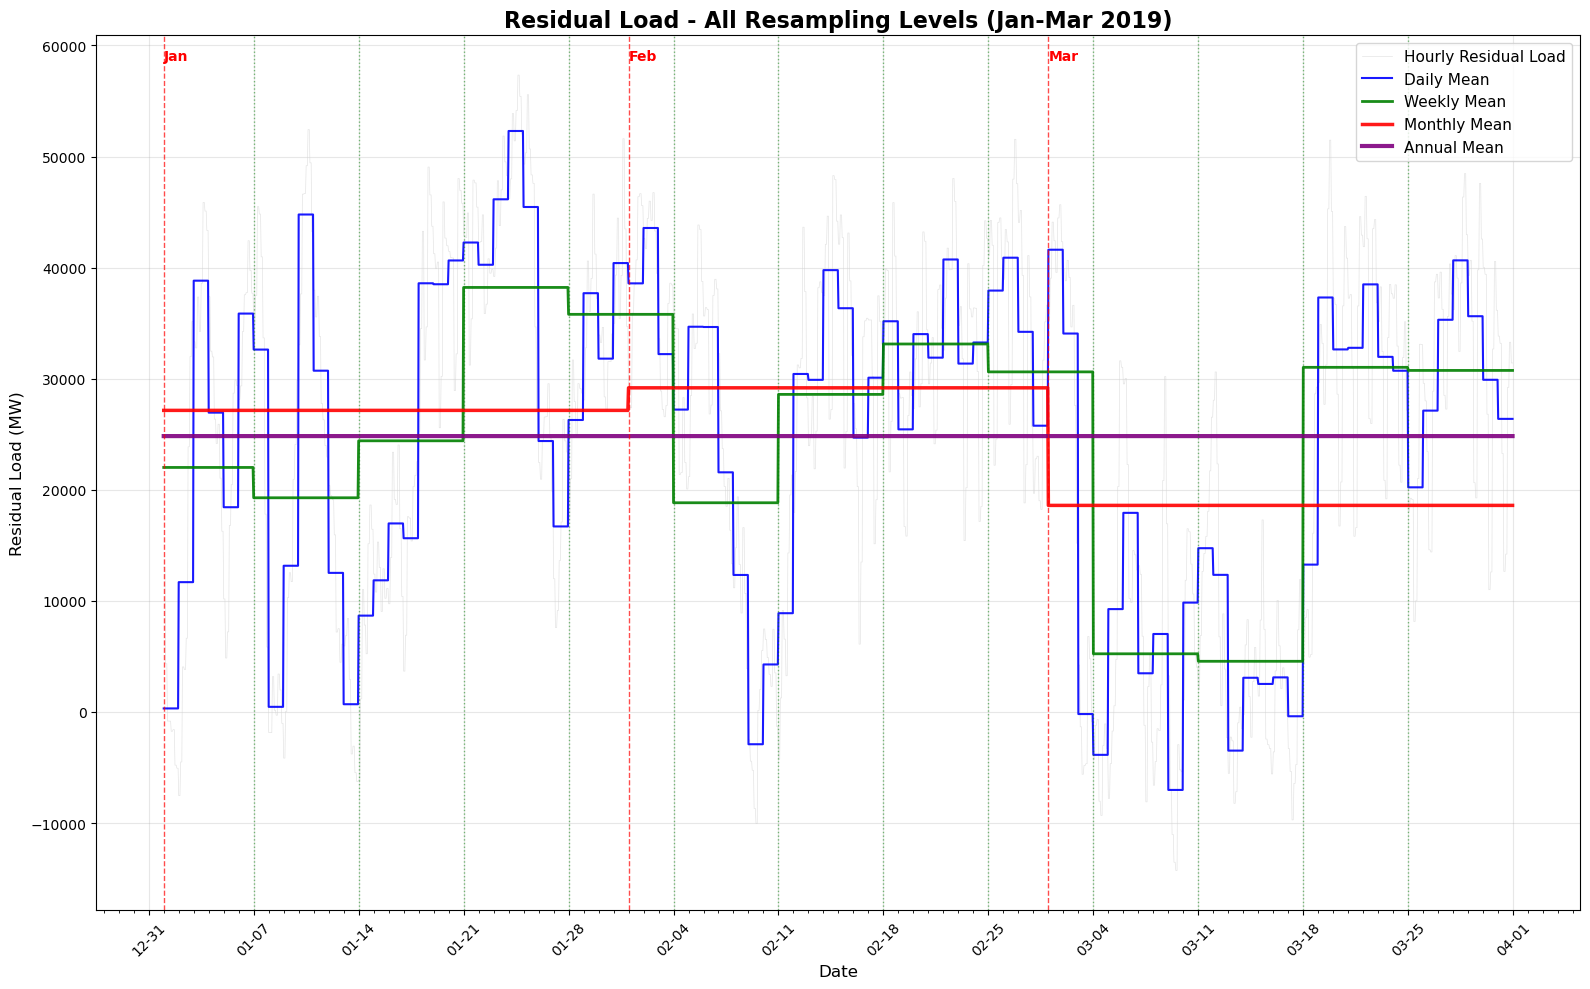


RESAMPLING SUMMARY STATISTICS (Jan-Mar)
Original (hourly)   : Mean=24833.3MW | Std=16410.9MW | Min=-14273.3MW | Max=57329.9MW | Range=71603.1MW
Daily mean          : Mean=24833.3MW | Std=14702.2MW | Min=-7020.4MW | Max=52298.8MW | Range=59319.1MW
Weekly mean         : Mean=24833.3MW | Std=10278.4MW | Min=4560.8MW | Max=38215.4MW | Range=33654.6MW
Monthly mean        : Mean=24833.3MW | Std=4597.2MW | Min=18594.5MW | Max=29177.8MW | Range=10583.3MW
Annual mean         : Mean=24833.3MW | Std=0.0MW | Min=24833.3MW | Max=24833.3MW | Range=0.0MW

Data points: Hourly=2160, Daily=2160, Weekly=2160, Monthly=2160, Annual=2160


In [50]:
# Time period: Jan-March
year = 2019
start_date = pd.to_datetime(f"{year}-01-01")
end_date = pd.to_datetime(f"{year}-03-31 23:59:59")

print(f"Plotting January to March {year}")

# Filter residual load for Jan-March
period_residual = residual_load[start_date:end_date]

# Apply different resampling transforms
daily_transform = period_residual.resample("D").transform("mean")
weekly_transform = period_residual.resample("W-SUN").transform("mean")
monthly_transform = period_residual.resample("MS").transform("mean")
annual_transform = period_residual.resample("YS").transform("mean")  # Year start

# Create the plot
fig, ax = plt.subplots(figsize=(16, 10))

# Plot all resampling levels
ax.plot(
    period_residual.index,
    period_residual.values,
    "lightgray",
    linewidth=0.5,
    label="Hourly Residual Load",
    alpha=0.6,
)

ax.plot(
    daily_transform.index,
    daily_transform.values,
    "blue",
    linewidth=1.5,
    label="Daily Mean",
    alpha=0.9,
)

ax.plot(
    weekly_transform.index,
    weekly_transform.values,
    "green",
    linewidth=2,
    label="Weekly Mean",
    alpha=0.9,
)

ax.plot(
    monthly_transform.index,
    monthly_transform.values,
    "red",
    linewidth=2.5,
    label="Monthly Mean",
    alpha=0.9,
)

ax.plot(
    annual_transform.index,
    annual_transform.values,
    "purple",
    linewidth=3,
    label="Annual Mean",
    alpha=0.9,
)

# Add month start markers
month_starts = pd.date_range(start=start_date, end=end_date, freq="MS")
for month_start in month_starts:
    ax.axvline(x=month_start, color="red", linestyle="--", alpha=0.7, linewidth=1)
    # Add month labels
    ax.text(
        month_start,
        ax.get_ylim()[1] * 0.98,
        month_start.strftime("%b"),
        ha="left",
        va="top",
        color="red",
        fontweight="bold",
    )

# Add week start markers (Mondays)
week_starts = pd.date_range(
    start=start_date - pd.Timedelta(days=7),
    end=end_date + pd.Timedelta(days=7),
    freq="W-MON",
)
for week_start in week_starts:
    if start_date <= week_start <= end_date:
        ax.axvline(x=week_start, color="green", linestyle=":", alpha=0.5, linewidth=1)

# Formatting
ax.set_title(
    f"Residual Load - All Resampling Levels (Jan-Mar {year})",
    fontsize=16,
    fontweight="bold",
)
ax.set_ylabel("Residual Load (MW)", fontsize=12)
ax.set_xlabel("Date", fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", fontsize=11)

# Format x-axis to show weeks and months
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_minor_locator(mdates.DayLocator())

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 60)
print("RESAMPLING SUMMARY STATISTICS (Jan-Mar)")
print("=" * 60)

stats = {
    "Original (hourly)": period_residual,
    "Daily mean": daily_transform,
    "Weekly mean": weekly_transform,
    "Monthly mean": monthly_transform,
    "Annual mean": annual_transform,
}

for name, data in stats.items():
    mean_val = data.mean()
    std_val = data.std()
    min_val = data.min()
    max_val = data.max()

    print(
        f"{name:20}: Mean={mean_val:.1f}MW | Std={std_val:.1f}MW | "
        f"Min={min_val:.1f}MW | Max={max_val:.1f}MW | Range={max_val - min_val:.1f}MW"
    )

print(
    f"\nData points: Hourly={len(period_residual)}, "
    f"Daily={len(daily_transform)}, Weekly={len(weekly_transform)}, "
    f"Monthly={len(monthly_transform)}, Annual={len(annual_transform)}"
)

## Daily

In [51]:
year = 2045
s, d = calc_supply_demand(
    networks[year],
    energy=False,
    interconnectors=False,
    merge_dist_grid=True,
    drop_dist_grid=True,
    add_diff_as_import=True,
)

electricity_supply = expand_to_1h(s, unit="power")
electricity_demand = expand_to_1h(d, unit="power")

# yields same results
# s, d = calc_supply_demand(networks[year], energy=True, interconnectors=False,
#                     merge_dist_grid=True, drop_dist_grid=True, add_diff_as_import=True)

residual_load = calc_residual_load(electricity_supply, electricity_demand)

In [52]:
# --- DAILY FLEXIBILITY NEEDS --- Energy
# Compute daily average of residual load (in MWh per 3h step)
daily_average_hourly = residual_load.resample("D").transform("mean")

# Absolute deviations from daily average
deviations = (residual_load - daily_average_hourly).abs()

# Apply 0.5 factor (Artelys formula)
deviations_half = 0.5 * deviations

# Daily flexibility needs (MWh/day)
daily_flexibility = deviations_half.resample("D").sum()

# Annual total (TWh/year)
total_annual_flexibility = daily_flexibility.sum() / 1e6

print(f"Total daily flexibility needs: {total_annual_flexibility:.2f} TWh")

Total daily flexibility needs: 233.19 TWh


In [ ]:
# temporal distribution of daily flexibility needs seem pretty random in 2020, but in 2045 there is a clear seasonal pattern (more need in summer bc of high solar)
(daily_flexibility / 1e3).plot(figsize=(12, 6))
(daily_flexibility / 1e3).rolling(window=30).mean().plot(figsize=(12, 6), linewidth=3)
plt.title("Daily Flexibility Needs (GWh/day)")
plt.ylabel("GWh/day")
plt.xlabel("Date")

## Plotting of methodology

In [ ]:
# Set date range for plotting
start_date = "2019-01-01 00:00:00"
end_date = "2019-01-07 23:00:00"

# Filter data for selected period
filtered_data = residual_load[start_date:end_date]

# Calculate daily average for the filtered period
daily_average_filtered = filtered_data.resample("D").transform("mean")

# Create the plot
fig, ax = plt.subplots(figsize=(15, 8))

# Plot residual load
ax.plot(
    filtered_data.index,
    filtered_data.values / 1000,
    label="Residual Load",
    color="blue",
    linewidth=1.5,
    alpha=0.8,
)

# Plot daily average
ax.plot(
    daily_average_filtered.index,
    daily_average_filtered.values / 1000,
    label="Daily Average",
    color="red",
    linewidth=2,
    linestyle="--",
)

# Fill area between residual load and daily average (flexibility needs)
ax.fill_between(
    filtered_data.index,
    filtered_data.values / 1000,
    daily_average_filtered.values / 1000,
    alpha=0.3,
    color="gray",
    hatch="///",
    label="Flexibility Needs (*2)",
    edgecolor="gray",
    linewidth=0.5,
)

# Formatting
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Power (GW)", fontsize=12)
ax.set_title(
    f"Daily Flexibility Needs Analysis ({start_date} to {end_date})",
    fontsize=14,
    fontweight="bold",
)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc="upper right")

# Format x-axis dates
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=45)

# Tight layout to prevent label cutoff
plt.tight_layout()

# Show plot
plt.show()

# Calculate and print flexibility metrics for the selected period
deviations_filtered = (filtered_data - daily_average_filtered).abs()
deviations_half_filtered = 0.5 * deviations_filtered
daily_flexibility_filtered = deviations_half_filtered.resample("D").sum()
total_flexibility_period = daily_flexibility_filtered.sum() / 1e6

print(f"\nFlexibility Analysis for {start_date} to {end_date}:")
print(f"Total flexibility needs: {total_flexibility_period:.2f} TWh")
print(
    f"Average daily flexibility: {daily_flexibility_filtered.mean() / 1000:.1f} GWh/day"
)
print(f"Max daily flexibility: {daily_flexibility_filtered.max() / 1000:.1f} GWh/day")
print(f"Min daily flexibility: {daily_flexibility_filtered.min() / 1000:.1f} GWh/day")

## Weekly

In [ ]:
year = 2045
s, d = calc_supply_demand(
    networks[year],
    energy=False,
    interconnectors=False,
    merge_dist_grid=True,
    drop_dist_grid=True,
    add_diff_as_import=True,
)

electricity_supply = expand_to_1h(s, unit="power")
electricity_demand = expand_to_1h(d, unit="power")

# # yields same results
# s, d = calc_supply_demand(networks[year], energy=True, interconnectors=False,
#                     merge_dist_grid=True, drop_dist_grid=True, add_diff_as_import=True)

residual_load = calc_residual_load(electricity_supply, electricity_demand)

In [ ]:
# --- WEEKLY FLEXIBILITY NEEDS ---
# 1. Compute daily averages (MWh/day)
daily_avg_hourly = residual_load.resample("D").transform("mean")

# 2. Compute weekly averages of daily averages (MWh/day)
weekly_avg_hourly = residual_load.resample(
    "W"
).transform(
    "mean"
)  # equivalent to weekly_avg_hourly = daily_avg_hourly.resample('W').transform('mean') as used befor

# 3. Compute deviations from weekly average (absolute)
weekly_deviations = (daily_avg_hourly - weekly_avg_hourly).abs()

# 4. Apply 0.5 factor (Artelys formula)
weekly_deviations_half = 0.5 * weekly_deviations

# 5. Sum deviations per week (MWh/week)
weekly_flexibility = weekly_deviations_half.resample("W").sum()

# Optional: convert to GWh/week for readability
weekly_flexibility_gwh = weekly_flexibility / 1e3

# Total annual weekly flexibility (TWh/year)
total_annual_weekly_flex = weekly_flexibility.sum() / 1e6

print(f"Total weekly flexibility needs in {year}: {total_annual_weekly_flex:.2f} TWh")

In [ ]:
# ALTERNATIVE APPROACH with ffill (same results as it is now corrected)

residual_load = residual_load
# Compute daily average of residual load
daily_average_residual = residual_load.resample("D").mean()

# Expand daily averages to hourly resolution for comparison
daily_average_hourly = daily_average_residual.reindex(
    residual_load.index, method="ffill"
)

# Compute weekly average of daily averages
weekly_average_residual = daily_average_residual.resample("W", label="left").transform(
    "mean"
)
weekly_average_hourly = weekly_average_residual.reindex(
    residual_load.index, method="ffill"
)

# Compute the difference between daily average and weekly average (only the positive part)
weekly_flexibility_needs = (daily_average_hourly - weekly_average_hourly).clip(lower=0)

# Calculate weekly flexibility needs
weekly_flexibility_needs = weekly_flexibility_needs.resample("W").sum()

# Calculate total weekly flexibility needs for one year (TWh/a)
total_annual_flexibility = weekly_flexibility_needs.sum() / 1e6

print(f"Total weekly flexibility needs in {year}: {total_annual_flexibility:.2f} TWh")

In [ ]:
# Set date range for plotting
start_date = "2019-01-01 00:00:00"
end_date = "2019-02-28 23:00:00"

# Filter data for selected period
filtered_residual_load = residual_load[start_date:end_date]

# Calculate averages for the filtered period
filtered_daily_avg = daily_avg_hourly[start_date:end_date]
filtered_weekly_avg = weekly_avg_hourly[start_date:end_date]

# Create the plot
fig, ax = plt.subplots(figsize=(20, 8))

# Plot residual load (hourly data)
ax.plot(
    filtered_residual_load.index,
    filtered_residual_load.values / 1000,
    label="Residual Load (hourly)",
    color="lightblue",
    linewidth=0.8,
    alpha=0.9,
)

# Plot daily average
ax.plot(
    filtered_daily_avg.index,
    filtered_daily_avg.values / 1000,
    label="Daily Average",
    color="blue",
    linewidth=1,
    alpha=0.9,
)

# Plot weekly average
ax.plot(
    filtered_weekly_avg.index,
    filtered_weekly_avg.values / 1000,
    label="Weekly Average",
    color="red",
    linewidth=1,
    alpha=0.9,
)

# Fill area between daily and weekly averages (weekly flexibility needs)
ax.fill_between(
    filtered_daily_avg.index,
    filtered_daily_avg.values / 1000,
    filtered_weekly_avg.values / 1000,
    alpha=0.4,
    color="gray",
    hatch="///",
    label="Weekly Flexibility Needs (*2)",
    edgecolor="darkgray",
    linewidth=0.5,
)

# Add vertical lines for each week start (Monday)
start_dt = pd.to_datetime(start_date)
end_dt = pd.to_datetime(end_date)
mondays = pd.date_range(start=start_dt, end=end_dt, freq="W-MON")

for monday in mondays:
    if monday >= start_dt and monday <= end_dt:
        ax.axvline(x=monday, color="gray", linestyle="--", alpha=0.5, linewidth=1)
        ax.text(
            monday,
            ax.get_ylim()[1],
            f"W{monday.isocalendar()[1]}",
            rotation=90,
            verticalalignment="top",
            horizontalalignment="right",
            fontsize=9,
            alpha=0.7,
        )

# Formatting
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Power (GW)", fontsize=14)
ax.set_title(
    f"Weekly Flexibility Needs Analysis ({start_date} to {end_date})",
    fontsize=16,
    fontweight="bold",
    pad=20,
)

# Grid
ax.grid(True, alpha=0.3, linestyle="-", linewidth=0.5)
ax.grid(True, which="minor", alpha=0.2, linestyle=":", linewidth=0.3)
ax.minorticks_on()

# Legend
ax.legend(fontsize=12, loc="upper right", framealpha=0.9)

# Format x-axis - appropriate for the time period
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # Weekly
ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))  # Daily minor ticks
plt.xticks(rotation=45)

# Tight layout
plt.tight_layout()

# Show plot
plt.show()

# Calculate weekly flexibility metrics for the selected period
filtered_weekly_deviations = (filtered_daily_avg - filtered_weekly_avg).abs()
filtered_weekly_deviations_half = 0.5 * filtered_weekly_deviations
filtered_weekly_flexibility = filtered_weekly_deviations_half.resample("W").sum()
filtered_weekly_flexibility_gwh = filtered_weekly_flexibility / 1e3
total_weekly_flex_period = filtered_weekly_flexibility.sum() / 1e6

# Count complete weeks in the period
n_weeks = len(filtered_weekly_flexibility)

print(f"\nWeekly Flexibility Analysis for {start_date} to {end_date}:")
print("=" * 60)
print(f"Total weekly flexibility needs: {total_weekly_flex_period:.3f} TWh")
print(f"Number of complete weeks: {n_weeks}")
print(
    f"Average weekly flexibility: {filtered_weekly_flexibility_gwh.mean():.1f} GWh/week"
)
print(f"Max weekly flexibility: {filtered_weekly_flexibility_gwh.max():.1f} GWh/week")
print(f"Min weekly flexibility: {filtered_weekly_flexibility_gwh.min():.1f} GWh/week")
print(f"Standard deviation: {filtered_weekly_flexibility_gwh.std():.1f} GWh/week")

# Show weekly breakdown
print("\nWeekly Breakdown:")
print("-" * 40)
for week_start, flex_val in filtered_weekly_flexibility_gwh.items():
    week_end = week_start + pd.Timedelta(days=6)
    print(
        f"Week {week_start.strftime('%Y-%m-%d')} to {week_end.strftime('%Y-%m-%d')}: {flex_val:.1f} GWh"
    )

## Monthly

In [ ]:
year = 2045
s, d = calc_supply_demand(
    networks[year],
    energy=False,
    interconnectors=False,
    merge_dist_grid=True,
    drop_dist_grid=True,
    add_diff_as_import=True,
)

electricity_supply = expand_to_1h(s, unit="power")
electricity_demand = expand_to_1h(d, unit="power")

# # yields same results
# s, d = calc_supply_demand(networks[year], energy=True, interconnectors=False,
#                     merge_dist_grid=True, drop_dist_grid=True, add_diff_as_import=True)

residual_load = calc_residual_load(electricity_supply, electricity_demand)

In [ ]:
# --- MONTHLY FLEXIBILITY NEEDS ---
# 1. Compute daily averages
daily_avg_hourly = residual_load.resample("D").transform("mean")

# 2. Compute weekly averages
weekly_avg_hourly = residual_load.resample("W").transform("mean")

# 3. Compute monthly averages
monthly_avg_hourly = residual_load.resample("MS").transform("mean")

# 4. Compute deviations from monthly average (absolute)
monthly_deviations = (weekly_avg_hourly - monthly_avg_hourly).abs()

# 5. Apply 0.5 factor (Artelys formula)
monthly_deviations_half = 0.5 * monthly_deviations

# 6. Sum deviations per month (MWh/month)
monthly_flexibility = monthly_deviations_half.resample("MS").sum()

# Optional: convert to GWh/month for readability
monthly_flexibility_gwh = monthly_flexibility / 1e3

# Total annual monthly flexibility (TWh/year)
total_annual_monthly_flex = monthly_flexibility.sum() / 1e6

print(f"Total monthly flexibility needs in {year}: {total_annual_monthly_flex:.2f} TWh")

# Show monthly breakdown
print("\nMonthly Flexibility Breakdown:")
print("=" * 50)
for month_end, flex_val in monthly_flexibility_gwh.items():
    month_start = month_end.replace(day=1)
    print(f"{month_start.strftime('%Y-%m')}: {flex_val:.1f} GWh/month")

print("\nMonthly Statistics:")
print(f"Average monthly flexibility: {monthly_flexibility_gwh.mean():.1f} GWh/month")
print(f"Max monthly flexibility: {monthly_flexibility_gwh.max():.1f} GWh/month")
print(f"Min monthly flexibility: {monthly_flexibility_gwh.min():.1f} GWh/month")
print(f"Standard deviation: {monthly_flexibility_gwh.std():.1f} GWh/month")

In [ ]:
# Check equivalence of monthly average of residual load and monthly average of weekly average of residual load
monthly_avg_hourly = residual_load.resample("MS").transform("mean")
monthly_avg_hourly_of_weekly = weekly_avg_hourly.resample("MS").transform("mean")

(
    monthly_avg_hourly - monthly_avg_hourly_of_weekly
).abs().sum() < 1e-5  # this is NOT the same
# they are not the same as months are not a closed system in terms of weeks
# some week span over several months; this problem did not occur for the days as every day has 24 hours
# for a year it would be the same again

In [ ]:
# Set date range for plotting
start_date = "2019-01-01"
end_date = "2019-12-31"

# Filter data for selected period
filtered_residual_load = residual_load[start_date:end_date]

# Calculate all averages for the filtered period
filtered_daily_avg = daily_avg_hourly[start_date:end_date]
filtered_weekly_avg = weekly_avg_hourly[start_date:end_date]
filtered_monthly_avg = monthly_avg_hourly[start_date:end_date]

# Create the plot
fig, ax = plt.subplots(figsize=(20, 8))

# Plot residual load (hourly data) - very light for background
ax.plot(
    filtered_residual_load.index,
    filtered_residual_load.values / 1000,
    label="Residual Load (hourly)",
    color="lightgray",
    linewidth=0.5,
    alpha=0.4,
)

# Plot daily average
ax.plot(
    filtered_daily_avg.index,
    filtered_daily_avg.values / 1000,
    label="Daily Average",
    color="lightblue",
    linewidth=1.5,
    alpha=0.8,
)

# Plot weekly average
ax.plot(
    filtered_weekly_avg.index,
    filtered_weekly_avg.values / 1000,
    label="Weekly Average",
    color="blue",
    linewidth=2,
    alpha=0.9,
)

# Plot monthly average
ax.plot(
    filtered_monthly_avg.index,
    filtered_monthly_avg.values / 1000,
    label="Monthly Average",
    color="red",
    linewidth=3,
    alpha=0.9,
)

# Fill area between weekly and monthly averages (monthly flexibility needs)
ax.fill_between(
    filtered_weekly_avg.index,
    filtered_weekly_avg.values / 1000,
    filtered_monthly_avg.values / 1000,
    alpha=0.4,
    color="orange",
    hatch="///",
    label="Monthly Flexibility Needs (*2)",
    edgecolor="darkorange",
    linewidth=0.5,
)

# Add vertical lines for each month start
start_dt = pd.to_datetime(start_date)
end_dt = pd.to_datetime(end_date)
month_starts = pd.date_range(start=start_dt, end=end_dt, freq="MS")  # Month Start

for month_start in month_starts:
    if month_start >= start_dt and month_start <= end_dt:
        ax.axvline(x=month_start, color="red", linestyle="--", alpha=0.6, linewidth=1.5)
        ax.text(
            month_start,
            ax.get_ylim()[1],
            month_start.strftime("%b"),
            rotation=90,
            verticalalignment="top",
            horizontalalignment="right",
            fontsize=10,
            alpha=0.8,
            fontweight="bold",
        )

# Formatting
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Power (GW)", fontsize=14)
ax.set_title(
    f"Monthly Flexibility Needs Analysis ({start_date} to {end_date})",
    fontsize=16,
    fontweight="bold",
    pad=20,
)

# Grid
ax.grid(True, alpha=0.3, linestyle="-", linewidth=0.5)
ax.grid(True, which="minor", alpha=0.2, linestyle=":", linewidth=0.3)
ax.minorticks_on()

# Legend
ax.legend(fontsize=12, loc="upper right", framealpha=0.9)

# Format x-axis - appropriate for longer time periods
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))  # Monthly
ax.xaxis.set_minor_locator(
    mdates.WeekdayLocator(byweekday=0, interval=2)
)  # Bi-weekly minor ticks
plt.xticks(rotation=45)

# Tight layout
plt.tight_layout()

# Show plot
plt.show()

# Calculate monthly flexibility metrics for the selected period
filtered_monthly_deviations = (filtered_weekly_avg - filtered_monthly_avg).abs()
filtered_monthly_deviations_half = 0.5 * filtered_monthly_deviations
filtered_monthly_flexibility = filtered_monthly_deviations_half.resample("ME").sum()
filtered_monthly_flexibility_gwh = filtered_monthly_flexibility / 1e3
total_monthly_flex_period = filtered_monthly_flexibility.sum() / 1e6

# Count complete months in the period
n_months = len(filtered_monthly_flexibility)

print(f"\nMonthly Flexibility Analysis for {start_date} to {end_date}:")
print("=" * 65)
print(f"Total monthly flexibility needs: {total_monthly_flex_period:.3f} TWh")
print(f"Number of complete months: {n_months}")
print(
    f"Average monthly flexibility: {filtered_monthly_flexibility_gwh.mean():.1f} GWh/month"
)
print(
    f"Max monthly flexibility: {filtered_monthly_flexibility_gwh.max():.1f} GWh/month"
)
print(
    f"Min monthly flexibility: {filtered_monthly_flexibility_gwh.min():.1f} GWh/month"
)
print(f"Standard deviation: {filtered_monthly_flexibility_gwh.std():.1f} GWh/month")

# Show monthly breakdown
print("\nMonthly Breakdown:")
print("-" * 45)
for month_end, flex_val in filtered_monthly_flexibility_gwh.items():
    print(f"{month_end.strftime('%Y-%m')}: {flex_val:.1f} GWh/month")

## Annual

In [ ]:
year = 2045
s, d = calc_supply_demand(
    networks[year],
    energy=False,
    interconnectors=False,
    merge_dist_grid=True,
    drop_dist_grid=True,
    add_diff_as_import=True,
)

electricity_supply = expand_to_1h(s, unit="power")
electricity_demand = expand_to_1h(d, unit="power")

# # yields same results
# s, d = calc_supply_demand(networks[year], energy=True, interconnectors=False,
#                     merge_dist_grid=True, drop_dist_grid=True, add_diff_as_import=True)

residual_load = calc_residual_load(electricity_supply, electricity_demand)

In [ ]:
# --- ANNUAL FLEXIBILITY NEEDS ---
# 1. Compute daily averages (MWh/day)
daily_avg_hourly = residual_load.resample("D").transform("mean")

# 2. Compute weekly averages of daily averages (MWh/day)
weekly_avg_hourly = residual_load.resample("W").transform("mean")

# 3. Compute monthly averages of weekly averages (MWh/day)
monthly_avg_hourly = residual_load.resample("MS").transform("mean")

# 4. Compute annual averages of monthly averages (MWh/day)
annual_avg_hourly = residual_load.resample("YS").transform("mean")

# 5. Compute deviations from annual average (absolute)
annual_deviations = (monthly_avg_hourly - annual_avg_hourly).abs()

# 6. Apply 0.5 factor (Artelys formula)
annual_deviations_half = 0.5 * annual_deviations

# 7. Sum deviations per year (MWh/year)
annual_flexibility = annual_deviations_half.resample("YS").sum()

# Optional: convert to GWh/year for readability
annual_flexibility_gwh = annual_flexibility / 1e3

# Total annual flexibility (TWh/year)
total_annual_flex = annual_flexibility.sum() / 1e6

print(f"Total annual flexibility needs in {year}: {total_annual_flex:.2f} TWh/year")

In [ ]:
# Set date range for plotting
start_date = "2019-01-01"
end_date = "2019-12-31"

# Filter data for selected period
filtered_residual_load = residual_load[start_date:end_date]

# Calculate all averages for the filtered period
filtered_daily_avg = daily_avg_hourly[start_date:end_date]
filtered_weekly_avg = weekly_avg_hourly[start_date:end_date]
filtered_monthly_avg = monthly_avg_hourly[start_date:end_date]
filtered_annual_avg = annual_avg_hourly[start_date:end_date]

# Create the plot
fig, ax = plt.subplots(figsize=(24, 10))

# Plot residual load (hourly data) - very light for background
ax.plot(
    filtered_residual_load.index,
    filtered_residual_load.values / 1000,
    label="Residual Load (hourly)",
    color="lightgray",
    linewidth=0.3,
    alpha=0.3,
)

# Plot daily average - very light
ax.plot(
    filtered_daily_avg.index,
    filtered_daily_avg.values / 1000,
    label="Daily Average",
    color="lightblue",
    linewidth=0.8,
    alpha=0.6,
)

# Plot weekly average - light
ax.plot(
    filtered_weekly_avg.index,
    filtered_weekly_avg.values / 1000,
    label="Weekly Average",
    color="lightgreen",
    linewidth=1.2,
    alpha=0.7,
)

# Plot monthly average
ax.plot(
    filtered_monthly_avg.index,
    filtered_monthly_avg.values / 1000,
    label="Monthly Average",
    color="blue",
    linewidth=2,
    alpha=0.9,
)

# Plot annual average
ax.plot(
    filtered_annual_avg.index,
    filtered_annual_avg.values / 1000,
    label="Annual Average",
    color="red",
    linewidth=4,
    alpha=0.9,
)

# Fill area between monthly and annual averages (annual flexibility needs)
ax.fill_between(
    filtered_monthly_avg.index,
    filtered_monthly_avg.values / 1000,
    filtered_annual_avg.values / 1000,
    alpha=0.4,
    color="purple",
    hatch="///",
    label="Annual Flexibility Needs",
    edgecolor="purple",
    linewidth=0.5,
)

# Add vertical lines for each year start
start_dt = pd.to_datetime(start_date)
end_dt = pd.to_datetime(end_date)
year_starts = pd.date_range(start=start_dt, end=end_dt, freq="YS")  # Year Start

for year_start in year_starts:
    if year_start >= start_dt and year_start <= end_dt:
        ax.axvline(x=year_start, color="red", linestyle="-", alpha=0.8, linewidth=2)
        ax.text(
            year_start,
            ax.get_ylim()[1],
            str(year_start.year),
            rotation=90,
            verticalalignment="top",
            horizontalalignment="right",
            fontsize=12,
            alpha=0.9,
            fontweight="bold",
            color="red",
        )

# Formatting
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel("Power (GW)", fontsize=16)
ax.set_title(
    f"Annual Flexibility Needs Analysis ({start_date} to {end_date})",
    fontsize=18,
    fontweight="bold",
    pad=25,
)

# Grid
ax.grid(True, alpha=0.3, linestyle="-", linewidth=0.5)
ax.grid(True, which="minor", alpha=0.2, linestyle=":", linewidth=0.3)
ax.minorticks_on()

# Legend
ax.legend(fontsize=13, loc="upper right", framealpha=0.9)

# Format x-axis - appropriate for multi-year periods
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # Quarterly
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))  # Monthly minor ticks
plt.xticks(rotation=45)

# Tight layout
plt.tight_layout()

# Show plot
plt.show()

# Calculate annual flexibility metrics for the selected period
filtered_annual_deviations = (filtered_monthly_avg - filtered_annual_avg).abs()
filtered_annual_deviations_half = 0.5 * filtered_annual_deviations
filtered_annual_flexibility = filtered_annual_deviations_half.resample("YE").sum()
filtered_annual_flexibility_gwh = filtered_annual_flexibility / 1e3
total_annual_flex_period = filtered_annual_flexibility.sum() / 1e6

# Count complete years in the period
n_years = len(filtered_annual_flexibility)

print(f"\nAnnual Flexibility Analysis for {start_date} to {end_date}:")
print("=" * 65)
print(f"Total annual flexibility needs: {total_annual_flex_period:.3f} TWh")

## Function

In [ ]:
def calc_flexibility_needs_claude(
    residual_load: pd.Series, granularity: str = "all"
) -> pd.DataFrame:
    """
    Calculate flexibility needs at different granularities (daily, weekly, monthly, annual)
    based on Artelys methodology with complete hierarchical timescale.

    Hierarchical calculation:
    - Daily: hourly load vs daily averages
    - Weekly: daily averages vs weekly averages (but calculated at hourly frequency)
    - Monthly: weekly averages vs monthly averages (but calculated at hourly frequency)
    - Annual: monthly averages vs annual average (but calculated at hourly frequency)

    Parameters
    ----------
    residual_load : pd.Series
        Time series of residual load (indexed by datetime, in MWh per hour or step).
    granularity : str, optional
        Which granularity to compute: "daily", "weekly", "monthly", "annual", or "all" (default).

    Returns
    -------
    pd.DataFrame
        DataFrame with total annual flexibility needs (TWh/year) for selected granularities.
    """
    results = {}

    # --- Daily Flexibility ---
    if granularity in ["daily", "all"]:
        # Compare hourly residual load with daily averages
        daily_avg = residual_load.resample("D").transform("mean")
        flexibility_curve = residual_load - daily_avg
        daily_flex_needs = 0.5 * flexibility_curve.abs().sum()
        results["daily"] = daily_flex_needs / 1e6  # Convert to TWh/year

    # --- Weekly Flexibility ---
    if granularity in ["weekly", "all"]:
        # Compare daily averages with weekly averages (calculated at hourly frequency)
        daily_avg = residual_load.resample("D").transform("mean")  # Broadcast to hourly
        weekly_avg = residual_load.resample("W", label="left").transform(
            "mean"
        )  # Broadcast to hourly
        flexibility_curve = daily_avg - weekly_avg
        weekly_flex_needs = 0.5 * flexibility_curve.abs().sum()
        results["weekly"] = weekly_flex_needs / 1e6

    # --- Monthly Flexibility ---
    if granularity in ["monthly", "all"]:
        # Compare weekly averages with monthly averages (calculated at hourly frequency)
        weekly_avg = residual_load.resample("W", label="left").transform(
            "mean"
        )  # Broadcast to hourly
        monthly_avg = residual_load.resample("ME", label="left").transform(
            "mean"
        )  # Broadcast to hourly
        flexibility_curve = weekly_avg - monthly_avg
        monthly_flex_needs = 0.5 * flexibility_curve.abs().sum()
        results["monthly"] = monthly_flex_needs / 1e6

    # --- Annual Flexibility ---
    if granularity in ["annual", "all"]:
        # Compare monthly averages with annual average (calculated at hourly frequency)
        monthly_avg = residual_load.resample("ME", label="left").transform(
            "mean"
        )  # Broadcast to hourly
        annual_mean = residual_load.mean()  # Single value
        flexibility_curve = monthly_avg - annual_mean  # Pandas broadcasts automatically
        annual_flex_needs = 0.5 * flexibility_curve.abs().sum()
        results["annual"] = annual_flex_needs / 1e6

    return pd.DataFrame.from_dict(
        results, orient="index", columns=["Flexibility (TWh/year)"]
    )

In [ ]:
year = 2045
s, d = calc_supply_demand(
    networks[year],
    energy=False,
    interconnectors=False,
    merge_dist_grid=True,
    drop_dist_grid=True,
    add_diff_as_import=True,
)

electricity_supply = expand_to_1h(s, unit="power")
electricity_demand = expand_to_1h(d, unit="power")

residual_load = calc_residual_load(electricity_supply, electricity_demand)

In [ ]:
calc_flexibility_needs_claude(residual_load, granularity="all")

In [ ]:
calc_flexibility_needs(residual_load, granularity="all")

In [ ]:
# Calculate flexibility needs for all years
years = [2020, 2025, 2030, 2035, 2040, 2045]
all_flex_needs = {}

print("Calculating flexibility needs for all years...")
for year in years:
    print(f"Processing year {year}...")

    # Get data for the year
    s, d = calc_supply_demand(
        networks[year],
        energy=False,
        interconnectors=True,
        merge_dist_grid=True,
        drop_dist_grid=True,
        add_diff_as_import=True,
    )
    electricity_supply = expand_to_1h(s, unit="power")
    electricity_demand = expand_to_1h(d, unit="power")
    residual_load = calc_residual_load(electricity_supply, electricity_demand)

    # Calculate flexibility needs
    flex_needs = calc_flexibility_needs(residual_load)
    all_flex_needs[year] = flex_needs["Flexibility (TWh/year)"]

# Create DataFrame with years as columns and granularities as rows
flex_needs_df = pd.DataFrame(all_flex_needs)

In [ ]:
# Color scheme
year_colors_gradient = {
    2020: "#e4c1f9",  # Pale Lavender
    2025: "#c191c9",  # Soft Lilac
    2030: "#9c89b8",  # Lavender Purple
    2035: "#7b68ac",  # Muted Purple
    2040: "#5e4fa2",  # Deep Violet
    2045: "#3c096c",  # Intense Purple
}

# Transpose for plotting (granularities as columns, years as rows)
flex_needs_t = flex_needs_df.transpose()

# Plotting parameters
bar_width = 0.13
inner_spacing = 0.02
group_spacing = 0.2

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))

# X positions for granularities
x = range(len(flex_needs_t.columns))

# Create bars for each year
for i, year in enumerate(flex_needs_t.index):
    x_pos = [p + i * (bar_width + inner_spacing) + p * group_spacing for p in x]
    bars = ax.bar(
        x_pos,
        flex_needs_t.loc[year],
        width=bar_width,
        label=year,
        color=year_colors_gradient[year],
    )

    # Add value labels on top of bars
    for j, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f"{height:.0f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

# Configure plot
ax.set_xticks(
    [
        p
        + (len(flex_needs_t.index) - 1) * (bar_width + inner_spacing) / 2
        + p * group_spacing
        for p in x
    ]
)
ax.set_xticklabels(flex_needs_t.columns, rotation=0)
ax.set_ylabel("TWh/a", fontsize=12)
ax.set_title(
    "Flexibility Needs by Granularity and Year", fontsize=14, fontweight="bold"
)
ax.legend(title="Year", loc="upper right")
ax.grid(True, alpha=0.3, axis="y")

plt.savefig(PLOT_DIR + "flexibility_needs_summary.png", dpi=300)

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 60)
print("FLEXIBILITY NEEDS SUMMARY (TWh/year)")
print("=" * 60)
print(flex_needs_df.round(2).to_string())

print("\n" + "=" * 60)
print("TOTAL FLEXIBILITY NEEDS BY YEAR (TWh/year)")
print("=" * 60)
total_by_year = flex_needs_df.sum(axis=0)
for year in years:
    print(f"{year}: {total_by_year[year]:.2f} TWh/year")

print("\n" + "=" * 60)
print("FLEXIBILITY NEEDS GROWTH")
print("=" * 60)
for granularity in flex_needs_df.index:
    growth = (
        (flex_needs_df.loc[granularity, 2045] / flex_needs_df.loc[granularity, 2020])
        - 1
    ) * 100
    print(f"{granularity:10}: {growth:+.1f}% growth (2020-2045)")

## Validation

- see Joplin

# Cause of flexibility needs

# Contribution to flexibility needs

# Flexibility needs and contribution

In [ ]:
# Example usage:
# Get data for the year

year = 2045
s, d = calc_supply_demand(
    networks[year],
    energy=False,
    interconnectors=True,
    merge_dist_grid=True,
    drop_dist_grid=True,
    add_diff_as_import=True,
)
electricity_supply = expand_to_1h(s, unit="power")
electricity_demand = expand_to_1h(d, unit="power")
residual_load = calc_residual_load(electricity_supply, electricity_demand)

flexible_contributions, inflexible_contributions = calc_flexibility_contributions(
    electricity_supply=electricity_supply,
    electricity_demand=electricity_demand,
    granularity="daily",
    print_info=True,
)

print("Flexible Technologies (Solutions):")
print(flexible_contributions.sort_values("Contribution (TWh/year)", ascending=False))
print("\nInflexible Technologies (Causes):")
print(inflexible_contributions.sort_values("Contribution (TWh/year)", ascending=True))

In [ ]:
def plot_flexibility_causes_multiyear(
    multiyear_causes_dict, tech_colors, figsize=(16, 8), save_path=None
):
    """
    Plot flexibility causes for multiple years as stacked bar charts.
    Shows 4 granularities with years as separate bars, stacked by technology.

    Parameters
    ----------
    multiyear_causes_dict : dict
        Dictionary with year as key and inflexible_df as value
        e.g. {2020: inflexible_df_2020, 2025: inflexible_df_2025, ...}
    tech_colors : dict
        Dictionary mapping technology names to colors
    figsize : tuple, default (16, 8)
        Figure size
    save_path : str, optional
        Path to save the plot

    Returns
    -------
    fig, axes : matplotlib figure and axes objects
    """

    # Combine all years into one DataFrame
    all_results = []
    for year, inflexible_df in multiyear_causes_dict.items():
        df_year = inflexible_df.reset_index()
        df_year["Year"] = year
        all_results.append(df_year)

    combined_df = pd.concat(all_results, ignore_index=True)

    # Extract carrier names (remove Supply_/Demand_ prefix)
    def extract_carrier_name(tech_name):
        if tech_name.startswith("Supply_"):
            return tech_name[7:]
        elif tech_name.startswith("Demand_"):
            return tech_name[7:]
        else:
            return tech_name

    combined_df["Carrier"] = combined_df["Technology"].apply(extract_carrier_name)

    # Group by Year, Granularity, and Carrier (sum supply and demand)
    df_grouped = (
        combined_df.groupby(["Year", "Granularity", "Carrier"])[
            "Contribution (TWh/year)"
        ]
        .sum()
        .reset_index()
    )

    # Flip the signs: causes should be positive, solutions should be negative
    df_grouped["Contribution (TWh/year)"] = -df_grouped["Contribution (TWh/year)"]

    # Pivot to get structure: MultiIndex(Year, Granularity) as rows, Carriers as columns
    df_pivot = df_grouped.pivot_table(
        index=["Year", "Granularity"],
        columns="Carrier",
        values="Contribution (TWh/year)",
        fill_value=0,
    )

    # Filter out very small contributions (< 1% of max absolute value)
    max_val = df_pivot.abs().max().max()
    threshold = max_val * 0.01
    significant_carriers = df_pivot.columns[(df_pivot.abs() > threshold).any()]
    df_filtered = df_pivot[significant_carriers]

    # Select granularities to plot
    granularities = ["daily", "weekly", "monthly", "annual"]
    available_grans = [
        g
        for g in granularities
        if g in df_filtered.index.get_level_values("Granularity")
    ]

    if not available_grans:
        raise ValueError("No valid granularities found in data")

    # Set up subplots - one for each granularity
    fig, axes = plt.subplots(1, len(available_grans), figsize=figsize, sharey=True)
    if len(available_grans) == 1:
        axes = [axes]

    # Title mapping
    title_map = {
        "daily": "Daily",
        "weekly": "Weekly",
        "monthly": "Monthly",
        "annual": "Annual",
    }

    # Get colors for carriers
    colors = [tech_colors.get(carrier, "gray") for carrier in df_filtered.columns]

    # Plot each granularity
    for i, gran in enumerate(available_grans):
        # Get data for this granularity
        gran_data = df_filtered.xs(gran, level="Granularity")

        if gran_data.empty:
            continue

        # Separate positive and negative contributions
        positive_data = gran_data.clip(lower=0)  # Causes (now positive)
        negative_data = gran_data.clip(upper=0)  # Solutions (now negative)

        # Plot positive contributions (causes - above x-axis)
        if not positive_data.empty and positive_data.sum().sum() > 0:
            positive_data.plot(
                kind="bar",
                stacked=True,
                color=colors,
                ax=axes[i],
                legend=False,
                width=0.7,
                alpha=0.8,
            )

        # Plot negative contributions (solutions - below x-axis)
        if not negative_data.empty and negative_data.sum().sum() < 0:
            negative_data.plot(
                kind="bar",
                stacked=True,
                color=colors,
                ax=axes[i],
                legend=False,
                width=0.7,
                alpha=0.8,
            )

        # Calculate total flexibility needs (sum of absolute values)
        total_flex_needs = gran_data.sum(axis=1)

        # Add single horizontal dashed line for total flexibility needs (positive only)
        for j, year in enumerate(gran_data.index):
            total = total_flex_needs.loc[year]
            # Add horizontal dashed line only at positive value
            axes[i].hlines(
                y=total,
                xmin=j - 0.35,
                xmax=j + 0.35,
                colors="black",
                linestyles="--",
                linewidth=2,
                alpha=0.8,
            )

        # Formatting
        axes[i].set_title(f"{title_map[gran]} Flexibility Needs", fontsize=14)
        axes[i].set_xlabel("Year", fontsize=12)
        axes[i].tick_params(axis="x", rotation=45, labelsize=10)
        axes[i].tick_params(axis="y", labelsize=10)
        axes[i].grid(True, alpha=0.3, axis="y")
        axes[i].axhline(y=0, color="black", linestyle="-", linewidth=0.8, alpha=0.5)

        if i == 0:
            axes[i].set_ylabel("Flexibility Contribution (TWh/a)", fontsize=12)

    # Create unified legend with technologies and total line
    handles, labels = [], []

    # Add technology legend entries
    for carrier in df_filtered.columns:
        handles.append(
            plt.Line2D(
                [0],
                [0],
                marker="s",
                color="w",
                markerfacecolor=tech_colors.get(carrier, "gray"),
                markersize=10,
            )
        )
        labels.append(carrier)

    # Add total flexibility needs line entry
    handles.append(
        plt.Line2D([0], [0], color="black", linewidth=2, linestyle="--", alpha=0.8)
    )
    labels.append("Total Flexibility Needs")

    # Place legend below plots
    fig.legend(
        handles=handles,
        labels=labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0),
        ncol=min(8, len(labels)),
        title="Technologies",
        fontsize=10,
    )

    plt.suptitle(
        "Flexibility Needs Causes by Granularity and Year", fontsize=16, y=0.98
    )
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    return fig, axes


# Example usage with your data structure:

# Collect flexibility causes for all years
multiyear_causes = {}
for year in np.arange(2020, 2050, 5):
    print(f"Processing year {year}...")

    # Extract supply and demand data (your method)
    s, d = calc_supply_demand(
        networks[year],
        energy=False,
        interconnectors=False,
        merge_dist_grid=True,
        drop_dist_grid=True,
        add_diff_as_import=True,
    )
    electricity_supply = expand_to_1h(s, unit="power")
    electricity_demand = expand_to_1h(d, unit="power")

    # Calculate flexibility contributions
    inflexible_df = calc_flexibility_contributions(
        electricity_supply=electricity_supply,
        electricity_demand=electricity_demand,
        granularity="all",
        analyze="inflexible",
        print_info=False,
    )

    multiyear_causes[year] = inflexible_df

# Plot all years together
fig, axes = plot_flexibility_causes_multiyear(
    multiyear_causes,
    tech_colors,
    save_path=PLOT_DIR + "flexibility_causes_multiyear.png",
)
plt.show()

In [ ]:
def aggregate_by_keywords(df, groups):
    """
    Aggregate rows in df according to keyword groups.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with row index as technology names.
    groups : dict
        Keys = new aggregated name,
        Values = list of substrings to match in the index.

    Returns
    -------
    pd.DataFrame
    """
    df_out = df.copy()
    for new_name, keywords in groups.items():
        mask = df_out.index.to_series().str.contains("|".join(keywords), case=False)
        if mask.any():
            summed = df_out.loc[mask].sum()
            df_out = df_out.drop(df_out.index[mask])
            df_out.loc[new_name] = summed
    return df_out


def collect_and_summarize_flexibility_provision(
    networks, calc_flexibility_contributions, calc_supply_demand, expand_to_1h
):
    """
    Collect flexibility provision data for all years and save to DataFrame.

    Parameters
    ----------
    networks : dict
        Dictionary with year as key and network object as value
    calc_flexibility_contributions : function
        The flexibility contributions calculation function
    calc_supply_demand : function
        Function to extract supply and demand from network
    expand_to_1h : function
        Function to expand data to hourly resolution

    Returns
    -------
    pd.DataFrame
        DataFrame with MultiIndex (Granularity, Year) and technology columns
    """

    # Technology grouping dictionary
    groups = {
        "gas (+CHP)": ["gas CHP", "OCGT", "CCGT"],
        "heat pump": ["heat pump"],
        "resistive heater": ["resistive heater"],
        "biomass (+CHP)": ["biomass"],
        "coal (+CHP)": ["coal", "lignite"],
        "oil (+CHP)": ["oil"],
        "waste CHP": ["waste"],
        "H2 OCGT": ["H2 OCGT", "H2 retrofit OCGT"],
        "H2 CHP": ["H2 CHP", "H2 retrofit CHP"],
        "interconnectors": [
            "AC",
            "DC",
            "import",
            "export",
            "electricity distribution grid losses",
        ],
    }

    all_data = {}

    for year in networks.keys():
        print(f"Processing year {year}...")

        # Extract supply and demand data
        s, d = calc_supply_demand(
            networks[year],
            energy=False,
            interconnectors=True,
            merge_dist_grid=True,
            drop_dist_grid=True,
            add_diff_as_import=True,
        )
        electricity_supply = expand_to_1h(s, unit="power")
        electricity_demand = expand_to_1h(d, unit="power")

        # Calculate flexibility contributions (solutions only)
        flexible_df = calc_flexibility_contributions(
            electricity_supply=electricity_supply,
            electricity_demand=electricity_demand,
            granularity="all",
            analyze="flexible",
        )

        # Extract carrier names (remove Supply_/Demand_ prefix)
        def extract_carrier_name(tech_name):
            if tech_name.startswith("Supply_"):
                return tech_name[7:]
            elif tech_name.startswith("Demand_"):
                return tech_name[7:]
            else:
                return tech_name

        # Reset index and extract carriers
        df_reset = flexible_df.reset_index()
        df_reset["Carrier"] = df_reset["Technology"].apply(extract_carrier_name)

        # Group by granularity and carrier (sum supply and demand)
        df_grouped = df_reset.groupby(["Granularity", "Carrier"])[
            "Contribution (TWh/year)"
        ].sum()

        # Convert to DataFrame with carriers as columns
        df_pivot = df_grouped.unstack("Carrier", fill_value=0)

        # Apply keyword-based aggregation
        for granularity in df_pivot.index:
            gran_data = df_pivot.loc[
                granularity:granularity
            ].T  # Transpose to get carriers as index
            gran_aggregated = aggregate_by_keywords(gran_data, groups)

            # Group small contributions into "Other" (< 1 TWh)
            # Get the first (and only) column since we're working with one granularity at a time
            series_data = gran_aggregated.iloc[:, 0]
            small_mask = series_data.abs() < 1.0

            if small_mask.any():
                other_sum = series_data.loc[small_mask].sum()
                series_data = series_data.drop(series_data.index[small_mask])
                if abs(other_sum) > 0.01:  # Only add "Other" if non-negligible
                    series_data.loc["Other"] = other_sum

            # Store the processed data
            all_data[(granularity, year)] = series_data

    # Combine into single DataFrame
    combined_df = pd.DataFrame(all_data).T
    combined_df.index.names = ["Granularity", "Year"]
    combined_df = combined_df.fillna(0)

    return combined_df


def plot_flexibility_provision_multiyear(
    flexibility_df, tech_colors, figsize=(16, 8), save_path=None
):
    """
    Plot flexibility provision for multiple years as stacked bar charts.

    Parameters
    ----------
    flexibility_df : pd.DataFrame
        DataFrame with MultiIndex (Granularity, Year) and technology columns
    tech_colors : dict
        Dictionary mapping technology names to colors
    figsize : tuple, default (16, 8)
        Figure size
    save_path : str, optional
        Path to save the plot

    Returns
    -------
    fig, axes : matplotlib figure and axes objects
    """

    # Select granularities to plot
    granularities = ["daily", "weekly", "monthly", "annual"]
    available_grans = [
        g
        for g in granularities
        if g in flexibility_df.index.get_level_values("Granularity")
    ]

    if not available_grans:
        raise ValueError("No valid granularities found in data")

    # Set up subplots - one for each granularity
    fig, axes = plt.subplots(1, len(available_grans), figsize=figsize, sharey=True)
    if len(available_grans) == 1:
        axes = [axes]

    # Title mapping
    title_map = {
        "daily": "Daily",
        "weekly": "Weekly",
        "monthly": "Monthly",
        "annual": "Annual",
    }

    # Get colors for technologies
    colors = [tech_colors.get(tech, "gray") for tech in flexibility_df.columns]

    # Plot each granularity
    for i, gran in enumerate(available_grans):
        # Get data for this granularity
        gran_data = flexibility_df.xs(gran, level="Granularity")

        if gran_data.empty:
            continue

        # Separate positive and negative contributions
        positive_data = gran_data.clip(lower=0)  # Solutions (positive)
        negative_data = gran_data.clip(upper=0)  # Any negative contributions

        # Plot positive contributions (solutions - above x-axis)
        if not positive_data.empty and positive_data.sum().sum() > 0:
            positive_data.plot(
                kind="bar",
                stacked=True,
                color=colors,
                ax=axes[i],
                legend=False,
                width=0.7,
                alpha=0.8,
            )

        # Plot negative contributions (below x-axis)
        if not negative_data.empty and negative_data.sum().sum() < 0:
            negative_data.plot(
                kind="bar",
                stacked=True,
                color=colors,
                ax=axes[i],
                legend=False,
                width=0.7,
                alpha=0.8,
            )

        # Calculate total flexibility provision (sum of absolute values)
        total_flex_provision = gran_data.sum(axis=1)

        # Add single horizontal dashed line for total flexibility provision
        for j, year in enumerate(gran_data.index):
            total = total_flex_provision.loc[year]
            # Add horizontal dashed line only at positive value
            axes[i].hlines(
                y=total,
                xmin=j - 0.35,
                xmax=j + 0.35,
                colors="black",
                linestyles="--",
                linewidth=2,
                alpha=0.8,
            )

        # Formatting
        axes[i].set_title(f"{title_map[gran]} Flexibility Provision", fontsize=14)
        axes[i].set_xlabel("Year", fontsize=12)
        axes[i].tick_params(axis="x", rotation=45, labelsize=10)
        axes[i].tick_params(axis="y", labelsize=10)
        axes[i].grid(True, alpha=0.3, axis="y")
        axes[i].axhline(y=0, color="black", linestyle="-", linewidth=0.8, alpha=0.5)

        if i == 0:
            axes[i].set_ylabel("Flexibility Contribution (TWh/a)", fontsize=12)

    # Create unified legend with technologies and total line
    handles, labels = [], []

    # Add technology legend entries
    for tech in flexibility_df.columns:
        handles.append(
            plt.Line2D(
                [0],
                [0],
                marker="s",
                color="w",
                markerfacecolor=tech_colors.get(tech, "gray"),
                markersize=10,
            )
        )
        labels.append(tech)

    # Add total flexibility provision line entry
    handles.append(
        plt.Line2D([0], [0], color="black", linewidth=2, linestyle="--", alpha=0.8)
    )
    labels.append("Total Flexibility Provision")

    # Place legend below plots
    fig.legend(
        handles=handles,
        labels=labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0),
        ncol=min(8, len(labels)),
        title="Technologies",
        fontsize=10,
    )

    plt.suptitle("Flexibility Provision by Granularity and Year", fontsize=16, y=0.98)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    return fig, axes


# Example usage:

# Collect and process all flexibility provision data
flexibility_provision_df = collect_and_summarize_flexibility_provision(
    networks, calc_flexibility_contributions, calc_supply_demand, expand_to_1h
)

# # Save the data
# flexibility_provision_df.to_csv("flexibility_provision_multiyear.csv")

# Plot the results
fig, axes = plot_flexibility_provision_multiyear(
    flexibility_provision_df,
    tech_colors,
    save_path=PLOT_DIR + "flexibility_provision_multiyear.png",
)
plt.show()

In [ ]:
flexibility_provision_df

## Comparison of methods: Correlation-based vs AddTech

In [ ]:
def calculate_flexibility_needs(load_profile):
    """Calculate flexibility needs for a given load profile."""
    avg_load = np.mean(load_profile)
    flexibility_needs = 0.5 * np.sum(np.abs(load_profile - avg_load))
    return flexibility_needs


def method1_correlation_based(residual_load, technologies):
    """
    Method 1: Correlation-based approach
    Contributions sum exactly to total flexibility needs
    """
    print("=== METHOD 1: CORRELATION-BASED ===")

    # Calculate total flexibility needs
    avg_rl = np.mean(residual_load)
    flexibility_curve = residual_load - avg_rl
    flexibility_sign = np.sign(flexibility_curve)
    total_flex_needs = calculate_flexibility_needs(residual_load)

    print(f"Residual Load: {residual_load}")
    print(f"Average RL: {avg_rl:.1f}")
    print(f"Flexibility Curve: {flexibility_curve}")
    print(f"Flexibility Sign: {flexibility_sign}")
    print(f"Total Flexibility Needs: {total_flex_needs:.1f}")
    print()

    # Calculate each technology's contribution
    contributions = {}
    total_contribution = 0

    for i, (tech_name, tech_profile) in enumerate(technologies.items()):
        avg_tech = np.mean(tech_profile)
        tech_curve = tech_profile - avg_tech
        contribution = 0.5 * np.sum(tech_curve * flexibility_sign)
        contributions[tech_name] = contribution
        total_contribution += contribution

        print(f"{tech_name}: {tech_profile}")
        print(f"  Average: {avg_tech:.1f}")
        print(f"  Curve: {tech_curve}")
        print(f"  Contribution: {contribution:.1f}")
        print()

    print(f"Sum of all contributions: {total_contribution:.1f}")
    print(
        f"Matches total flexibility needs: {abs(total_contribution - total_flex_needs) < 0.001}"
    )
    print()

    return contributions, total_flex_needs


def method2_counterfactual(residual_load, technologies):
    """
    Method 2: Counterfactual approach (add/subtract technologies)
    Contributions typically don't sum to total flexibility needs
    """
    print("=== METHOD 2: COUNTERFACTUAL ===")

    # Calculate baseline flexibility needs (with all technologies)
    baseline_flex_needs = calculate_flexibility_needs(residual_load)
    print(f"Baseline Flexibility Needs (all techs): {baseline_flex_needs:.1f}")
    print()

    contributions = {}
    total_contribution = 0

    for tech_name, tech_profile in technologies.items():
        # Calculate what residual load would be WITHOUT this technology
        # If we remove the technology, we need something else to meet that load
        # So the "new residual load" would be the original RL + what this tech was providing
        residual_without_tech = np.array(residual_load) - np.array(tech_profile)

        # Calculate flexibility needs without this technology
        flex_needs_without = calculate_flexibility_needs(residual_without_tech)

        # Contribution = how much flexibility needs increase when we remove this tech
        contribution = (
            baseline_flex_needs - flex_needs_without
        )  # positive = helps, negative = causes needs
        contributions[tech_name] = contribution
        total_contribution += contribution

        print(f"{tech_name}: {tech_profile}")
        print(f"  RL without {tech_name}: {residual_without_tech}")
        print(f"  Flex needs without {tech_name}: {flex_needs_without:.1f}")
        print(f"  Contribution (reduction): {contribution:.1f}")
        print()

    print(f"Sum of all contributions: {total_contribution:.1f}")
    print(f"Baseline flexibility needs: {baseline_flex_needs:.1f}")
    print(
        f"Contributions sum to total: {abs(total_contribution - baseline_flex_needs) < 0.001}"
    )
    print(f"Ratio (sum/total): {total_contribution / baseline_flex_needs:.2f}")
    print()

    return contributions, baseline_flex_needs


# Define the system
residual_load = [5, 20, 10]
technologies = {
    "T1_generator": [0, 40, 0],
    "T2_generator": [10, 0, 15],
    "T3_consumer": [-5, -20, -5],  # negative = consumption
}

print("SYSTEM VERIFICATION:")
print(f"Residual Load: {residual_load}")
print("Technologies:")
for name, profile in technologies.items():
    print(f"  {name}: {profile}")

# Verify system balance
total_tech_output = [sum(x) for x in zip(*technologies.values())]
print(f"Sum of all tech outputs: {total_tech_output}")
print(f"Balance check: {residual_load == total_tech_output}")
print("\n" + "=" * 50 + "\n")

# Calculate with both methods
contributions_m1, total_flex_m1 = method1_correlation_based(residual_load, technologies)
print("=" * 50 + "\n")
contributions_m2, total_flex_m2 = method2_counterfactual(residual_load, technologies)

print("=" * 50)
print("SUMMARY COMPARISON:")
print(f"Method 1 - Total contributions: {sum(contributions_m1.values()):.1f}")
print(f"Method 1 - Total flex needs: {total_flex_m1:.1f}")
print(
    f"Method 1 - Perfect sum: {abs(sum(contributions_m1.values()) - total_flex_m1) < 0.001}"
)
print()
print(f"Method 2 - Total contributions: {sum(contributions_m2.values()):.1f}")
print(f"Method 2 - Total flex needs: {total_flex_m2:.1f}")
print(
    f"Method 2 - Perfect sum: {abs(sum(contributions_m2.values()) - total_flex_m2) < 0.001}"
)
print(
    f"Method 2 - Over-counting ratio: {sum(contributions_m2.values()) / total_flex_m2:.2f}"
)

In [ ]:
# Define the system
residual_load = [0, 10, 10, 0]
technologies = {
    "T1_generator": [0, 5, 5, 0],
    "T2_generator": [0, 5, 5, 0],
}

print("SYSTEM VERIFICATION:")
print(f"Residual Load: {residual_load}")
print("Technologies:")
for name, profile in technologies.items():
    print(f"  {name}: {profile}")

# Verify system balance
total_tech_output = [sum(x) for x in zip(*technologies.values())]
print(f"Sum of all tech outputs: {total_tech_output}")
print(f"Balance check: {residual_load == total_tech_output}")
print("\n" + "=" * 50 + "\n")

# Calculate with both methods
contributions_m1, total_flex_m1 = method1_correlation_based(residual_load, technologies)
print("=" * 50 + "\n")
contributions_m2, baseline_flex_needs = method2_counterfactual(
    residual_load, technologies
)

print("=" * 50)
print("SUMMARY COMPARISON:")
print(f"Method 1 - Total contributions: {sum(contributions_m1.values()):.1f}")
print(f"Method 1 - Total flex needs: {total_flex_m1:.1f}")
print(
    f"Method 1 - Perfect sum: {abs(sum(contributions_m1.values()) - total_flex_m1) < 0.001}"
)
print()
print(f"Method 2 - Total contributions: {sum(contributions_m2.values()):.1f}")
print(f"Method 2 - Baseline flex needs: {baseline_flex_needs:.1f}")
print(
    f"Method 2 - Perfect sum: {abs(sum(contributions_m2.values()) - baseline_flex_needs) < 0.001}"
)
print(
    f"Method 2 - Over-counting ratio: {sum(contributions_m2.values()) / baseline_flex_needs:.2f}"
)

- can you think of an example with only generators where method2 is not additive?

In [ ]:
# Access specific data
daily_2045 = flexibility_provision_df.loc[("daily", 2045)]
print("Daily flexibility provision in 2045:")
print(daily_2045.sort_values(ascending=False))

# Flexibility per node

In [ ]:
import cartopy
import cartopy.crs as ccrs
import geopandas as gpd

In [ ]:
year = 2045
n = networks[year]
region = "DE"
bus_carrier = ["AC"]
buses_de = n.buses[
    (n.buses.index.str[:2] == region) & (n.buses.carrier.isin(bus_carrier))
].index

In [ ]:
(
    s,
    d,
) = calc_supply_demand(
    n,
    energy=False,
    interconnectors=True,
    merge_dist_grid=True,
    drop_dist_grid=True,
    add_diff_as_import=True,
)

electricity_supply = expand_to_1h(s, unit="power")
electricity_demand = expand_to_1h(d, unit="power")

In [ ]:
electricity_supply.values.sum() / 1e6  # TWh/year

In [ ]:
residual_load = calc_residual_load(electricity_supply, electricity_demand)
flex_needs = calc_flexibility_needs(residual_load)
flex_needs

In [ ]:
bus_supply = {}
bus_demand = {}

for bus in buses_de:
    s, d = calc_supply_demand(
        n,
        energy=False,
        interconnectors=True,
        merge_dist_grid=True,
        drop_dist_grid=True,
        add_diff_as_import=True,
        buses=[bus, bus + " low voltage"],
    )

    electricity_supply = expand_to_1h(s, unit="power")
    electricity_demand = expand_to_1h(d, unit="power")
    bus_supply[bus], bus_demand[bus] = electricity_supply, electricity_demand

In [ ]:
supply_total = 0

for bus in buses_de:
    supply_total += bus_supply[bus].values.sum()

supply_total / 1e6  # in TWh

In [ ]:
flex_needs_buses = pd.DataFrame(
    index=["daily", "weekly", "monthly", "annual"], columns=buses_de
)

for bus in buses_de:
    residual_load = calc_residual_load(bus_supply[bus], bus_demand[bus])
    flex_needs_buses[bus] = calc_flexibility_needs(residual_load)

In [ ]:
flex_needs_buses

In [ ]:
flex_needs_buses.sum(axis=1)

In [ ]:
flex_needs_buses.sum(axis=1) / flex_needs.T
# the increase in flexibility needs is much higher for annual than for daily flexibility needs if you go from one node to multiple nodes? Q: Why?

In [ ]:
# total supply of single buses added is larger than total supply of region "DE" if interconnectors=False
# they are the same if interconnectors=True
# the summed flexibility needs of the nodes differs as it depents on the residual load which is dependent on the VRE gen which is different at the nodes
# -> Q: it can only increase if you look at more nodes? if load has the same strucutrue throughout the nodes yes


In [ ]:
# plot flex needs per region
# plot flex needs per region normalised by regional load

In [ ]:
# path to regions_onshore_base_s_{clusters}.geojson of used run
fn = "/home/julian-geis/repos/pypsa-ariadne-1/resources/20241203-force-onwind-south/KN2045_Bal_v4/regions_onshore_base_s_49.geojson"

path = "/home/julian-geis/Desktop/"
file = "regions_onshore_base_s_49.geojson"
onshore_regions = gpd.read_file(path + file).set_index("name")
extent_de = [5.5, 15.5, 47, 56]
aspect_ratio = (extent_de[1] - extent_de[0]) / (extent_de[3] - extent_de[2])

In [ ]:
load_buses = pd.DataFrame(index=buses_de, columns=["Load (TWh/year)"])

for bus in buses_de:
    load_buses.loc[bus, "Load (TWh/year)"] = (
        n.loads_t.p[n.loads[n.loads.bus == bus + " low voltage"].index].values.sum()
        / 1e6
    )  # TWh/year

In [ ]:
(flex_needs_buses / load_buses.values.T)

In [ ]:
display_projection = ccrs.EqualEarth()
df = onshore_regions.copy()
df["flex_daily"] = flex_needs_buses.loc[
    "daily"
]  # pd.to_numeric((flex_needs_buses / load_buses.values.T).loc["daily"], errors='coerce')
df_de = df[df.index.str.contains("DE")].copy()

vmin, vmax = df_de["flex_daily"].min(), df_de["flex_daily"].max()

fig, ax = plt.subplots(subplot_kw={"projection": display_projection}, figsize=(8, 5))
ax.add_feature(cartopy.feature.BORDERS, edgecolor="black", linewidth=0.5)
ax.coastlines(edgecolor="black", linewidth=0.5)
ax.set_facecolor("white")
ax.add_feature(cartopy.feature.OCEAN, color="azure")
ax.set_title("daily flex needs", pad=15)

df_de.to_crs(display_projection.proj4_init).plot(
    column="flex_daily",
    ax=ax,
    linewidth=0.05,
    edgecolor="grey",
    legend=False,
    vmin=vmin,
    vmax=vmax,
    cmap="viridis_r",
)

ax.set_extent(extent_de, ccrs.PlateCarree())
ax.set_aspect(aspect_ratio)

sm = plt.cm.ScalarMappable(cmap="viridis_r", norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label("Daily Flex Needs", rotation=270, labelpad=15)

In [ ]:
buses = n.buses[n.buses.carrier == "AC"].index
display_projection = ccrs.EqualEarth()
df = onshore_regions.copy()

# Add all flex needs data
for period in ["daily", "weekly", "monthly", "annual"]:
    df[f"flex_{period}"] = pd.to_numeric(
        (flex_needs_buses / load_buses.values.T).loc[period], errors="coerce"
    )

df_de = df[df.index.str.contains("DE")].copy()

# Create 2x2 subplot
fig, axes = plt.subplots(
    2, 2, subplot_kw={"projection": display_projection}, figsize=(16, 12)
)
axes = axes.flatten()

periods = ["daily", "weekly", "monthly", "annual"]
titles = [
    "Daily Flex Needs (normalised by load in region)",
    "Weekly Flex Needs (normalised by load in region)",
    "Monthly Flex Needs (normalised by load in region)",
    "Annual Flex Needs (normalised by load in region)",
]

for i, (period, title) in enumerate(zip(periods, titles)):
    ax = axes[i]

    # Calculate vmin/vmax for this period
    vmin, vmax = df_de[f"flex_{period}"].min(), df_de[f"flex_{period}"].max()

    # Add map features
    ax.add_feature(cartopy.feature.BORDERS, edgecolor="black", linewidth=0.5)
    ax.coastlines(edgecolor="black", linewidth=0.5)
    ax.set_facecolor("white")
    ax.add_feature(cartopy.feature.OCEAN, color="azure")
    ax.set_title(title, pad=15)

    # Plot data
    df_de.to_crs(display_projection.proj4_init).plot(
        column=f"flex_{period}",
        ax=ax,
        linewidth=0.05,
        edgecolor="grey",
        legend=False,
        vmin=vmin,
        vmax=vmax,
        cmap="viridis_r",
    )

    # Set extent and aspect
    ax.set_extent(extent_de, ccrs.PlateCarree())
    ax.set_aspect(aspect_ratio)

    # Add colorbar
    sm = plt.cm.ScalarMappable(
        cmap="viridis_r", norm=plt.Normalize(vmin=vmin, vmax=vmax)
    )
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label(f"{title}", rotation=270, labelpad=15)

fig.savefig(PLOT_DIR + f"flexibility_needs_maps_{year}.png", dpi=300)
plt.tight_layout()
plt.show()

In [ ]:
# cause of flex needs per region

In [ ]:
flex_contribution_bus = {}
inflex_cause_bus = {}

for bus in buses_de:
    electricity_supply = bus_supply[bus]
    electricity_demand = bus_demand[bus]
    residual_load = calc_residual_load(electricity_supply, electricity_demand)

    flex_contribution_bus[bus], inflex_cause_bus[bus] = calc_flexibility_contributions(
        electricity_supply=electricity_supply,
        electricity_demand=electricity_demand,
        granularity="all",
    )

In [ ]:
inflex_cause_bus["DE0 2"].loc["daily"]

In [ ]:
# ONLY NEGATIVE VALUES (causes of flex needs) ARE PLOTTED

# Minimal plotting code
display_projection = ccrs.EqualEarth()
fig, ax = plt.subplots(subplot_kw={"projection": display_projection}, figsize=(10, 8))

# Set up map
ax.add_feature(cartopy.feature.BORDERS, edgecolor="black", linewidth=0.5)
ax.coastlines(edgecolor="black", linewidth=0.5)
ax.set_facecolor("white")
ax.add_feature(cartopy.feature.OCEAN, color="azure")
ax.set_title("Daily Inflexibility Causes by Region and Technology", pad=15)

# Add region boundaries
onshore_regions.to_crs(display_projection.proj4_init).plot(
    ax=ax, facecolor="none", edgecolor="grey", linewidth=0.3, alpha=0.7
)

# Get bus coordinates from your network
bus_coords = n.buses.loc[buses_de, ["x", "y"]]

scale_factor = 1e4  # Adjust this to get appropriate circle sizes

# Keep track of technologies actually used in the plot
used_techs_with_colors = {}

# Plot circles for each bus
for bus_name in buses_de:  # Use your actual bus list
    if bus_name in inflex_cause_bus:  # Check if bus has inflexibility data
        # Get inflexibility data from your dictionary
        bus_data = inflex_cause_bus[bus_name].loc["daily"]

        # Clean tech names and get absolute values
        cleaned_data = {}
        # The technologies are in the index, values in the "Contribution (TWh/year)" column
        for tech in bus_data.index:
            clean_name = tech.replace("Supply_", "").replace("Demand_", "")
            value = bus_data.loc[tech, "Contribution (TWh/year)"]
            # Only use negative values (actual inflexibility causes)
            if float(value) < -1e-6:  # Only significant negative values
                cleaned_data[clean_name] = abs(float(value))

        if not cleaned_data:
            continue

        # Calculate circle size and position
        total_inflex = sum(cleaned_data.values())
        radius = np.sqrt(total_inflex) * scale_factor

        lon, lat = bus_coords.loc[bus_name, ["x", "y"]]
        x, y = ax.projection.transform_point(lon, lat, ccrs.PlateCarree())

        # Create pie chart
        techs = list(cleaned_data.keys())
        values = list(cleaned_data.values())
        colors = [tech_colors.get(tech, "gray") for tech in techs]

        # Track used technologies and their colors
        for tech, color in zip(techs, colors):
            if color and color != "":
                used_techs_with_colors[tech] = color

        # Draw pie wedges
        angles = np.array(values) / sum(values) * 2 * np.pi
        start_angle = 0

        # If only one technology, draw a full circle
        if len(values) == 1:
            circle = plt.Circle(
                (x, y), radius, facecolor=colors[0], edgecolor="black", linewidth=0.5
            )
            ax.add_patch(circle)
        else:
            # Draw pie wedges for multiple technologies
            for angle, color in zip(angles, colors):
                theta1 = np.degrees(start_angle)
                theta2 = np.degrees(start_angle + angle)

                wedge = plt.matplotlib.patches.Wedge(
                    (x, y),
                    radius,
                    theta1,
                    theta2,
                    facecolor=color,
                    edgecolor="black",
                    linewidth=0.5,
                )
                ax.add_patch(wedge)
                start_angle += angle

# Set map extent for Germany
ax.set_extent([5.5, 15.5, 47, 55.5], ccrs.PlateCarree())

# Add technology legend
legend_elements = [
    plt.matplotlib.patches.Patch(facecolor=color, label=tech)
    for tech, color in used_techs_with_colors.items()
]
tech_legend = ax.legend(
    handles=legend_elements,
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),
    title="Technologies",
    fontsize=8,
    title_fontsize=9,
)

# Add size legend for flexibility needs
size_legend_values = [5, 25]  # TWh values for legend
size_legend_labels = [f"{val} TWh" for val in size_legend_values]
size_legend_radii = [np.sqrt(val) * scale_factor for val in size_legend_values]

# Position for size legend (bottom left)
legend_x = 0.03
legend_y = 0.18
legend_spacing = 0.1

for i, (radius, label) in enumerate(zip(size_legend_radii, size_legend_labels)):
    y_pos = legend_y - i * legend_spacing
    # Add circle to show size
    circle = plt.Circle(
        (legend_x + 0.03, y_pos),
        radius / 1e6,
        facecolor="lightgrey",
        edgecolor="black",
        linewidth=0.5,
        transform=ax.transAxes,
    )
    ax.add_patch(circle)
    # Add text label - moved further to the right
    ax.text(
        legend_x + 0.12,
        y_pos,
        label,
        transform=ax.transAxes,
        verticalalignment="center",
        fontsize=8,
    )

# Add title for size legend
ax.text(
    legend_x,
    legend_y + 0.03,
    "Circle Size\n(Daily Inflexibility)",
    transform=ax.transAxes,
    fontweight="bold",
    fontsize=9,
)

plt.tight_layout()
plt.show()

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create 4 subplots for different time scales
display_projection = ccrs.EqualEarth()
fig, axes = plt.subplots(
    2, 2, subplot_kw={"projection": display_projection}, figsize=(16, 14)
)
axes = axes.flatten()

time_scales = ["daily", "weekly", "monthly", "annual"]
titles = [
    "Daily Flexibility Causes",
    "Weekly Flexibility Causes",
    "Monthly Flexibility Causes",
    "Annual Flexibility Causes",
]

# Get bus coordinates from your network
bus_coords = n.buses.loc[buses_de, ["x", "y"]]
scale_factor = 1e4  # Adjust this to get appropriate circle sizes

# Collect all used technologies across all subplots for unified legend
all_used_techs_with_colors = {}

for idx, (time_scale, title) in enumerate(zip(time_scales, titles)):
    ax = axes[idx]

    # Set up map
    ax.add_feature(cartopy.feature.BORDERS, edgecolor="black", linewidth=0.5)
    ax.coastlines(edgecolor="black", linewidth=0.5)
    ax.set_facecolor("white")
    ax.add_feature(cartopy.feature.OCEAN, color="azure")
    ax.set_title(title, pad=15)

    # Add region boundaries
    onshore_regions.to_crs(display_projection.proj4_init).plot(
        ax=ax, facecolor="none", edgecolor="grey", linewidth=0.3, alpha=0.7
    )

    # Keep track of technologies actually used in this subplot
    used_techs_with_colors = {}

    # Plot circles for each bus
    for bus_name in buses_de:
        if bus_name in inflex_cause_bus:
            # Get inflexibility data from your dictionary for this time scale
            bus_data = inflex_cause_bus[bus_name].loc[time_scale]

            # Clean tech names and get absolute values
            cleaned_data = {}
            for tech in bus_data.index:
                clean_name = tech.replace("Supply_", "").replace("Demand_", "")
                value = bus_data.loc[tech, "Contribution (TWh/year)"]
                # Only use negative values (actual inflexibility causes)
                if float(value) < -1e-6:  # Only significant negative values
                    cleaned_data[clean_name] = abs(float(value))

            if not cleaned_data:
                continue

            # Calculate circle size and position
            total_inflex = sum(cleaned_data.values())
            radius = np.sqrt(total_inflex) * scale_factor

            lon, lat = bus_coords.loc[bus_name, ["x", "y"]]
            x, y = ax.projection.transform_point(lon, lat, ccrs.PlateCarree())

            # Create pie chart
            techs = list(cleaned_data.keys())
            values = list(cleaned_data.values())
            colors = [tech_colors.get(tech, "gray") for tech in techs]

            # Track used technologies and their colors
            for tech, color in zip(techs, colors):
                if color and color != "":
                    used_techs_with_colors[tech] = color
                    all_used_techs_with_colors[tech] = color

            # Draw pie wedges
            angles = np.array(values) / sum(values) * 2 * np.pi
            start_angle = 0

            # If only one technology, draw a full circle
            if len(values) == 1:
                circle = plt.Circle(
                    (x, y),
                    radius,
                    facecolor=colors[0],
                    edgecolor="black",
                    linewidth=0.5,
                )
                ax.add_patch(circle)
            else:
                # Draw pie wedges for multiple technologies
                for angle, color in zip(angles, colors):
                    theta1 = np.degrees(start_angle)
                    theta2 = np.degrees(start_angle + angle)

                    wedge = plt.matplotlib.patches.Wedge(
                        (x, y),
                        radius,
                        theta1,
                        theta2,
                        facecolor=color,
                        edgecolor="black",
                        linewidth=0.5,
                    )
                    ax.add_patch(wedge)
                    start_angle += angle

    # Set map extent for Germany
    ax.set_extent([5.5, 15.5, 47, 55.5], ccrs.PlateCarree())

    # Add size legend to each subplot
    size_legend_values = [5, 25]  # TWh values for legend
    size_legend_labels = [f"{val} TWh" for val in size_legend_values]
    size_legend_radii = [np.sqrt(val) * scale_factor for val in size_legend_values]

    # Position for size legend (bottom left of each subplot)
    legend_x = 0.03
    legend_y = 0.18
    legend_spacing = 0.1

    for i, (radius, label) in enumerate(zip(size_legend_radii, size_legend_labels)):
        y_pos = legend_y - i * legend_spacing
        # Add circle to show size
        circle = plt.Circle(
            (legend_x + 0.03, y_pos),
            radius / 1e6,
            facecolor="lightgrey",
            edgecolor="black",
            linewidth=0.5,
            transform=ax.transAxes,
        )
        ax.add_patch(circle)
        # Add text label
        ax.text(
            legend_x + 0.12,
            y_pos,
            label,
            transform=ax.transAxes,
            verticalalignment="center",
            fontsize=7,
        )

    # Add title for size legend
    ax.text(
        legend_x,
        legend_y + 0.03,
        "Circle Size\n(Flexibility needs)",
        transform=ax.transAxes,
        fontweight="bold",
        fontsize=8,
    )

# Add unified technology legend below all subplots
legend_elements = [
    plt.matplotlib.patches.Patch(facecolor=color, label=tech)
    for tech, color in all_used_techs_with_colors.items()
]

# Create legend below the subplots
fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=min(len(legend_elements), 8),  # Max 8 columns
    title="Technologies",
    fontsize=9,
    title_fontsize=10,
    frameon=True,
)

# Adjust layout to make room for legend
plt.subplots_adjust(bottom=0.12)
plt.tight_layout()
plt.show()

fig.savefig(
    PLOT_DIR + f"flexibility_causes_maps_tech_{year}.png", dpi=300, bbox_inches="tight"
)

In [ ]:
# flexibility contribution

In [ ]:
# Technology grouping dictionary for flexibility provision
groups = {
    "gas (+CHP)": ["gas CHP", "OCGT", "CCGT"],
    "heat pump": ["heat pump"],
    "resistive heater": ["resistive heater"],
    "biomass (+CHP)": ["biomass"],
    "coal (+CHP)": ["coal", "lignite"],
    "oil (+CHP)": ["oil"],
    "waste CHP": ["waste"],
    "H2 OCGT": ["H2 OCGT", "H2 retrofit OCGT"],
    "H2 CHP": ["H2 CHP", "H2 retrofit CHP"],
    "interconnectors": [
        "AC",
        "DC",
        "import",
        "export",
        "electricity distribution grid losses",
    ],
}

# Create 4 subplots for different time scales
display_projection = ccrs.EqualEarth()
fig, axes = plt.subplots(
    2, 2, subplot_kw={"projection": display_projection}, figsize=(16, 14)
)
axes = axes.flatten()

time_scales = ["daily", "weekly", "monthly", "annual"]
titles = [
    "Daily Flexibility Provision",
    "Weekly Flexibility Provision",
    "Monthly Flexibility Provision",
    "Annual Flexibility Provision",
]

# Get bus coordinates from your network
bus_coords = n.buses.loc[buses_de, ["x", "y"]]
scale_factor = 1e4  # Adjust this to get appropriate circle sizes

# Collect all used technologies across all subplots for unified legend
all_used_techs_with_colors = {}

for idx, (time_scale, title) in enumerate(zip(time_scales, titles)):
    ax = axes[idx]

    # Set up map
    ax.add_feature(cartopy.feature.BORDERS, edgecolor="black", linewidth=0.5)
    ax.coastlines(edgecolor="black", linewidth=0.5)
    ax.set_facecolor("white")
    ax.add_feature(cartopy.feature.OCEAN, color="azure")
    ax.set_title(title, pad=15)

    # Add region boundaries
    onshore_regions.to_crs(display_projection.proj4_init).plot(
        ax=ax, facecolor="none", edgecolor="grey", linewidth=0.3, alpha=0.7
    )

    # Plot circles for each bus
    for bus_name in buses_de:
        if bus_name in flex_contribution_bus:
            # Get flexibility contribution data for this time scale
            bus_data = flex_contribution_bus[bus_name].loc[time_scale]

            # Create a DataFrame for aggregation (technologies as index)
            tech_data = pd.DataFrame({"value": bus_data["Contribution (TWh/year)"]})
            tech_data.index = [
                tech.replace("Supply_", "").replace("Demand_", "")
                for tech in bus_data.index
            ]

            # Apply keyword-based aggregation
            aggregated_data = aggregate_by_keywords(tech_data, groups)

            # Filter for positive values (actual flexibility provision) and significant values
            cleaned_data = {}
            for tech, value in aggregated_data["value"].items():
                if float(value) > 1e-6:  # Only significant positive values
                    cleaned_data[tech] = float(value)

            # Group small contributions into "Other" (< 0.5 TWh for better readability)
            if cleaned_data:
                small_techs = {k: v for k, v in cleaned_data.items() if v < 0.1}
                large_techs = {k: v for k, v in cleaned_data.items() if v >= 0.1}

                if (
                    small_techs and len(large_techs) > 0
                ):  # Only create "Other" if there are also large techs
                    other_sum = sum(small_techs.values())
                    if other_sum > 0.01:  # Only add "Other" if non-negligible
                        large_techs["Other"] = other_sum
                    cleaned_data = large_techs

            if not cleaned_data:
                continue

            # Calculate circle size and position
            total_flex = sum(cleaned_data.values())
            radius = np.sqrt(total_flex) * scale_factor

            lon, lat = bus_coords.loc[bus_name, ["x", "y"]]
            x, y = ax.projection.transform_point(lon, lat, ccrs.PlateCarree())

            # Create pie chart
            techs = list(cleaned_data.keys())
            values = list(cleaned_data.values())
            colors = [tech_colors.get(tech, "gray") for tech in techs]

            # Track used technologies and their colors
            for tech, color in zip(techs, colors):
                if color and color != "":
                    all_used_techs_with_colors[tech] = color

            # Draw pie wedges
            angles = np.array(values) / sum(values) * 2 * np.pi
            start_angle = 0

            # If only one technology, draw a full circle
            if len(values) == 1:
                circle = plt.Circle(
                    (x, y),
                    radius,
                    facecolor=colors[0],
                    edgecolor="black",
                    linewidth=0.5,
                )
                ax.add_patch(circle)
            else:
                # Draw pie wedges for multiple technologies
                for angle, color in zip(angles, colors):
                    theta1 = np.degrees(start_angle)
                    theta2 = np.degrees(start_angle + angle)

                    wedge = plt.matplotlib.patches.Wedge(
                        (x, y),
                        radius,
                        theta1,
                        theta2,
                        facecolor=color,
                        edgecolor="black",
                        linewidth=0.5,
                    )
                    ax.add_patch(wedge)
                    start_angle += angle

    # Set map extent for Germany
    ax.set_extent([5.5, 15.5, 47, 55.5], ccrs.PlateCarree())

    # Add size legend to each subplot
    size_legend_values = [5, 25]  # TWh values for legend
    size_legend_labels = [f"{val} TWh" for val in size_legend_values]
    size_legend_radii = [np.sqrt(val) * scale_factor for val in size_legend_values]

    # Position for size legend (bottom left of each subplot)
    legend_x = 0.03
    legend_y = 0.18
    legend_spacing = 0.1

    for i, (radius, label) in enumerate(zip(size_legend_radii, size_legend_labels)):
        y_pos = legend_y - i * legend_spacing
        # Add circle to show size
        circle = plt.Circle(
            (legend_x + 0.03, y_pos),
            radius / 1e6,
            facecolor="lightgrey",
            edgecolor="black",
            linewidth=0.5,
            transform=ax.transAxes,
        )
        ax.add_patch(circle)
        # Add text label
        ax.text(
            legend_x + 0.12,
            y_pos,
            label,
            transform=ax.transAxes,
            verticalalignment="center",
            fontsize=7,
        )

    # Add title for size legend
    ax.text(
        legend_x,
        legend_y + 0.03,
        "Circle Size\n(Flexibility)",
        transform=ax.transAxes,
        fontweight="bold",
        fontsize=8,
    )

# Add unified technology legend below all subplots
legend_elements = [
    plt.matplotlib.patches.Patch(facecolor=color, label=tech)
    for tech, color in all_used_techs_with_colors.items()
]

# Create legend below the subplots
fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=min(len(legend_elements), 8),  # Max 8 columns
    title="Technologies",
    fontsize=9,
    title_fontsize=10,
    frameon=True,
)

# Adjust layout to make room for legend
plt.subplots_adjust(bottom=0.12)
plt.tight_layout()
plt.show()
fig.savefig(PLOT_DIR + f"flexibility_provision_maps_tech_{year}.png", dpi=300)

In [ ]:
assert 0

# Archive


In [ ]:
# old methods

# correlation based method (method 1)
def calc_flexibility_contribution_signed(
    residual_load: pd.Series,
    electricity_supply: pd.DataFrame = None,
    electricity_demand: pd.DataFrame = None,
    vre_gens: list = None,
    load_carriers: list = None,
    granularity: str = "all",
) -> pd.DataFrame:
    """
    Calculate technology contributions to flexibility needs using Correlation-based method
    following Artelys methodology.

    Parameters
    ----------
    residual_load : pd.Series
        Time series of residual load (indexed by datetime, in MWh per hour).
    electricity_supply : pd.DataFrame, optional
        DataFrame with carriers as index and timestamps as columns (supply is positive).
    electricity_demand : pd.DataFrame, optional
        DataFrame with carriers as index and timestamps as columns (demand is positive).
    vre_gens : list, optional
        List of VRE generator carriers already included in residual load calculation.
    load_carriers : list, optional
        List of load carriers already included in residual load calculation.
    granularity : str, optional
        Which granularity to compute: "daily", "weekly", "monthly", "annual", or "all" (default).

    Returns
    -------
    pd.DataFrame
        DataFrame with technology contributions to flexibility needs (TWh/year) for selected granularities.
        Positive values mean the technology helps meet flexibility needs.
        Negative values mean the technology increases flexibility needs.
    """

    results = {}

    # Set default empty lists if not provided
    if vre_gens is None:
        vre_gens = []
    if load_carriers is None:
        load_carriers = []

    # Combine supply and demand data, excluding carriers already in residual load
    all_technologies = {}

    if electricity_supply is not None:
        # Supply contributes positively (reduces residual load)
        # Exclude VRE generators that are already subtracted from load in residual_load calculation
        for carrier in electricity_supply.index:
            if carrier not in vre_gens:  # Only include non-VRE supply technologies
                tech_series = pd.Series(
                    electricity_supply.loc[carrier].values,
                    index=residual_load.index,
                    name=f"Supply_{carrier}",
                )
                all_technologies[f"Supply_{carrier}"] = tech_series

    if electricity_demand is not None:
        # Demand contributes negatively (increases residual load)
        # Exclude load carriers that are already included in the load part of residual_load calculation
        for carrier in electricity_demand.index:
            if (
                carrier not in load_carriers
            ):  # Only include flexible demand technologies
                tech_series = -pd.Series(
                    electricity_demand.loc[carrier].values,
                    index=residual_load.index,
                    name=f"Demand_{carrier}",
                )
                all_technologies[f"Demand_{carrier}"] = tech_series

    if not all_technologies:
        print(
            "Warning: No flexible technologies found after excluding VRE generators and base load carriers."
        )
        print(f"Excluded supply carriers (VRE): {vre_gens}")
        print(f"Excluded demand carriers (base load): {load_carriers}")
        if electricity_supply is not None:
            print(f"Available supply carriers: {list(electricity_supply.index)}")
        if electricity_demand is not None:
            print(f"Available demand carriers: {list(electricity_demand.index)}")
        return pd.DataFrame()

    print(f"Analyzing {len(all_technologies)} flexible technologies:")
    print(f"Technologies: {list(all_technologies.keys())}")
    print(f"Excluded VRE generators: {vre_gens}")
    print(f"Excluded load carriers: {load_carriers}")
    print("")

    # --- Daily Flexibility Contributions ---
    if granularity in ["daily", "all"]:
        daily_contributions = {}

        # Calculate residual load flexibility curve and sign
        daily_avg_residual = residual_load.resample("D").transform("mean")
        flexibility_curve_residual = residual_load - daily_avg_residual
        flex_sign = np.sign(flexibility_curve_residual)

        # Calculate total daily flexibility needs for verification
        total_flex_needs = 0.5 * flexibility_curve_residual.abs().sum() / 1e6

        for tech_name, tech_profile in all_technologies.items():
            # Calculate technology flexibility curve
            daily_avg_tech = tech_profile.resample("D").transform("mean")
            flexibility_curve_tech = tech_profile - daily_avg_tech

            # Calculate contribution using Artelys formula
            contribution = 0.5 * (flexibility_curve_tech * flex_sign).sum() / 1e6
            daily_contributions[tech_name] = contribution

        results["daily"] = daily_contributions

        # Verification: contributions should sum to total flexibility needs
        total_contributions = sum(daily_contributions.values())
        print(f"Daily - Total flexibility needs: {total_flex_needs:.3f} TWh/year")
        print(f"Daily - Sum of contributions: {total_contributions:.3f} TWh/year")
        print(
            f"Daily - Difference: {abs(total_flex_needs - total_contributions):.6f} TWh/year"
        )

    # --- Weekly Flexibility Contributions ---
    if granularity in ["weekly", "all"]:
        weekly_contributions = {}

        # Calculate weekly flexibility curve and sign using daily averages
        daily_avg_residual = residual_load.resample("D").mean()
        weekly_avg_residual = daily_avg_residual.resample("W", label="left").transform(
            "mean"
        )
        flexibility_curve_residual_daily = daily_avg_residual - weekly_avg_residual
        flex_sign_daily = np.sign(flexibility_curve_residual_daily)

        # Calculate total weekly flexibility needs
        total_flex_needs = 0.5 * flexibility_curve_residual_daily.abs().sum() / 1e6

        for tech_name, tech_profile in all_technologies.items():
            # Calculate technology weekly flexibility curve at daily frequency
            daily_avg_tech = tech_profile.resample("D").mean()
            weekly_avg_tech = daily_avg_tech.resample("W", label="left").transform(
                "mean"
            )
            flexibility_curve_tech = daily_avg_tech - weekly_avg_tech

            # Calculate contribution
            contribution = 0.5 * (flexibility_curve_tech * flex_sign_daily).sum() / 1e6
            weekly_contributions[tech_name] = contribution

        results["weekly"] = weekly_contributions

        # Verification
        total_contributions = sum(weekly_contributions.values())
        print(f"Weekly - Total flexibility needs: {total_flex_needs:.3f} TWh/year")
        print(f"Weekly - Sum of contributions: {total_contributions:.3f} TWh/year")
        print(
            f"Weekly - Difference: {abs(total_flex_needs - total_contributions):.6f} TWh/year"
        )

    # --- Monthly Flexibility Contributions ---
    if granularity in ["monthly", "all"]:
        monthly_contributions = {}

        # Calculate monthly flexibility curve and sign using weekly averages
        daily_avg_residual = residual_load.resample("D").mean()
        weekly_avg_residual = daily_avg_residual.resample("W", label="left").mean()
        monthly_avg_residual = weekly_avg_residual.resample(
            "ME", label="left"
        ).transform("mean")
        flexibility_curve_residual_weekly = weekly_avg_residual - monthly_avg_residual
        flex_sign_weekly = np.sign(flexibility_curve_residual_weekly)

        # Calculate total monthly flexibility needs
        total_flex_needs = 0.5 * flexibility_curve_residual_weekly.abs().sum() / 1e6

        for tech_name, tech_profile in all_technologies.items():
            # Calculate technology monthly flexibility curve at weekly frequency
            daily_avg_tech = tech_profile.resample("D").mean()
            weekly_avg_tech = daily_avg_tech.resample("W", label="left").mean()
            monthly_avg_tech = weekly_avg_tech.resample("ME", label="left").transform(
                "mean"
            )
            flexibility_curve_tech = weekly_avg_tech - monthly_avg_tech

            # Calculate contribution
            contribution = 0.5 * (flexibility_curve_tech * flex_sign_weekly).sum() / 1e6
            monthly_contributions[tech_name] = contribution

        results["monthly"] = monthly_contributions

        # Verification
        total_contributions = sum(monthly_contributions.values())
        print(f"Monthly - Total flexibility needs: {total_flex_needs:.3f} TWh/year")
        print(f"Monthly - Sum of contributions: {total_contributions:.3f} TWh/year")
        print(
            f"Monthly - Difference: {abs(total_flex_needs - total_contributions):.6f} TWh/year"
        )

    # --- Annual Flexibility Contributions ---
    if granularity in ["annual", "all"]:
        annual_contributions = {}

        # Calculate annual flexibility curve and sign using monthly averages
        daily_avg_residual = residual_load.resample("D").mean()
        monthly_avg_residual = daily_avg_residual.resample("ME", label="left").mean()
        annual_avg_residual = monthly_avg_residual.mean()
        flexibility_curve_residual_monthly = monthly_avg_residual - annual_avg_residual
        flex_sign_monthly = np.sign(flexibility_curve_residual_monthly)

        # Calculate total annual flexibility needs
        total_flex_needs = 0.5 * flexibility_curve_residual_monthly.abs().sum() / 1e6

        for tech_name, tech_profile in all_technologies.items():
            # Calculate technology annual flexibility curve at monthly frequency
            daily_avg_tech = tech_profile.resample("D").mean()
            monthly_avg_tech = daily_avg_tech.resample("ME", label="left").mean()
            annual_avg_tech = monthly_avg_tech.mean()
            flexibility_curve_tech = monthly_avg_tech - annual_avg_tech

            # Calculate contribution
            contribution = (
                0.5 * (flexibility_curve_tech * flex_sign_monthly).sum() / 1e6
            )
            annual_contributions[tech_name] = contribution

        results["annual"] = annual_contributions

        # Verification
        total_contributions = sum(annual_contributions.values())
        print(f"Annual - Total flexibility needs: {total_flex_needs:.3f} TWh/year")
        print(f"Annual - Sum of contributions: {total_contributions:.3f} TWh/year")
        print(
            f"Annual - Difference: {abs(total_flex_needs - total_contributions):.6f} TWh/year"
        )

    # Convert to DataFrame for output
    if granularity == "all":
        # Create multi-index DataFrame
        contribution_data = []
        for gran, tech_dict in results.items():
            for tech, contrib in tech_dict.items():
                contribution_data.append(
                    {
                        "Granularity": gran,
                        "Technology": tech,
                        "Contribution (TWh/year)": contrib,
                    }
                )
        return pd.DataFrame(contribution_data).set_index(["Granularity", "Technology"])
    else:
        # Single granularity
        return pd.DataFrame.from_dict(
            results[granularity], orient="index", columns=["Contribution (TWh/year)"]
        )


# Example usage:
# contributions = calc_flexibility_contribution_method1(
#     residual_load=residual_load_1H,
#     electricity_supply=electricty_supply,
#     electricity_demand=electricty_demand,
#     granularity="daily"
# )

In [ ]:
contributions1 = calc_flexibility_contribution_signed(
    residual_load=residual_load,
    electricity_supply=electricity_supply,
    electricity_demand=electricity_demand,
    granularity="daily",
)

In [ ]:
contributions1

In [ ]:
def calc_flexibility_contribution_method1(
    residual_load: pd.Series,
    electricity_supply: pd.DataFrame = None,
    electricity_demand: pd.DataFrame = None,
    vre_gens: list = None,
    load_carriers: list = None,
    granularity: str = "all",
) -> pd.DataFrame:
    """
    Calculate technology contributions to flexibility needs using Method 1 (Correlation-based)
    following Artelys methodology.

    Parameters
    ----------
    residual_load : pd.Series
        Time series of residual load (indexed by datetime, in MWh per hour).
    electricity_supply : pd.DataFrame, optional
        DataFrame with carriers as index and timestamps as columns (supply is positive).
    electricity_demand : pd.DataFrame, optional
        DataFrame with carriers as index and timestamps as columns (demand is positive).
    vre_gens : list, optional
        List of VRE generator carriers already included in residual load calculation.
    load_carriers : list, optional
        List of load carriers already included in residual load calculation.
    granularity : str, optional
        Which granularity to compute: "daily", "weekly", "monthly", "annual", or "all" (default).

    Returns
    -------
    pd.DataFrame
        DataFrame with technology contributions to flexibility needs (TWh/year) for selected granularities.
        Positive values mean the technology helps meet flexibility needs.
        Negative values mean the technology increases flexibility needs.
    """

    results = {}

    # Set default empty lists if not provided
    if vre_gens is None:
        vre_gens = []
    if load_carriers is None:
        load_carriers = []

    # Combine supply and demand data, excluding carriers already in residual load
    all_technologies = {}

    if electricity_supply is not None:
        # Supply contributes positively (reduces residual load)
        # Exclude VRE generators that are already subtracted from load in residual_load calculation
        for carrier in electricity_supply.index:
            if carrier not in vre_gens:  # Only include non-VRE supply technologies
                tech_series = pd.Series(
                    electricity_supply.loc[carrier].values,
                    index=residual_load.index,
                    name=f"Supply_{carrier}",
                )
                all_technologies[f"Supply_{carrier}"] = tech_series

    if electricity_demand is not None:
        # Demand contributes negatively (increases residual load)
        # Exclude load carriers that are already included in the load part of residual_load calculation
        for carrier in electricity_demand.index:
            if (
                carrier not in load_carriers
            ):  # Only include flexible demand technologies
                tech_series = -pd.Series(
                    electricity_demand.loc[carrier].values,
                    index=residual_load.index,
                    name=f"Demand_{carrier}",
                )
                all_technologies[f"Demand_{carrier}"] = tech_series

    if not all_technologies:
        print(
            "Warning: No flexible technologies found after excluding VRE generators and base load carriers."
        )
        print(f"Excluded supply carriers (VRE): {vre_gens}")
        print(f"Excluded demand carriers (base load): {load_carriers}")
        if electricity_supply is not None:
            print(f"Available supply carriers: {list(electricity_supply.index)}")
        if electricity_demand is not None:
            print(f"Available demand carriers: {list(electricity_demand.index)}")
        return pd.DataFrame()

    print(f"Analyzing {len(all_technologies)} flexible technologies:")
    print(f"Technologies: {list(all_technologies.keys())}")
    print(f"Excluded VRE generators: {vre_gens}")
    print(f"Excluded load carriers: {load_carriers}")
    print("")

    # --- Daily Flexibility Contributions ---
    if granularity in ["daily", "all"]:
        daily_contributions = {}

        # Calculate residual load flexibility curve and sign
        daily_avg_residual = residual_load.resample("D").transform("mean")
        flexibility_curve_residual = residual_load - daily_avg_residual
        flex_sign = np.sign(flexibility_curve_residual)

        # Calculate total daily flexibility needs for verification
        total_flex_needs = 0.5 * flexibility_curve_residual.abs().sum() / 1e6

        for tech_name, tech_profile in all_technologies.items():
            # Calculate technology flexibility curve
            daily_avg_tech = tech_profile.resample("D").transform("mean")
            flexibility_curve_tech = tech_profile - daily_avg_tech

            # Calculate contribution using Artelys formula
            contribution = 0.5 * (flexibility_curve_tech * flex_sign).sum() / 1e6
            daily_contributions[tech_name] = contribution

        results["daily"] = daily_contributions

        # Verification: contributions should sum to total flexibility needs
        total_contributions = sum(daily_contributions.values())
        print(f"Daily - Total flexibility needs: {total_flex_needs:.3f} TWh/year")
        print(f"Daily - Sum of contributions: {total_contributions:.3f} TWh/year")
        print(
            f"Daily - Difference: {abs(total_flex_needs - total_contributions):.6f} TWh/year"
        )

    # --- Weekly Flexibility Contributions ---
    if granularity in ["weekly", "all"]:
        weekly_contributions = {}

        # Calculate weekly flexibility curve and sign using DAILY AVERAGES vs weekly averages (but at hourly frequency)
        daily_avg_residual = residual_load.resample("D").transform(
            "mean"
        )  # Broadcast to hourly
        weekly_avg_residual = residual_load.resample("W", label="left").transform(
            "mean"
        )  # Broadcast to hourly
        flexibility_curve_residual = daily_avg_residual - weekly_avg_residual
        flex_sign = np.sign(flexibility_curve_residual)

        # Calculate total weekly flexibility needs
        total_flex_needs = 0.5 * flexibility_curve_residual.abs().sum() / 1e6

        for tech_name, tech_profile in all_technologies.items():
            # Calculate technology weekly flexibility curve: daily_avg_tech - weekly_avg_tech (at hourly frequency)
            daily_avg_tech = tech_profile.resample("D").transform(
                "mean"
            )  # Broadcast to hourly
            weekly_avg_tech = tech_profile.resample("W", label="left").transform(
                "mean"
            )  # Broadcast to hourly
            flexibility_curve_tech = daily_avg_tech - weekly_avg_tech

            # Calculate contribution
            contribution = 0.5 * (flexibility_curve_tech * flex_sign).sum() / 1e6
            weekly_contributions[tech_name] = contribution

        results["weekly"] = weekly_contributions

        # Verification
        total_contributions = sum(weekly_contributions.values())
        print(f"Weekly - Total flexibility needs: {total_flex_needs:.3f} TWh/year")
        print(f"Weekly - Sum of contributions: {total_contributions:.3f} TWh/year")
        print(
            f"Weekly - Difference: {abs(total_flex_needs - total_contributions):.6f} TWh/year"
        )

    # --- Monthly Flexibility Contributions ---
    if granularity in ["monthly", "all"]:
        monthly_contributions = {}

        # Calculate monthly flexibility curve and sign using WEEKLY AVERAGES vs monthly averages (but at hourly frequency)
        weekly_avg_residual = residual_load.resample("W", label="left").transform(
            "mean"
        )  # Broadcast to hourly
        monthly_avg_residual = residual_load.resample("ME", label="left").transform(
            "mean"
        )  # Broadcast to hourly
        flexibility_curve_residual = weekly_avg_residual - monthly_avg_residual
        flex_sign = np.sign(flexibility_curve_residual)

        # Calculate total monthly flexibility needs
        total_flex_needs = 0.5 * flexibility_curve_residual.abs().sum() / 1e6

        for tech_name, tech_profile in all_technologies.items():
            # Calculate technology monthly flexibility curve: weekly_avg_tech - monthly_avg_tech (at hourly frequency)
            weekly_avg_tech = tech_profile.resample("W", label="left").transform(
                "mean"
            )  # Broadcast to hourly
            monthly_avg_tech = tech_profile.resample("ME", label="left").transform(
                "mean"
            )  # Broadcast to hourly
            flexibility_curve_tech = weekly_avg_tech - monthly_avg_tech

            # Calculate contribution
            contribution = 0.5 * (flexibility_curve_tech * flex_sign).sum() / 1e6
            monthly_contributions[tech_name] = contribution

        results["monthly"] = monthly_contributions

        # Verification
        total_contributions = sum(monthly_contributions.values())
        print(f"Monthly - Total flexibility needs: {total_flex_needs:.3f} TWh/year")
        print(f"Monthly - Sum of contributions: {total_contributions:.3f} TWh/year")
        print(
            f"Monthly - Difference: {abs(total_flex_needs - total_contributions):.6f} TWh/year"
        )

    # --- Annual Flexibility Contributions ---
    if granularity in ["annual", "all"]:
        annual_contributions = {}

        # Calculate annual flexibility curve and sign using MONTHLY AVERAGES vs annual average (at hourly frequency)
        monthly_avg_residual = residual_load.resample("ME", label="left").transform(
            "mean"
        )  # Broadcast to hourly
        annual_avg_residual = (
            residual_load.mean()
        )  # Single value, pandas broadcasts automatically
        flexibility_curve_residual = monthly_avg_residual - annual_avg_residual
        flex_sign = np.sign(flexibility_curve_residual)

        # Calculate total annual flexibility needs
        total_flex_needs = 0.5 * flexibility_curve_residual.abs().sum() / 1e6

        for tech_name, tech_profile in all_technologies.items():
            # Calculate technology annual flexibility curve: monthly_avg_tech - annual_avg_tech (at hourly frequency)
            monthly_avg_tech = tech_profile.resample("ME", label="left").transform(
                "mean"
            )  # Broadcast to hourly
            annual_avg_tech = (
                tech_profile.mean()
            )  # Single value, pandas broadcasts automatically
            flexibility_curve_tech = monthly_avg_tech - annual_avg_tech

            # Calculate contribution
            contribution = 0.5 * (flexibility_curve_tech * flex_sign).sum() / 1e6
            annual_contributions[tech_name] = contribution

        results["annual"] = annual_contributions

        # Verification
        total_contributions = sum(annual_contributions.values())
        print(f"Annual - Total flexibility needs: {total_flex_needs:.3f} TWh/year")
        print(f"Annual - Sum of contributions: {total_contributions:.3f} TWh/year")
        print(
            f"Annual - Difference: {abs(total_flex_needs - total_contributions):.6f} TWh/year"
        )

    # Convert to DataFrame for output
    if granularity == "all":
        # Create multi-index DataFrame
        contribution_data = []
        for gran, tech_dict in results.items():
            for tech, contrib in tech_dict.items():
                contribution_data.append(
                    {
                        "Granularity": gran,
                        "Technology": tech,
                        "Contribution (TWh/year)": contrib,
                    }
                )
        return pd.DataFrame(contribution_data).set_index(["Granularity", "Technology"])
    else:
        # Single granularity
        return pd.DataFrame.from_dict(
            results[granularity], orient="index", columns=["Contribution (TWh/year)"]
        )

In [ ]:
# Example usage:
contributions2 = calc_flexibility_contribution_method1(
    residual_load=residual_load,
    electricity_supply=electricity_supply,
    electricity_demand=electricity_demand,
    granularity="daily",
)

In [ ]:
contributions1 == contributions2

In [ ]:
def calc_flexibility_contribution_method2(
    residual_load: pd.Series,
    electricity_supply: pd.DataFrame = None,
    electricity_demand: pd.DataFrame = None,
    vre_gens: list = None,
    load_carriers: list = None,
    granularity: str = "all",
) -> pd.DataFrame:
    """
    Calculate technology contributions to flexibility needs using Method 2 (Counterfactual)
    following Artelys methodology.

    Method: Remove each technology from the system and calculate how flexibility needs change.
    Contribution = Flexibility needs without technology - Original flexibility needs

    Parameters
    ----------
    residual_load : pd.Series
        Time series of residual load (indexed by datetime, in MWh per hour).
    electricity_supply : pd.DataFrame, optional
        DataFrame with carriers as index and timestamps as columns (supply is positive).
    electricity_demand : pd.DataFrame, optional
        DataFrame with carriers as index and timestamps as columns (demand is positive).
    vre_gens : list, optional
        List of VRE generator carriers already included in residual load calculation.
    load_carriers : list, optional
        List of load carriers already included in residual load calculation.
    granularity : str, optional
        Which granularity to compute: "daily", "weekly", "monthly", "annual", or "all" (default).

    Returns
    -------
    pd.DataFrame
        DataFrame with technology contributions to flexibility needs (TWh/year) for selected granularities.
        Positive values mean the technology reduces flexibility needs when present.
        Negative values mean the technology increases flexibility needs when present.
    """

    results = {}

    # Set default empty lists if not provided
    if vre_gens is None:
        vre_gens = []
    if load_carriers is None:
        load_carriers = []

    # Combine supply and demand data, excluding carriers already in residual load
    all_technologies = {}

    if electricity_supply is not None:
        # Supply contributes positively (reduces residual load when present)
        for carrier in electricity_supply.index:
            if carrier not in vre_gens:  # Only include non-VRE supply technologies
                tech_series = pd.Series(
                    electricity_supply.loc[carrier].values,
                    index=residual_load.index,
                    name=f"Supply_{carrier}",
                )
                all_technologies[f"Supply_{carrier}"] = tech_series

    if electricity_demand is not None:
        # Demand contributes negatively (increases residual load when present)
        for carrier in electricity_demand.index:
            if (
                carrier not in load_carriers
            ):  # Only include flexible demand technologies
                tech_series = pd.Series(
                    electricity_demand.loc[carrier].values,
                    index=residual_load.index,
                    name=f"Demand_{carrier}",
                )
                all_technologies[f"Demand_{carrier}"] = tech_series

    if not all_technologies:
        print(
            "Warning: No flexible technologies found after excluding VRE generators and base load carriers."
        )
        print(f"Excluded supply carriers (VRE): {vre_gens}")
        print(f"Excluded demand carriers (base load): {load_carriers}")
        if electricity_supply is not None:
            print(f"Available supply carriers: {list(electricity_supply.index)}")
        if electricity_demand is not None:
            print(f"Available demand carriers: {list(electricity_demand.index)}")
        return pd.DataFrame()

    print(
        f"Analyzing {len(all_technologies)} flexible technologies using Method 2 (Counterfactual):"
    )
    print(f"Technologies: {list(all_technologies.keys())}")
    print(f"Excluded VRE generators: {vre_gens}")
    print(f"Excluded load carriers: {load_carriers}")
    print("")

    # Helper function to calculate flexibility needs for given residual load
    def calc_flex_needs_single(res_load, granularity_type):
        if granularity_type == "daily":
            daily_avg = res_load.resample("D").transform("mean")
            flexibility_curve = res_load - daily_avg
            return 0.5 * flexibility_curve.abs().sum() / 1e6

        elif granularity_type == "weekly":
            daily_avg = res_load.resample("D").transform("mean")
            weekly_avg = res_load.resample("W", label="left").transform("mean")
            flexibility_curve = daily_avg - weekly_avg
            return 0.5 * flexibility_curve.abs().sum() / 1e6

        elif granularity_type == "monthly":
            weekly_avg = res_load.resample("W", label="left").transform("mean")
            monthly_avg = res_load.resample("ME", label="left").transform("mean")
            flexibility_curve = weekly_avg - monthly_avg
            return 0.5 * flexibility_curve.abs().sum() / 1e6

        elif granularity_type == "annual":
            monthly_avg = res_load.resample("ME", label="left").transform("mean")
            annual_avg = res_load.mean()
            flexibility_curve = monthly_avg - annual_avg
            return 0.5 * flexibility_curve.abs().sum() / 1e6

    # Calculate original flexibility needs for each granularity
    granularities_to_calc = (
        ["daily", "weekly", "monthly", "annual"]
        if granularity == "all"
        else [granularity]
    )
    original_flex_needs = {}

    for gran in granularities_to_calc:
        original_flex_needs[gran] = calc_flex_needs_single(residual_load, gran)
        print(
            f"Original {gran} flexibility needs: {original_flex_needs[gran]:.3f} TWh/year"
        )

    print("")

    # Calculate contribution of each technology
    for gran in granularities_to_calc:
        gran_contributions = {}

        for tech_name, tech_profile in all_technologies.items():
            # Create counterfactual residual load by removing this technology
            if tech_name.startswith("Supply_"):
                # For supply: add the generation back to residual load (as if technology wasn't there)
                counterfactual_residual = residual_load + tech_profile
            else:  # Demand technology
                # For demand: subtract the demand from residual load (as if technology wasn't consuming)
                counterfactual_residual = residual_load - tech_profile

            # Calculate flexibility needs without this technology
            flex_needs_without_tech = calc_flex_needs_single(
                counterfactual_residual, gran
            )

            # Contribution = flexibility needs without tech - original needs
            # Positive = technology reduces flexibility needs when present
            contribution = flex_needs_without_tech - original_flex_needs[gran]
            gran_contributions[tech_name] = contribution

        results[gran] = gran_contributions

        # Verification: print total contributions (won't sum to original needs for Method 2)
        total_contributions = sum(gran_contributions.values())
        print(f"{gran.capitalize()} contributions:")
        print(f"  Original flexibility needs: {original_flex_needs[gran]:.3f} TWh/year")
        print(f"  Sum of contributions: {total_contributions:.3f} TWh/year")
        print(
            f"  Ratio (contributions/original): {total_contributions / original_flex_needs[gran]:.2f}"
        )
        print("")

    # Convert to DataFrame for output
    if granularity == "all":
        # Create multi-index DataFrame
        contribution_data = []
        for gran, tech_dict in results.items():
            for tech, contrib in tech_dict.items():
                contribution_data.append(
                    {
                        "Granularity": gran,
                        "Technology": tech,
                        "Contribution (TWh/year)": contrib,
                    }
                )
        return pd.DataFrame(contribution_data).set_index(["Granularity", "Technology"])
    else:
        # Single granularity
        return pd.DataFrame.from_dict(
            results[granularity], orient="index", columns=["Contribution (TWh/year)"]
        )

In [ ]:
# Example usage:
contributions_method2 = calc_flexibility_contribution_method2(
    residual_load=residual_load,
    electricity_supply=electricity_supply,
    electricity_demand=electricity_demand,
    vre_gens=non_dispatchable_supply_carriers,
    load_carriers=non_dispatchable_demand_carriers,
    granularity="daily",
)

# Compare with Method 1
contributions_method1 = calc_flexibility_contribution_method1(
    residual_load=residual_load,
    electricity_supply=electricity_supply,
    electricity_demand=electricity_demand,
    vre_gens=non_dispatchable_supply_carriers,
    load_carriers=non_dispatchable_demand_carriers,
    granularity="daily",
)

In [ ]:
pd.concat(
    [contributions_method1, contributions_method2],
    axis=1,
    keys=["Method 1", "Method 2"],
).plot(
    kind="bar", figsize=(12, 6), title="Flexibility Contributions: Method 1 vs Method 2"
)

In [ ]:
# diff
(contributions_method1 - contributions_method2).plot(
    kind="bar", figsize=(12, 6), title="Flexibility Contributions: Method 1 vs Method 2"
)

### Calc from Ariadne report

In [ ]:
from utils import flex_techs_demand, flex_techs_supply

all_flex_techs = list(flex_techs_supply.keys()) + list(flex_techs_demand.keys())

In [ ]:
list(electricity_supply.index) + list(electricity_demand.index)

In [ ]:
# calc provider and amount of flexibility

load_carriers = ["electricity", "agriculture electricity", "industry electricity"]
vre_gens = [
    "onwind",
    "offwind-ac",
    "offwind-dc",
    "solar",
    "solar-hsat",
    "solar rooftop",
    "ror",
]
years = np.arange(2020, 2050, 5)

result_single = pd.DataFrame(
    index=(["no"] + list(electricity_supply.index) + list(electricity_demand.index)),
    columns=years,
)
result_cumulative = pd.DataFrame(
    index=(["no"] + list(electricity_supply.index) + list(electricity_demand.index)),
    columns=years,
)

for year in years:
    n = networks[year]

    for cumulative in [True, False]:
        if cumulative:
            electricity_supply, electricity_demand = calc_supply_demand(
                n,
                interconnectors=False,
                merge_dist_grid=True,
                drop_dist_grid=False,
                add_diff_as_import=True,
            )
        else:
            electricity_supply, electricity_demand = calc_supply_demand(
                n,
                interconnectors=False,
                merge_dist_grid=True,
                drop_dist_grid=False,
                add_diff_as_import=True,
            )

        non_vre_gens = electricity_supply[
            ~electricity_supply.index.isin(vre_gens)
        ].index

        vre_gen = electricity_supply.loc[vre_gens].sum()
        load = electricity_demand.loc[load_carriers].sum()

        residual_load = load - vre_gen

        for flex_tech in (
            ["no"] + list(electricity_supply.index) + list(electricity_demand.index)
        ):
            # 1. Calculate initial residual load
            if flex_tech == "no":
                sub = 0

            elif (flex_tech in electricity_supply.index) & (
                flex_tech in electricity_demand.index
            ):
                sub = (
                    electricity_supply.loc[flex_tech]
                    - electricity_demand.loc[flex_tech]
                )

            elif flex_tech in electricity_supply.index:
                sub = electricity_supply.loc[flex_tech]

            elif flex_tech in electricity_demand.index:
                sub = electricity_demand.loc[flex_tech] * -1
            else:
                print(f"Flex tech {flex_tech} not in data for year {year}")
                continue

            if cumulative:
                residual_load = residual_load - sub
            else:
                residual_load = load - vre_gen - sub

            # 2. Compute daily average of residual load
            daily_average_residual = residual_load.resample("D").mean()

            # Expand daily averages to hourly resolution for comparison
            daily_average_hourly = daily_average_residual.reindex(
                residual_load.index, method="ffill"
            )

            # 3. Compute the difference between residual load and daily average (only the positive part)
            hourly_flexibility_needs = (residual_load - daily_average_hourly).clip(
                lower=0
            )

            # Calculate daily flexibility needs
            daily_flexibility_needs = hourly_flexibility_needs.resample("D").sum()

            # 4. Calculate total annual flexibility needs
            total_annual_flexibility = hourly_flexibility_needs.sum()

            if cumulative:
                result_cumulative.loc[flex_tech, year] = round(
                    total_annual_flexibility / 1e6, 2
                )
            else:
                result_single.loc[flex_tech, year] = round(
                    total_annual_flexibility / 1e6, 2
                )

In [ ]:
result_single.loc["no"]

In [ ]:
(result_single.loc["no"] - result_single).drop_duplicates()

In [ ]:
df1_series

In [ ]:
df1 = (result_single.loc["no"] - result_single).drop_duplicates()
df2 = contributions1.copy()

# Assuming your first dataframe is df1 and second is df2
# Clean the technology names by removing Supply_ and Demand_ prefixes
df2_cleaned = df2.copy()
df2_cleaned.index = df2_cleaned.index.str.replace("Supply_", "").str.replace(
    "Demand_", ""
)

# For PHS, sum supply and demand values
phs_supply = (
    df2_cleaned.loc[df2_cleaned.index == "PHS"].iloc[0]
    if "PHS" in df2_cleaned.index
    else 0
)
phs_demand = (
    df2_cleaned.loc[df2_cleaned.index == "PHS"].iloc[1]
    if df2_cleaned.index.tolist().count("PHS") > 1
    else 0
)
phs_total = phs_supply + phs_demand

# Remove duplicate PHS entries and add the summed value
df2_cleaned = df2_cleaned[~df2_cleaned.index.duplicated(keep="first")]
if "PHS" in df2_cleaned.index:
    df2_cleaned.loc["PHS"] = phs_total

# Select a specific year from df1 (e.g., 2045) or create comparison
df1_2045 = (
    df1[2045] if 2045 in df1.columns else df1.iloc[:, -1]
)  # Use last column if 2045 not found

# Flatten the series if needed and align indices
df1_series = df1_2045.squeeze() if hasattr(df1_2045, "squeeze") else df1_2045
df2_series = df2_cleaned.squeeze() if hasattr(df2_cleaned, "squeeze") else df2_cleaned

# Get common technologies (intersection of indices)
common_techs = df1_series.index.intersection(df2_series.index)

# Create comparison dataframe with aligned data
comparison = pd.DataFrame(
    {
        "Method 1": df1_series.reindex(common_techs),
        "Method 2": df2_series.reindex(common_techs),
    }
).fillna(0)

# Create bar plot
comparison.plot(
    kind="bar", figsize=(15, 8), title="Technology Contributions: Method 1 vs Method 2"
)

### Calc to include all techs

In [ ]:
results_single

In [ ]:
year = 2045
s, d = calc_supply_demand(
    networks[year],
    interconnectors=False,
    merge_dist_grid=True,
    drop_dist_grid=False,
    add_diff_as_import=True,
)
# rename duplicated carriers for  supply and demand (only PHS atm)
for c in d.index.intersection(s.index):
    d.rename(index={c: c + "_demand"}, inplace=True)
    s.rename(index={c: c + "_supply"}, inplace=True)
electricity_supply = s
electricity_demand = d
non_dispatchable_supply_carriers = [
    "onwind",
    "offwind-ac",
    "offwind-dc",
    "solar",
    "solar-hsat",
    "solar rooftop",
    "ror",
]
non_dispatchable_demand_carriers = [
    "electricity",
    "agriculture electricity",
    "industry electricity",
]

# Extract all flex technologies from supply and demand index
flex_supply_techs = [
    tech
    for tech in electricity_supply.index
    if tech not in non_dispatchable_supply_carriers
]
flex_demand_techs = [
    tech
    for tech in electricity_demand.index
    if tech not in non_dispatchable_demand_carriers
]
all_flex_techs = ["no"] + flex_supply_techs + flex_demand_techs

# Initialize result Series
result = pd.Series(index=all_flex_techs, dtype=float)

# Calculate base values
nds_avail = [
    tech
    for tech in non_dispatchable_supply_carriers
    if tech in electricity_supply.index
]
non_dispatchable_gen = electricity_supply.loc[nds_avail].sum()

ndd_avail = [
    carrier
    for carrier in non_dispatchable_demand_carriers
    if carrier in electricity_demand.index
]
non_dispatchable_con = electricity_demand.loc[ndd_avail].sum()

# Create list of all flex technologies plus "no"
for flex_tech in all_flex_techs:
    try:
        # Calculate flexibility contribution
        if flex_tech == "no":
            sub = 0
        elif flex_tech in electricity_supply.index:
            # Supply-side flexibility technology
            sub = electricity_supply.loc[flex_tech]
        elif flex_tech in electricity_demand.index:
            # Demand-side flexibility technology (negative because it reduces net demand)
            sub = electricity_demand.loc[flex_tech] * -1
        else:
            print(f"Flex tech {flex_tech} not found in electricity supply or demand")
            continue

        # Calculate residual load
        residual_load = non_dispatchable_con - non_dispatchable_gen - sub

        # Compute daily average of residual load
        daily_average_residual = residual_load.resample("D").mean()

        # Expand daily averages to hourly resolution for comparison
        daily_average_hourly = daily_average_residual.reindex(
            residual_load.index, method="ffill"
        )

        # Compute flexibility needs (positive deviations from daily average)
        hourly_flexibility_needs = (residual_load - daily_average_hourly).clip(lower=0)

        # Calculate total annual flexibility needs
        total_annual_flexibility = hourly_flexibility_needs.sum()

        # Store result in TWh (divide by 1e6 to convert from MWh to TWh)
        result.loc[flex_tech] = round(total_annual_flexibility / 1e6, 2)

    except Exception as e:
        print(f"Error processing {flex_tech}: {str(e)}")
        result.loc[flex_tech] = np.nan

In [ ]:
(result.loc["no"] - result).sum()

In [ ]:
def calculate_flexibility_needs(
    electricity_supply,
    electricity_demand,
    non_dispatchable_demand_carriers=[
        "electricity",
        "agriculture electricity",
        "industry electricity",
    ],
    non_dispatchable_supply_carriers=[
        "onwind",
        "offwind-ac",
        "offwind-dc",
        "solar",
        "solar-hsat",
        "solar rooftop",
        "ror",
    ],
):
    """
    Calculate flexibility needs for electricity supply and demand (non-cumulative case only).
    Automatically extracts all flexibility technologies from supply and demand data.

    Parameters
    ----------
    electricity_supply : pd.Series or pd.DataFrame
        Electricity supply time series with technology names as index
    electricity_demand : pd.Series or pd.DataFrame
        Electricity demand time series with carrier names as index
    load_carriers : list, optional
        Load carriers to consider. Default: ["electricity", "agriculture electricity", "industry electricity"]
    residual_carriers : list, optional
        Variable renewable energy generators to exclude from flex technologies.
        Default: ["onwind", "offwind-ac", "offwind-dc", "solar", "solar-hsat", "solar rooftop", "ror"]

    Returns
    -------
    pd.Series
        Series with flexibility technologies as index (including "no" for baseline),
        values in TWh showing annual flexibility needs
    """

    # Extract all flex technologies from supply and demand index
    flex_supply_techs = [
        tech
        for tech in electricity_supply.index
        if tech not in non_dispatchable_supply_carriers
    ]
    flex_demand_techs = [
        tech
        for tech in electricity_demand.index
        if tech not in non_dispatchable_demand_carriers
    ]
    all_flex_techs = ["no"] + flex_supply_techs + flex_demand_techs

    # Initialize result Series
    result = pd.Series(index=all_flex_techs, dtype=float)

    # Calculate base values
    nds_avail = [
        tech
        for tech in non_dispatchable_supply_carriers
        if tech in electricity_supply.index
    ]
    non_dispatchable_gen = electricity_supply.loc[nds_avail].sum()

    ndd_avail = [
        carrier
        for carrier in non_dispatchable_demand_carriers
        if carrier in electricity_demand.index
    ]
    non_dispatchable_con = electricity_demand.loc[ndd_avail].sum()

    # Create list of all flex technologies plus "no"
    for flex_tech in all_flex_techs:
        try:
            # Calculate flexibility contribution
            if flex_tech == "no":
                sub = 0
            elif flex_tech in electricity_supply.index:
                # Supply-side flexibility technology
                sub = electricity_supply.loc[flex_tech]
            elif flex_tech in electricity_demand.index:
                # Demand-side flexibility technology (negative because it reduces net demand)
                sub = electricity_demand.loc[flex_tech] * -1
            else:
                print(
                    f"Flex tech {flex_tech} not found in electricity supply or demand"
                )
                continue

            # Calculate residual load
            residual_load = non_dispatchable_con - non_dispatchable_gen - sub

            # Compute daily average of residual load
            daily_average_residual = residual_load.resample("D").mean()

            # Expand daily averages to hourly resolution for comparison
            daily_average_hourly = daily_average_residual.reindex(
                residual_load.index, method="ffill"
            )

            # Compute flexibility needs (positive deviations from daily average)
            hourly_flexibility_needs = (residual_load - daily_average_hourly).clip(
                lower=0
            )

            # Calculate total annual flexibility needs
            total_annual_flexibility = hourly_flexibility_needs.sum()

            # Store result in TWh (divide by 1e6 to convert from MWh to TWh)
            result.loc[flex_tech] = round(total_annual_flexibility / 1e6, 2)

        except Exception as e:
            print(f"Error processing {flex_tech}: {str(e)}")
            result.loc[flex_tech] = np.nan

    return result

In [ ]:
s, d = calc_supply_demand(
    networks[2020],
    interconnectors=False,
    merge_dist_grid=True,
    drop_dist_grid=False,
    add_diff_as_import=True,
)

In [ ]:
res = calculate_flexibility_needs(s, d)

In [ ]:
res

In [ ]:
(res - res["no"]).sum()

### Shapely

In [ ]:
import itertools

import numpy as np
import pandas as pd


def calculate_total_flexibility(
    electricity_supply,
    electricity_demand,
    active_techs,
    non_dispatchable_demand_carriers=[
        "electricity",
        "agriculture electricity",
        "industry electricity",
    ],
    non_dispatchable_supply_carriers=[
        "onwind",
        "offwind-ac",
        "offwind-dc",
        "solar",
        "solar-hsat",
        "solar rooftop",
        "ror",
    ],
):
    """
    Compute total flexibility need given a set of active technologies.
    """
    # Base ND generation and consumption
    nds_avail = [
        tech
        for tech in non_dispatchable_supply_carriers
        if tech in electricity_supply.index
    ]
    non_dispatchable_gen = electricity_supply.loc[nds_avail].sum()

    ndd_avail = [
        carrier
        for carrier in non_dispatchable_demand_carriers
        if carrier in electricity_demand.index
    ]
    non_dispatchable_con = electricity_demand.loc[ndd_avail].sum()

    # Add contributions from active flexible techs
    sub = 0
    for tech in active_techs:
        if tech in electricity_supply.index:
            sub += electricity_supply.loc[tech]
        elif tech in electricity_demand.index:
            sub -= electricity_demand.loc[tech]

    residual_load = non_dispatchable_con - non_dispatchable_gen - sub

    # Daily average
    daily_average_residual = residual_load.resample("D").mean()
    daily_average_hourly = daily_average_residual.reindex(
        residual_load.index, method="ffill"
    )

    # Flexibility needs (positive deviations)
    hourly_flexibility_needs = (residual_load - daily_average_hourly).clip(lower=0)

    return hourly_flexibility_needs.sum() / 1e6  # TWh


def shapley_flexibility(
    electricity_supply,
    electricity_demand,
    non_dispatchable_demand_carriers=[
        "electricity",
        "agriculture electricity",
        "industry electricity",
    ],
    non_dispatchable_supply_carriers=[
        "onwind",
        "offwind-ac",
        "offwind-dc",
        "solar",
        "solar-hsat",
        "solar rooftop",
        "ror",
    ],
):
    """
    Compute Shapley values for flexibility contributions of supply & demand technologies.
    """
    # Candidate flex techs = everything except ND carriers
    flex_supply_techs = [
        tech
        for tech in electricity_supply.index
        if tech not in non_dispatchable_supply_carriers
    ]
    flex_demand_techs = [
        tech
        for tech in electricity_demand.index
        if tech not in non_dispatchable_demand_carriers
    ]
    all_flex_techs = flex_supply_techs + flex_demand_techs

    n = len(all_flex_techs)
    shapley_values = {tech: 0.0 for tech in all_flex_techs}

    # Precompute factorials
    fact = np.math.factorial

    # Iterate over all permutations (exact, expensive for >8 techs)
    for perm in itertools.permutations(all_flex_techs):
        active = []
        for i, tech in enumerate(perm):
            before_val = calculate_total_flexibility(
                electricity_supply,
                electricity_demand,
                active,
                non_dispatchable_demand_carriers,
                non_dispatchable_supply_carriers,
            )
            active.append(tech)
            after_val = calculate_total_flexibility(
                electricity_supply,
                electricity_demand,
                active,
                non_dispatchable_demand_carriers,
                non_dispatchable_supply_carriers,
            )
            contrib = before_val - after_val  # reduction in flexibility needs
            shapley_values[tech] += contrib

    # Normalize by number of permutations
    denom = fact(n)
    for tech in shapley_values:
        shapley_values[tech] /= denom

    return pd.Series(shapley_values)

In [ ]:
# takes too long
# shapley_flexibility(s,d)

In [ ]:
from numpy.random import default_rng

In [ ]:
def _prep_inputs(
    electricity_supply,
    electricity_demand,
    non_dispatchable_demand_carriers,
    non_dispatchable_supply_carriers,
):
    """
    Prepare base time series and candidate flexible tech series.

    Returns:
      base_excess : hourly Series = (base - daily_avg(base)) at hourly resolution
      techs       : dict[tech] -> dict with 'hourly' and 'diff' Series
      index       : DatetimeIndex (hourly)
    """
    # Ensure DataFrame-like with techs as index and time as columns? We assume Series per tech stacked along index.
    # Here: electricity_supply and electricity_demand are expected as DataFrames with rows=techs, cols=time
    # or Series with MultiIndex (tech, time). We normalize to DataFrame form.

    def to_df(x):
        if isinstance(x, pd.Series):
            if isinstance(x.index, pd.MultiIndex) and x.index.nlevels == 2:
                return x.unstack(0).T  # rows=time, cols=tech
            else:
                raise ValueError("Series inputs must be MultiIndex (tech, time).")
        elif isinstance(x, pd.DataFrame):
            # Expect rows=tech, cols=time -> transpose to rows=time, cols=tech
            if isinstance(x.columns, pd.DatetimeIndex):
                return x.T  # rows=time, cols=tech
            elif isinstance(x.index, pd.DatetimeIndex):
                # already rows=time, cols=tech
                return x
            else:
                raise ValueError(
                    "Provide either rows=time or columns=time with DatetimeIndex."
                )
        else:
            raise ValueError("Inputs must be pandas Series or DataFrame.")

    sup = to_df(electricity_supply).copy()
    dem = to_df(electricity_demand).copy()

    # Align on common hourly index
    idx = sup.index.intersection(dem.index)
    if not isinstance(idx, pd.DatetimeIndex):
        raise ValueError("Time index must be a pandas DatetimeIndex.")
    sup = sup.loc[idx]
    dem = dem.loc[idx]
    if (idx.freqstr is None) and (idx.inferred_freq is None):
        # Not strictly required, but resampling assumes time is regular.
        pass

    # Non-dispatchable parts (base terms)
    nds = [t for t in non_dispatchable_supply_carriers if t in sup.columns]
    ndd = [t for t in non_dispatchable_demand_carriers if t in dem.columns]

    non_dispatchable_gen = sup[nds].sum(axis=1) if nds else sup.iloc[:, 0] * 0
    non_dispatchable_con = dem[ndd].sum(axis=1) if ndd else dem.iloc[:, 0] * 0

    base = non_dispatchable_con - non_dispatchable_gen  # hourly Series
    # Daily average expanded to hourly (mean is linear)
    base_daily = base.resample("D").mean()
    base_daily_hourly = base_daily.reindex(base.index, method="ffill")

    base_excess = base - base_daily_hourly  # fixed part

    # Candidate flexible techs: all remaining supply & demand series
    flex_supply = [t for t in sup.columns if t not in nds]
    flex_demand = [t for t in dem.columns if t not in ndd]
    techs = {}

    # For each tech, build hourly contribution (supply +, demand -)
    for t in flex_supply:
        hourly = sup[t]
        daily = hourly.resample("D").mean().reindex(base.index, method="ffill")
        diff = hourly - daily  # this is what affects the objective
        techs[t] = {"hourly": hourly, "diff": diff}

    for t in flex_demand:
        hourly = -dem[t]  # demand reduces net demand
        daily = hourly.resample("D").mean().reindex(base.index, method="ffill")
        diff = hourly - daily
        techs[t] = {"hourly": hourly, "diff": diff}

    return base_excess, techs, base.index


def _objective_from_adj(base_excess, adj_diff):
    """
    F(S) = sum( max( base_excess - adj_diff(S), 0 ) ) / 1e6  [TWh]
    """
    return np.clip(base_excess.values - adj_diff.values, 0, None).sum() / 1e6


def shapley_flexibility_mc(
    electricity_supply,
    electricity_demand,
    non_dispatchable_demand_carriers=(
        "electricity",
        "agriculture electricity",
        "industry electricity",
    ),
    non_dispatchable_supply_carriers=(
        "onwind",
        "offwind-ac",
        "offwind-dc",
        "solar",
        "solar-hsat",
        "solar rooftop",
        "ror",
    ),
    n_permutations=2000,
    random_state=0,
    return_details=True,
):
    """
    Monte Carlo Shapley values for flexibility attribution.

    Returns
    -------
    result : pd.DataFrame
        columns:
          - shapley_TWh : Shapley value (TWh reduction in flexibility need)
          - share_%     : percentage share of total reduction
    extras (if return_details):
        dict with keys 'F_empty_TWh', 'F_all_TWh', 'total_reduction_TWh', 'n_techs', 'n_permutations'
    """
    base_excess, techs, idx = _prep_inputs(
        electricity_supply,
        electricity_demand,
        list(non_dispatchable_demand_carriers),
        list(non_dispatchable_supply_carriers),
    )
    tech_list = list(techs.keys())
    n = len(tech_list)
    if n == 0:
        raise ValueError(
            "No flexible technologies found after excluding non-dispatchables."
        )

    rng = default_rng(random_state)

    # Pre-extract per-tech diff series (affects objective)
    tech_diffs = {t: techs[t]["diff"] for t in tech_list}

    # Baseline and full totals (computed once)
    zero = base_excess.copy()
    F_empty = _objective_from_adj(base_excess, adj_diff=zero * 0)
    # Full adj is sum of tech diffs
    full_adj = sum(tech_diffs.values())
    F_all = _objective_from_adj(base_excess, full_adj)

    # Shapley accumulator
    contrib = pd.Series(0.0, index=tech_list)

    # Work arrays for speed
    base_vals = base_excess.values.astype(np.float64)
    tech_vals = {t: tech_diffs[t].values.astype(np.float64) for t in tech_list}
    zero_vec = np.zeros_like(base_vals)

    # Helper: objective fast on numpy arrays
    def F_from_adj_vec(adj_vec):
        return np.clip(base_vals - adj_vec, 0, None).sum() / 1e6  # TWh

    # Monte Carlo over random permutations
    for _ in range(n_permutations):
        perm = rng.permutation(n)
        adj_vec = zero_vec.copy()

        # Before any tech: F(S=empty)
        prev_val = F_from_adj_vec(adj_vec)

        for k in perm:
            t = tech_list[k]
            # Add this tech's effect
            adj_vec = adj_vec + tech_vals[t]
            new_val = F_from_adj_vec(adj_vec)
            # Marginal contribution of t (reduction in need)
            contrib[t] += prev_val - new_val
            prev_val = new_val

        # (By construction, sum of marginals in this permutation equals F_empty - F_all.)

    # Average over permutations
    contrib /= n_permutations

    total_reduction = F_empty - F_all
    # Numerical safety: enforce exact additivity by tiny rescale if necessary
    gap = total_reduction - contrib.sum()
    if abs(gap) > 1e-12:
        # Distribute the micro-gap proportionally (or equally if all zeros)
        if contrib.abs().sum() > 0:
            contrib += contrib / contrib.abs().sum() * gap
        else:
            contrib += gap / len(contrib)

    result = pd.DataFrame(
        {
            "shapley_TWh": contrib,
        }
    )
    if total_reduction != 0:
        result["share_%"] = 100 * result["shapley_TWh"] / total_reduction
    else:
        result["share_%"] = 0.0

    if return_details:
        return result.sort_values("shapley_TWh", ascending=False), {
            "F_empty_TWh": F_empty,
            "F_all_TWh": F_all,
            "total_reduction_TWh": total_reduction,
            "n_techs": n,
            "n_permutations": n_permutations,
        }
    else:
        return result.sort_values("shapley_TWh", ascending=False)

In [ ]:
year = 2045
(
    s,
    d,
) = calc_supply_demand(
    networks[year],
    energy=True,
    interconnectors=False,
    merge_dist_grid=True,
    drop_dist_grid=True,
    add_diff_as_import=True,
)

res, info = shapley_flexibility_mc(
    electricity_supply=s,  # rows=time (DatetimeIndex hourly), cols=techs
    electricity_demand=d,  # rows=time (DatetimeIndex hourly), cols=carriers/techs
    n_permutations=5000,
    random_state=42,
)

print(info)  # see totals and consistency
res.head(10)  # Shapley values (TWh) and shares (%)

In [ ]:
(
    s,
    d,
) = calc_supply_demand(
    networks[year],
    energy=False,
    interconnectors=True,
    merge_dist_grid=True,
    drop_dist_grid=True,
    add_diff_as_import=True,
)

electricity_supply = expand_to_1h(s, unit="power")
electricity_demand = expand_to_1h(d, unit="power")

flex_contribution = calc_flexibility_contributions(
    electricity_supply=electricity_supply,
    electricity_demand=electricity_demand,
    granularity="daily",
    analyze="flexible",
)

In [ ]:
flex_contribution.sort_values(by="Contribution (TWh/year)", ascending=False).head(10)

**Documentation:**
- https://chatgpt.com/share/68af16dd-7138-800d-a478-315b462a685a

# Flexibility at every granularity

In [ ]:
n = pypsa.Network(
    "/home/users/j/julian/scratch/pypsa-de/results/20250806_1H_27cl/KN2045_Mix/networks/base_s_27__none_2045.nc"
)

In [ ]:
# import hourly resolution networks

networks = {}
for year in [2045, 2050]:
    networks[year] = pypsa.Network(
        f"/home/julian-geis/Documents/06_PhD/02Flexibility/runs/20250806_1H_27cl/KN2045_Mix/networks/base_s_27__none_{year}.nc"
    )

In [ ]:
def flex_needs(residual_load: pd.Series, time_horizons: list = None) -> pd.DataFrame:
    """
    Calculate flexibility needs at custom time horizons based on Artelys methodology.

    Parameters
    ----------
    residual_load : pd.Series
        Time series of residual load (indexed by datetime, in MWh per hour or step).
    time_horizons : list, optional
        List of time horizon strings (e.g., ['2H', '1D', '7D', '30D', '1Y']).
        If None, defaults to standard horizons: ['1D', '7D', '30D', '365D'].

    Returns
    -------
    pd.DataFrame
        DataFrame with total annual flexibility needs (TWh/year) for each time horizon.
    """
    import pandas as pd

    # Default time horizons if none provided
    if time_horizons is None:
        time_horizons = ["1D", "7D", "30D", "365D"]

    results = {}

    # Each horizon calculates flexibility relative to original data
    for horizon in time_horizons:
        try:
            # Calculate average for this time horizon
            horizon_avg = residual_load.resample(horizon).transform("mean")

            # Calculate deviation from this horizon's average
            dev = (residual_load - horizon_avg).abs()
            flex = 0.5 * dev.sum()

            # Convert to TWh/year
            results[horizon] = flex / 1e6

        except Exception as e:
            print(f"Warning: Could not process time horizon '{horizon}': {e}")
            continue

    return pd.DataFrame.from_dict(
        results, orient="index", columns=["Flexibility (TWh/year)"]
    )


# Alternative version that calculates each horizon independently (simpler approach)
def flex_needs_independent(
    residual_load: pd.Series, time_horizons: list = None
) -> pd.DataFrame:
    """
    Calculate flexibility needs independently for each time horizon.
    Each horizon shows the flexibility between the original data and that time horizon's average.

    Parameters
    ----------
    residual_load : pd.Series
        Time series of residual load (indexed by datetime, in MWh per hour or step).
    time_horizons : list, optional
        List of time horizon strings (e.g., ['2H', '1D', '7D', '30D', '1Y']).
        If None, defaults to ['1D', '7D', '30D', '365D'].

    Returns
    -------
    pd.DataFrame
        DataFrame with total annual flexibility needs (TWh/year) for each time horizon.
    """
    import pandas as pd

    # Default time horizons if none provided
    if time_horizons is None:
        time_horizons = ["1D", "7D", "30D", "365D"]

    results = {}

    for horizon in time_horizons:
        try:
            # Calculate average for this time horizon
            horizon_avg = residual_load.resample(horizon).transform("mean")

            # Calculate deviation from this horizon's average
            dev = (residual_load - horizon_avg).abs()
            flex = 0.5 * dev.sum()

            # Convert to TWh/year
            results[horizon] = flex / 1e6

        except Exception as e:
            print(f"Warning: Could not process time horizon '{horizon}': {e}")
            continue

    return pd.DataFrame.from_dict(
        results, orient="index", columns=["Flexibility (TWh/year)"]
    )

In [ ]:
# Example usage:
year = 2045
(
    s,
    d,
) = calc_supply_demand(
    networks[year],
    energy=False,
    interconnectors=True,
    merge_dist_grid=True,
    drop_dist_grid=True,
    add_diff_as_import=True,
)

residual_load = calc_residual_load(s, d)

In [ ]:
calc_flexibility_needs(residual_load)

In [ ]:
calc_flexibility_needs(residual_load)

In [ ]:
# Standard usage with custom horizons
flex_needs_1 = flex_needs(residual_load, ["1h", "1D", "7D", "30D"])

# Independent calculation (simpler interpretation)
flex_needs_indep = flex_needs_independent(residual_load, ["2h", "1D", "7D", "30D"])

In [ ]:
flex_needs_1

In [ ]:
flex_needs_indep

In [ ]:
year = 2045
s, d = calc_supply_demand(
    networks[year],
    energy=False,
    interconnectors=False,
    merge_dist_grid=True,
    drop_dist_grid=True,
    add_diff_as_import=True,
)

electricity_supply = expand_to_1h(s, unit="power")
electricity_demand = expand_to_1h(d, unit="power")

residual_load = calc_residual_load(electricity_supply, electricity_demand)

calc_flexibility_needs(residual_load)

In [ ]:
residual_load